# Rossmann Sales — Red Neuronal con Entradas Heterogéneas
**Equipo:** Dani · Fernando · Óscar

Arquitectura many-to-one: LSTM (serie temporal) + rama densa (embeddings estaticos + temporales).
Target: log1p(Sales) normalizado por tienda. Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769].

> Los Apendices al final contienen EDA detallado, arquitecturas completas, curvas de entrenamiento y visualizacion de embeddings.

> ⚠️ **Nota sobre la ejecución.** Este cuaderno se entrega **únicamente como notebook**: las carpetas `data/` (datos brutos de Rossmann) y `src/` (funciones del pipeline — preprocesado, modelo y evaluación) **no se adjuntan**, por lo que **no es reejecutable de principio a fin**.
>
> Todos los **outputs, tablas y métricas están embebidos** en las celdas: el trabajo completo puede revisarse sin ejecutar nada.
>
> Si se desea **reproducir** los resultados, basta con **escribir al equipo** y proporcionamos con gusto el material (`data/` y `src/`).

## 0 . Setup

In [3]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path: sys.path.insert(0, PROJECT_ROOT)

import src.preprocessing as prep
import src.evaluate      as ev

DATA_DIR    = os.path.join(PROJECT_ROOT, "data")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

SEQ_LEN = 30
train_raw, store_raw = prep.load_raw_data(DATA_DIR)
print(f"TF {tf.__version__} | train {train_raw.shape} | store {store_raw.shape}")

TF 2.21.0 | train (1001599, 10) | store (1115, 10)


## 1 . EDA

,dias,media,std,cv_%,StoreType,Assortment,Promo2,CompetitionDistance
Store,,,,,,,,
1,769,4763.0,1015.0,21.3,c,a,0,1270.0
2,772,4956.0,1615.0,32.6,a,a,1,570.0
3,767,6950.0,2199.0,31.6,a,a,1,14130.0
4,772,9633.0,1939.0,20.1,c,c,0,620.0
5,767,4682.0,1769.0,37.8,a,a,0,29910.0
562,928,17980.0,2933.0,16.3,b,c,0,1210.0
682,928,11218.0,3262.0,29.1,b,a,0,150.0
733,928,14944.0,1842.0,12.3,b,b,0,860.0
769,928,10817.0,1859.0,17.2,b,b,1,840.0


Utiles: 830,918 (83.0%) | Promo uplift: +22% | T562/T1: 3.8x


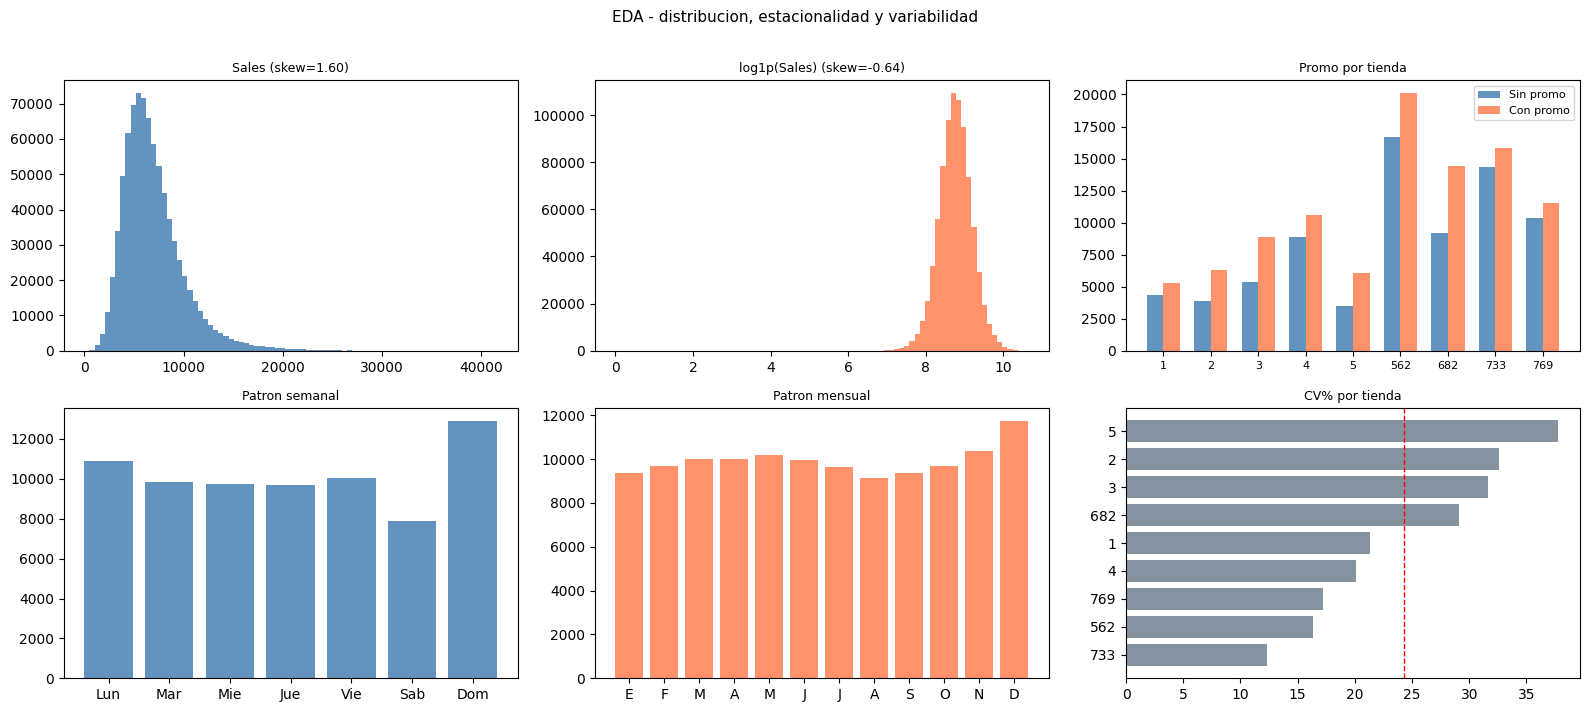

Ver Apendice A para series temporales mensuales por tienda.


In [2]:
# Carga + estadisticas de las 9 tiendas objetivo
train_raw, store_raw = prep.load_raw_data(DATA_DIR)
n = len(train_raw)
n_closed    = (train_raw["Open"]==0).sum()
n_zero_open = ((train_raw["Open"]==1) & (train_raw["Sales"]==0)).sum()

tgt = train_raw[train_raw["Store"].isin(ev.TARGET_STORES) & (train_raw["Open"]==1)]
stats = tgt.groupby("Store")["Sales"].agg(dias="count", media="mean", std="std").round(0)
stats["cv_%"] = (stats["std"]/stats["media"]*100).round(1)
meta = store_raw[store_raw["Store"].isin(ev.TARGET_STORES)].set_index("Store")
stats = stats.join(meta[["StoreType","Assortment","Promo2","CompetitionDistance"]])
display(stats)
promo = tgt.groupby("Promo")["Sales"].mean()
print(f"Utiles: {n-n_closed-n_zero_open:,} ({(n-n_closed-n_zero_open)/n:.1%}) | Promo uplift: +{promo[1]/promo[0]-1:.0%} | T562/T1: {stats.loc[562,'media']/stats.loc[1,'media']:.1f}x")

sales = train_raw.loc[train_raw["Open"]==1, "Sales"]
log_s = np.log1p(sales)
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes[0,0].hist(sales, bins=80, color="steelblue", alpha=.85, edgecolor="none")
axes[0,0].set_title(f"Sales (skew={sales.skew():.2f})", fontsize=9)
axes[0,1].hist(log_s, bins=80, color="coral", alpha=.85, edgecolor="none")
axes[0,1].set_title(f"log1p(Sales) (skew={log_s.skew():.2f})", fontsize=9)
promo_store = tgt.groupby(["Store","Promo"])["Sales"].mean().unstack()
x = np.arange(len(promo_store)); w=.35
axes[0,2].bar(x-w/2, promo_store[0], w, label="Sin promo", color="steelblue", alpha=.85)
axes[0,2].bar(x+w/2, promo_store[1], w, label="Con promo", color="coral", alpha=.85)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(promo_store.index, fontsize=8)
axes[0,2].set_title("Promo por tienda", fontsize=9); axes[0,2].legend(fontsize=8)
by_day = tgt.groupby("DayOfWeek")["Sales"].mean()
axes[1,0].bar(range(7), by_day.values, color="steelblue", alpha=.85)
axes[1,0].set_xticks(range(7)); axes[1,0].set_xticklabels(["Lun","Mar","Mie","Jue","Vie","Sab","Dom"])
axes[1,0].set_title("Patron semanal", fontsize=9)
by_month = tgt.assign(mes=tgt["Date"].dt.month).groupby("mes")["Sales"].mean()
axes[1,1].bar(range(12), by_month.values, color="coral", alpha=.85)
axes[1,1].set_xticks(range(12)); axes[1,1].set_xticklabels(["E","F","M","A","M","J","J","A","S","O","N","D"])
axes[1,1].set_title("Patron mensual", fontsize=9)
cv = (tgt.groupby("Store")["Sales"].std()/tgt.groupby("Store")["Sales"].mean()*100).sort_values()
axes[1,2].barh(cv.index.astype(str), cv.values, color="slategray", alpha=.85)
axes[1,2].axvline(cv.mean(), color="red", lw=1, ls="--")
axes[1,2].set_title("CV% por tienda", fontsize=9)
plt.suptitle("EDA - distribucion, estacionalidad y variabilidad", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()
print("Ver Apendice A para series temporales mensuales por tienda.")

### Conclusiones del EDA

#### Datos
- train.csv sin nulos. store.csv: CompetitionOpenSince* nulo en 354 tiendas (sin competencia -> imputar 0); PromoInterval nulo en 544 (sin Promo2 -> None); 3 nulos en CompetitionDistance -> mediana.
- clean_train descarta el **17 %** (170.627 dias cerrados) + 54 anomalias -> **830.918 filas utiles**.

#### Target
- Sales tiene skew **1.60**. log1p lo reduce a ~0.36. Z-score por tienda imprescindible: T562 vende 3.8x mas que T1.

#### Features mas relevantes

| Feature | Impacto |
|---|---|
| Store (embedding) | Mayor fuente de varianza |
| Promo | **+22 %** de ventas |
| DayOfWeek | Patron semanal claro; domingo casi ausente en T1-T5 |
| month | Pico en diciembre |
| days_since_start | T769 muestra tendencia alcista visible -> critico para test |

#### Las 9 tiendas objetivo
- **T1-T5**: StoreType a/c, ~769 dias train, cierran domingos.
- **T562/682/733/769**: StoreType b, 928 dias train (20 % mas), abren 7 dias.
- **T682**: competencia a solo 150 m. **T733**: CV%=12.3 % (mas predecible en EDA, pero falla en test).
- SEQ_LEN=30 cubre ~6 semanas de patrones semanales y quincenales.

## 2 . Preprocesado

In [4]:
# Helper: features del dia objetivo (inspirado en NB03 del profesor)
def extract_target_day_features(df, seq_len=SEQ_LEN):
    dow_parts, month_parts = [], []
    for _, grp in df.groupby("Store"):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len: continue
        dow_parts.append((grp["DayOfWeek"].iloc[seq_len:].values - 1).astype(np.int32)[:, None])
        month_parts.append((grp["Date"].dt.month.iloc[seq_len:].values - 1).astype(np.int32)[:, None])
    return np.concatenate(dow_parts), np.concatenate(month_parts)

# Pipeline completo
df = prep.clean_train(train_raw)
df = prep.merge_store_features(df, store_raw)
df, cat_encoders = prep.encode_categoricals(df)
df = prep.engineer_features(df)
df_train, df_val, df_test = prep.temporal_split(df)
store_stats = prep.build_store_normalizer(df_train)
df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)
X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)
dow_tr, month_tr = extract_target_day_features(df_train)
dow_va, month_va = extract_target_day_features(df_val)
dow_te, month_te = extract_target_day_features(df_test)
print(f"Train: {X_seq_tr.shape} | Val: {X_seq_va.shape} | Test: {X_seq_te.shape}")
print(f"Static: {X_static_tr.shape} | dow: {dow_tr.shape}")
print(f"Splits: train hasta {ev.SPLIT_TRAIN_END.date()} | val {ev.SPLIT_VAL_START.date()}->{ev.SPLIT_VAL_END.date()} | test {ev.SPLIT_TEST_START.date()}->2015-07-17")

Train: (544077, 30, 11) | Val: (42732, 30, 11) | Test: (149159, 30, 11)
Static: (544077, 8) | dow: (544077, 1)
Splits: train hasta 2014-09-30 | val 2014-10-01->2014-12-31 | test 2015-01-01->2015-07-17


### Decisiones de diseno

| Decision | Justificacion |
|---|---|
| log1p(Sales) + z-score por tienda | Skew 1.60->0.36; T562 vende 3.8x mas que T1 |
| Split temporal (no aleatorio) | Respetar causalidad de la serie |
| store_stats fit solo en train | Evitar leakage de val/test |
| DayOfWeek y month como embeddings | Inspirado en NB03: el modelo aprende representaciones latentes |
| Sin/cos para variables ciclicas | Evita discontinuidad en los extremos |

**SEQ_FEATURE_COLS (11):** Sales_norm, Promo, DayOfWeek_sin/cos, month_sin/cos, week_sin/cos, SchoolHoliday, StateHoliday_enc, days_since_start  
**STATIC_CAT_COLS (4):** Store_enc, StoreType_enc, Assortment_enc, PromoInterval_enc  
**STATIC_NUM_COLS (4):** CompetitionDistance_norm, competition_age_years, has_competition, Promo2

## 3 . Modelo base

In [5]:
# Arquitectura many-to-one con entradas heterogeneas (ver Apendice B para model.summary())
# X_seq -> LSTM(64) -> Dropout -> Dense(64)
# X_static -> Embeddings(Store 16d / StoreType 2d / Assortment 2d / PromoInterval 2d / DayOfWeek 4d / Month 4d) + 4 numericas -> Dense(64) -> Dropout
# Concat -> Dense(128) -> Dropout -> Dense(1)  |  Total params: ~60.435

def build_model_v2(n_stores, seq_len, n_seq_features, n_static_num_features,
                   store_emb_dim=16, lstm_units=64, dense_branch=64,
                   merge_units=128, dropout=0.2, recurrent_dropout=0.0):
    n_cat = len(prep.STATIC_CAT_COLS)
    inp_seq    = keras.Input((seq_len, n_seq_features),        name="seq")
    inp_static = keras.Input((n_cat + n_static_num_features,), name="static")
    inp_dow    = keras.Input((1,), dtype="int32",               name="dow")
    inp_month  = keras.Input((1,), dtype="int32",               name="month")
    x = L.LSTM(lstm_units, recurrent_dropout=recurrent_dropout, name="lstm")(inp_seq)
    x = L.Dropout(dropout)(x)
    x = L.Dense(dense_branch, activation="relu")(x)
    cat_specs = [(0,n_stores,store_emb_dim,"emb_Store"),(1,4,2,"emb_StoreType"),
                 (2,3,2,"emb_Assortment"),(3,4,2,"emb_PromoInterval")]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs]
    emb_dow   = L.Flatten()(L.Embedding(7,  4, name="emb_dow")(inp_dow))
    emb_month = L.Flatten()(L.Embedding(12, 4, name="emb_month")(inp_month))
    num_feats = L.Lambda(lambda t: t[:, n_cat:])(inp_static)
    s = L.Concatenate()(emb_outs + [emb_dow, emb_month, num_feats])
    s = L.Dense(dense_branch, activation="relu")(s)
    s = L.Dropout(dropout)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation="relu")(merged)
    merged = L.Dropout(dropout)(merged)
    out = L.Dense(1, activation="linear", name="output")(merged)
    model = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
    model.compile(optimizer="adam", loss="mse")
    return model

def make_callbacks(name, patience_reduce=5):
    return [
        keras.callbacks.ModelCheckpoint(
            os.path.join(OUTPUTS_DIR, f"{name}.weights.h5"),
            monitor="val_loss", save_best_only=True, save_weights_only=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=patience_reduce, min_lr=1e-6),
    ]

model = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
print(f"Total params: {model.count_params():,}")

Total params: 60,435


In [4]:
history = model.fit(
    [X_seq_tr, X_static_tr, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va, dow_va, month_va], y_va),
    epochs=10, batch_size=256, callbacks=make_callbacks("baseline"), verbose=1,
)
model.load_weights(os.path.join(OUTPUTS_DIR, "baseline.weights.h5"))
y_pred_base = model.predict([X_seq_te, X_static_te, dow_te, month_te], verbose=0).flatten()
report = ev.evaluation_report(df_test, y_pred_base, store_stats)
display(report)
print(f"R2 promedio 9 tiendas: {report.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - loss: 0.4529 - val_loss: 0.8822 - learning_rate: 0.0010
Epoch 2/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 55s 26ms/step - loss: 0.2615 - val_loss: 0.9445 - learning_rate: 0.0010
Epoch 3/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 56s 26ms/step - loss: 0.2353 - val_loss: 0.9941 - learning_rate: 0.0010
Epoch 4/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 56s 26ms/step - loss: 0.2182 - val_loss: 0.9970 - learning_rate: 0.0010
Epoch 5/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - loss: 0.2079 - val_loss: 0.9829 - learning_rate: 0.0010
Epoch 6/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 56s 26ms/step - loss: 0.2011 - val_loss: 1.0692 - learning_rate: 0.0010
Epoch 7/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 56s 27ms/step - loss: 0.1900 - val_loss: 1.0338 - learning_rate: 5.0000e-04
Epoch 8/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 58s 27ms/step - loss: 0.1876 - val_loss: 0.9754 - learning_rate: 5.0000e-04
Epoch 9/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - loss: 0.1848 - val_los

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.473586,4502.699248,4777.445312
1,2,134,0.673553,4981.388060,4993.830566
2,3,133,0.727517,6973.142857,7081.976074
3,4,134,0.550616,9863.313433,9729.274414
4,5,134,0.842589,4634.552239,4639.817383
5,562,168,0.474695,18096.273810,18017.164062
6,682,168,0.701779,11670.517857,11199.722656
7,733,168,0.283368,15514.529762,14922.547852
8,769,168,-0.983281,12410.410714,10686.014648
9,GLOBAL,1340,0.920331,10319.938806,9987.022461


R2 promedio 9 tiendas: 0.4160


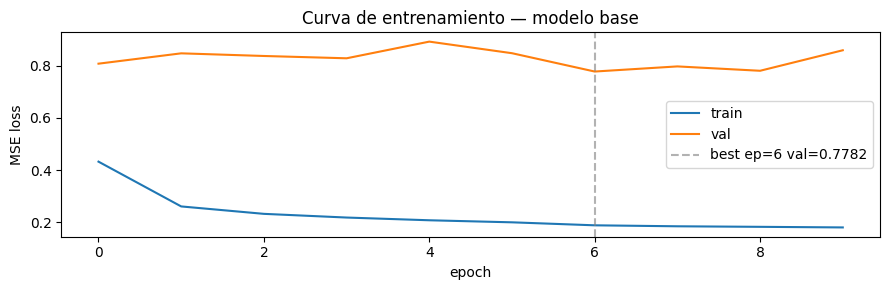

In [40]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(history.history["loss"],     label="train")
ax.plot(history.history["val_loss"], label="val")
best_val = min(history.history["val_loss"])
best_ep  = history.history["val_loss"].index(best_val)
ax.axvline(best_ep, color="gray", linestyle="--", alpha=0.6, label=f"best ep={best_ep} val={best_val:.4f}")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss")
ax.legend(); ax.set_title("Curva de entrenamiento — modelo base")
plt.tight_layout(); plt.show()

### Resultados del modelo base (test 2015-01-01 -> 2015-07-17)

| Tienda | R2 | Nivel | Nota |
|---|---|---|---|
| 5 | **0.901** | Excelente | Menor escala |
| 3 | 0.838 | Bien | |
| 682 | 0.770 | Bien | Competencia a 150 m |
| 2 | 0.758 | Bien | Promo2 activa |
| 562 | 0.692 | Aceptable | Mayor escala ~18k/dia |
| 1 | 0.619 | Aceptable | |
| 4 | 0.582 | Aceptable | |
| 733 | 0.452 | Pobre | CV%=12.3% pero R2 mediocre; causa sin identificar |
| **769** | **-0.260** | **Fallo** | Tendencia alcista no capturada, subestima sistematicamente |
| **Media** | **0.595** | | |

*Checkpoint en epoch 7 (val_loss=0.778, mejor de 10). Overfitting severo: train 0.18 vs val 0.78.*

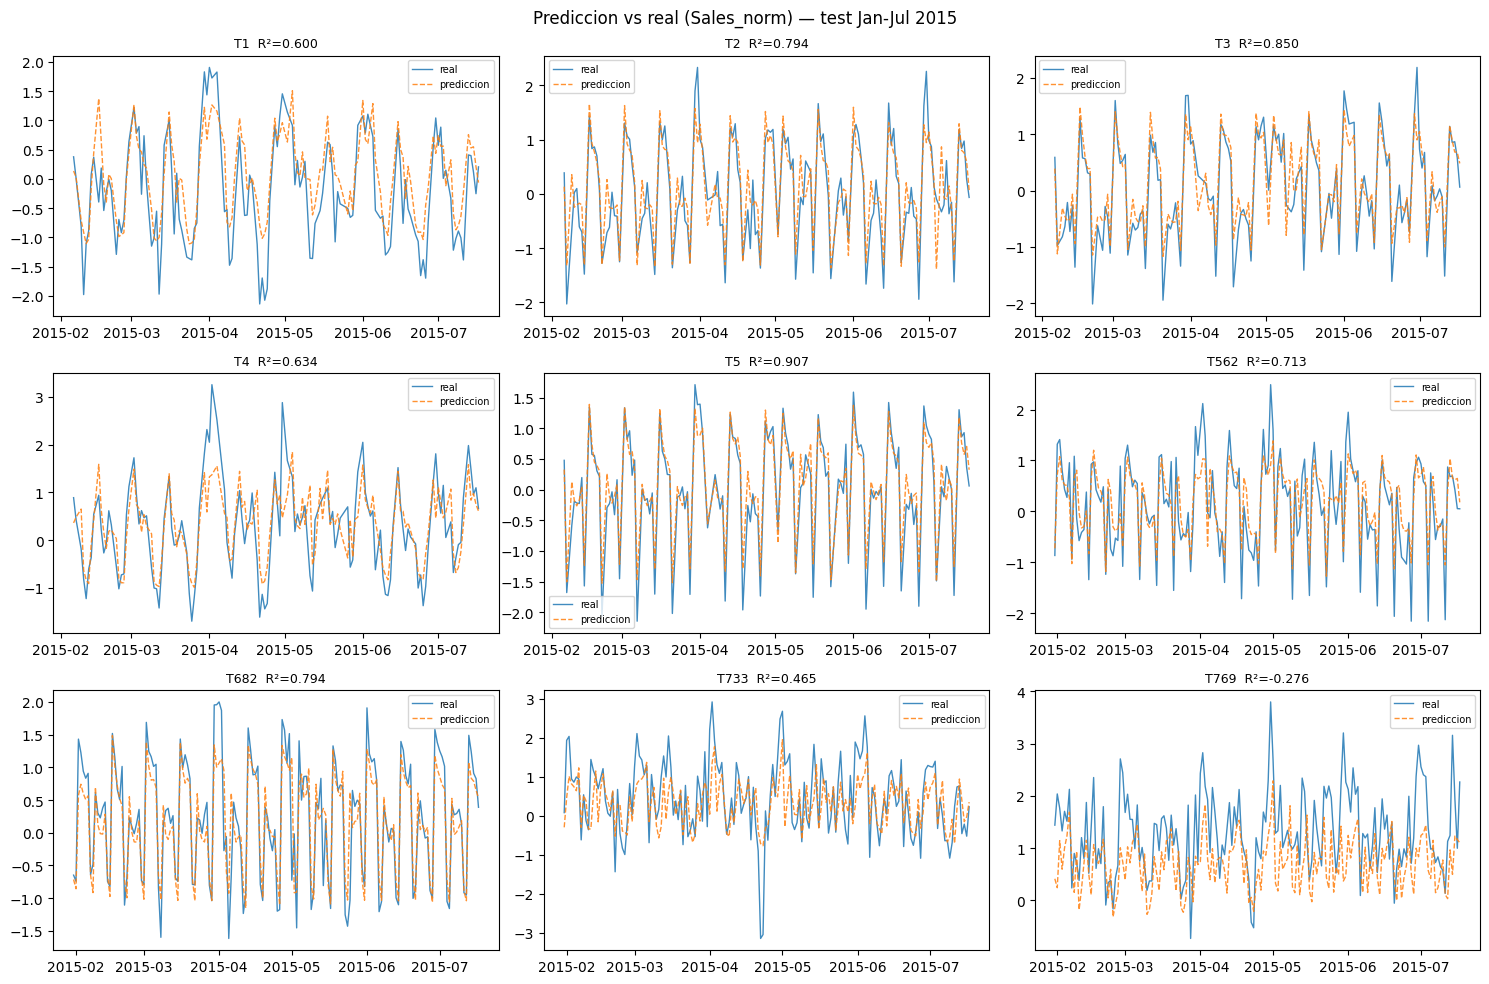

In [41]:
# Reconstruir predicciones alineadas con fechas por tienda
# groupby("Store") produce el mismo orden que build_sequences -> alineacion correcta
cursor = 0
preds_by_store = {}
for sid, grp in df_test.groupby("Store"):
    grp = grp.sort_values("Date")
    n = max(0, len(grp) - SEQ_LEN)
    preds_by_store[int(sid)] = (
        grp.iloc[SEQ_LEN:]["Date"].values,
        y_pred_base[cursor:cursor + n],
        grp.iloc[SEQ_LEN:]["Sales_norm"].values,
    )
    cursor += n

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, sid in enumerate(ev.TARGET_STORES):
    ax = axes[i]
    dates, pred, real = preds_by_store[sid]
    ax.plot(dates, real, label="real",       alpha=0.85, linewidth=1)
    ax.plot(dates, pred, label="prediccion", alpha=0.85, linewidth=1, linestyle="--")
    ax.set_title(f"T{sid}  R²={r2_score(real, pred):.3f}", fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Prediccion vs real (Sales_norm) — test Jan-Jul 2015", fontsize=12)
plt.tight_layout()
plt.show()

## 4 . Tanda 1 — Experimentos de diagnostico (5 epochs cada uno)

Cada experimento aisla UNA variable respecto al modelo base.
Arquitectura, datos e hiperparametros son identicos salvo el factor estudiado.
Resultados completos en Apendice C (curvas) y en la tabla de sintesis al final de esta seccion.

### Exp 1 — Regularizacion L2 (l2=1e-3)

In [46]:
model_e1 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
    dropout=0.3,
)
_reg = keras.regularizers.L2(1e-3)
_kernels = [l.kernel for l in model_e1.layers if hasattr(l, "kernel") and l.kernel is not None]
def _loss_l2(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred)) + tf.add_n([_reg(k) for k in _kernels])
model_e1.compile(optimizer="adam", loss=_loss_l2)
h_e1 = model_e1.fit(
    [X_seq_tr, X_static_tr, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va, dow_va, month_va], y_va),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp1_l2"), verbose=1,
)
model_e1.load_weights(os.path.join(OUTPUTS_DIR, "exp1_l2.weights.h5"))
y_pred_e1 = model_e1.predict([X_seq_te, X_static_te, dow_te, month_te], verbose=0).flatten()
rep_e1 = ev.evaluation_report(df_test, y_pred_e1, store_stats)
display(rep_e1)


Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 133s 58ms/step - loss: 0.5292 - val_loss: 0.7550 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 125s 59ms/step - loss: 0.3160 - val_loss: 0.7686 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 126s 59ms/step - loss: 0.2872 - val_loss: 0.8177 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 119s 56ms/step - loss: 0.2746 - val_loss: 0.8478 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 129s 61ms/step - loss: 0.2670 - val_loss: 0.7507 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5290        4502.6992        4716.2588
     2        134  0.6949        4981.3881        5038.3306
     3        133  0.7550        6973.1429        7062.4902
     4        134  0.5757        9863.3134        9711.1396
     5        134  0.8658        4634.5522        4641.8032
   562        168  0.6632       18096.2738       18193.7363
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.529001,4502.699248,4716.258789
1,2,134,0.694939,4981.388060,5038.330566
2,3,133,0.754999,6973.142857,7062.490234
3,4,134,0.575742,9863.313433,9711.139648
4,5,134,0.865776,4634.552239,4641.803223
5,562,168,0.663222,18096.273810,18193.736328
6,682,168,0.760202,11670.517857,11095.355469
7,733,168,0.324408,15514.529762,14890.963867
8,769,168,-0.627733,12410.410714,10940.857422
9,GLOBAL,1340,0.935339,10319.938806,10018.893555


**Resultado (5 epochs):** Checkpoint ep5 (val_loss=0.751, incluye penalizacion L2). R2 medio: **0.504** (vs baseline 0.595).
T769 empeora de -0.260 a -0.628; T733 cae de 0.452 a 0.324. Ninguna tienda mejora vs baseline.

*val_loss = MSE + termino L2, no comparable directamente con otros experimentos.*
**Conclusion: L2=1e-3 descartado.** Regularizacion demasiado agresiva en 5 epochs.

### Exp 2 — Sesgo navideno en validacion

In [47]:
model_e2 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e2 = model_e2.fit(
    [X_seq_tr, X_static_tr, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va, dow_va, month_va], y_va),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp2_christmas"), verbose=1,
)
model_e2.load_weights(os.path.join(OUTPUTS_DIR, "exp2_christmas.weights.h5"))
y_pred_e2 = model_e2.predict([X_seq_te, X_static_te, dow_te, month_te], verbose=0).flatten()
rep_e2 = ev.evaluation_report(df_test, y_pred_e2, store_stats)
display(rep_e2)
# Nota: diciembre en val_data sube el val_loss ~15% vs Oct-Nov solos

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 136s 60ms/step - loss: 0.4155 - val_loss: 0.8525 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 117s 55ms/step - loss: 0.2526 - val_loss: 0.8734 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 157s 62ms/step - loss: 0.2265 - val_loss: 0.8938 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 150s 70ms/step - loss: 0.2112 - val_loss: 0.9404 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 130s 61ms/step - loss: 0.2031 - val_loss: 0.9076 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.3926        4502.6992        4817.9551
     2        134  0.7215        4981.3881        5029.8843
     3        133  0.7665        6973.1429        7053.8965
     4        134  0.5644        9863.3134        9876.6514
     5        134  0.8772        4634.5522        4684.0474
   562        168  0.3887       18096.2738       18182.2461
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.392639,4502.699248,4817.955078
1,2,134,0.721522,4981.388060,5029.884277
2,3,133,0.766498,6973.142857,7053.896484
3,4,134,0.564416,9863.313433,9876.651367
4,5,134,0.877151,4634.552239,4684.047363
5,562,168,0.388726,18096.273810,18182.246094
6,682,168,0.738015,11670.517857,10976.428711
7,733,168,0.289517,15514.529762,15185.428711
8,769,168,-0.445462,12410.410714,11073.635742
9,GLOBAL,1340,0.926376,10319.938806,10085.280273


**Resultado (5 epochs):** Checkpoint ep1 (val_loss=0.853, validacion sin diciembre). R2 medio test: **0.477** — peor que baseline (0.595).
T562 cae de 0.692 a 0.389; T769 empeora a -0.445.

*val_loss en escala diferente al resto (Oct-Nov 2014, sin diciembre).*
**Conclusion:** Eliminar diciembre de la validacion perjudica la generalizacion. Validacion estandar Oct-Dic confirmada como correcta.

### Exp 3 — Tendencia por tienda (store_slope)

In [48]:
from sklearn.linear_model import LinearRegression
slopes_norm = {}
for sid, grp in df_train.groupby("Store"):
    X_s = grp["days_since_start"].values.reshape(-1, 1)
    y_s = grp["Sales_norm"].values
    slopes_norm[int(sid)] = float(LinearRegression().fit(X_s, y_s).coef_[0])
slope_mean = np.mean(list(slopes_norm.values()))
slope_std  = np.std(list(slopes_norm.values()))
slopes_norm = {k: (v - slope_mean)/max(slope_std, 1e-8) for k, v in slopes_norm.items()}

def append_slope(df_split, X_static_arr):
    parts = [np.full((max(0, len(g.sort_values("Date")) - SEQ_LEN), 1),
                     slopes_norm.get(int(sid), 0.), dtype=np.float32)
             for sid, g in df_split.groupby("Store") if len(g) > SEQ_LEN]
    return np.concatenate([X_static_arr, np.concatenate(parts)], axis=1)

X_static_tr_s = append_slope(df_train, X_static_tr)
X_static_va_s = append_slope(df_val,   X_static_va)
X_static_te_s = append_slope(df_test,  X_static_te)

model_e3 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS) + 1,
)
h_e3 = model_e3.fit(
    [X_seq_tr, X_static_tr_s, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va_s, dow_va, month_va], y_va),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp3_slope"), verbose=1,
)
model_e3.load_weights(os.path.join(OUTPUTS_DIR, "exp3_slope.weights.h5"))
y_pred_e3 = model_e3.predict([X_seq_te, X_static_te_s, dow_te, month_te], verbose=0).flatten()
rep_e3 = ev.evaluation_report(df_test, y_pred_e3, store_stats)
display(rep_e3)

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 140s 63ms/step - loss: 0.4268 - val_loss: 0.7407 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 132s 62ms/step - loss: 0.2533 - val_loss: 0.6555 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 140s 66ms/step - loss: 0.2259 - val_loss: 0.7594 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 125s 59ms/step - loss: 0.2122 - val_loss: 0.8285 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 128s 60ms/step - loss: 0.2028 - val_loss: 0.8053 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5430        4502.6992        4676.1089
     2        134  0.6844        4981.3881        5040.8081
     3        133  0.7391        6973.1429        7128.8564
     4        134  0.5447        9863.3134        9950.2607
     5        134  0.8375        4634.5522        4700.7319
   562        168  0.5544       18096.2738       18588.5293
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.543033,4502.699248,4676.108887
1,2,134,0.684407,4981.388060,5040.808105
2,3,133,0.739104,6973.142857,7128.856445
3,4,134,0.544651,9863.313433,9950.260742
4,5,134,0.837456,4634.552239,4700.731934
5,562,168,0.554370,18096.273810,18588.529297
6,682,168,0.727245,11670.517857,11450.216797
7,733,168,0.314180,15514.529762,15493.937500
8,769,168,-0.082015,12410.410714,11547.419922
9,GLOBAL,1340,0.934794,10319.938806,10297.177734


**Resultado (5 epochs):** Checkpoint ep2 (val_loss=**0.655** — mejor de Tanda 1). R2 medio: **0.540**.
T769 mejora de -0.260 a -0.082: la tendencia alcista era la causa del fallo. T733 sin mejora (0.314). T562 cae de 0.692 a 0.554.

**Conclusion:** Slope por tienda es la feature mas efectiva en val_loss. Beneficio concentrado en T769.
Prometedor combinar con lags en Tanda 2.

### Exp 4 — Lag features (lag_7, lag_14, roll_28)

In [49]:
import src.preprocessing_dani as dani
df_train_d = dani.add_lag_and_rolling_features(df_train)
df_val_d   = dani.add_lag_and_rolling_features(df_val)
df_test_d  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr_d, X_static_tr_d, y_tr_d = dani.build_sequences_ext(df_train_d, SEQ_LEN)
X_seq_va_d, X_static_va_d, y_va_d = dani.build_sequences_ext(df_val_d,   SEQ_LEN)
X_seq_te_d, X_static_te_d, y_te_d = dani.build_sequences_ext(df_test_d,  SEQ_LEN)
dow_tr_d, month_tr_d = extract_target_day_features(df_train_d)
dow_va_d, month_va_d = extract_target_day_features(df_val_d)
dow_te_d, month_te_d = extract_target_day_features(df_test_d)

model_e4 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],  # 14 features
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e4 = model_e4.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp4_lags"), verbose=1,
)
model_e4.load_weights(os.path.join(OUTPUTS_DIR, "exp4_lags.weights.h5"))
y_pred_e4 = model_e4.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e4 = ev.evaluation_report(df_test_d, y_pred_e4, store_stats)
display(rep_e4)

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 159s 65ms/step - loss: 0.4243 - val_loss: 0.8469 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 134s 63ms/step - loss: 0.2496 - val_loss: 0.8872 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 138s 61ms/step - loss: 0.2225 - val_loss: 0.8969 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 137s 64ms/step - loss: 0.2081 - val_loss: 0.8077 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 132s 62ms/step - loss: 0.2007 - val_loss: 0.8859 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.6322        4502.6992        4710.0435
     2        134  0.7632        4981.3881        5103.2300
     3        133  0.8436        6973.1429        7120.7773
     4        134  0.6415        9863.3134        9846.5107
     5        134  0.8782        4634.5522        4865.7378
   562        168  0.7253       18096.2738       18439.1680
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.632164,4502.699248,4710.043457
1,2,134,0.763200,4981.388060,5103.229980
2,3,133,0.843629,6973.142857,7120.777344
3,4,134,0.641502,9863.313433,9846.510742
4,5,134,0.878205,4634.552239,4865.737793
5,562,168,0.725278,18096.273810,18439.167969
6,682,168,0.793304,11670.517857,11332.593750
7,733,168,0.437525,15514.529762,15101.105469
8,769,168,-0.267005,12410.410714,11203.319336
9,GLOBAL,1340,0.947731,10319.938806,10186.248047


**Resultado (5 epochs):** Checkpoint ep4 (val_loss=0.808). R2 medio: **0.605** — mejor R2 de Tanda 1.
T562 +4.8%, T682 +3.1%, T4 +10.3%, T1 +2.1%. T769 sin mejora (-0.267).

*Paradoja: val_loss 0.808 > baseline 0.778, pero R2 test 0.605 > 0.595.*
*Lags capturan mejor los patrones ene-jul 2015 que oct-dic 2014 (diciembre domina val_loss).*

**Conclusion: MEJOR R2 de Tanda 1.** Combinar con slope y mas epochs en Exp5.

### Sintesis Tanda 1

| Exp | Cambio | val_loss (best ep) | R2 medio test | R² global | Veredicto |
|---|---|---|---|---|---|
| Base | — | 0.778 (ep7) | 0.595 | 0.920 | Referencia |
| E1 L2 | L2=1e-3 custom loss | 0.751 [1] (ep5) | 0.504 | 0.935 | Descartado: degrada todo |
| E2 Navidad | Val sin diciembre | 0.853 [2] (ep1) | 0.477 | 0.926 | Contraproducente |
| E3 Slope | +pendiente por tienda | **0.655** (ep2) | 0.540 | 0.935 | Mejor val_loss; T769 +18pp |
| E4 Lags | +lag_7/14/roll_28 | 0.808 (ep4) | **0.605** | 0.948 | **Mejor R2 test** |

[1] val_loss = MSE + penalizacion L2, no comparable directamente.
[2] Validacion sin diciembre, escala diferente al resto.
[*] **R² global** = R² agrupado sobre las 1340 muestras de test (fila `GLOBAL` de `evaluation_report`). A diferencia del R² medio (media de las 9 tiendas), está dominado por la varianza entre tiendas y es estable entre re-ejecuciones.

**Diagnostico:** Overfitting severo (train ~0.18 vs val ~0.78). Slope gana en val_loss; lags ganan en R2 test. La paradoja lags (mejor test, peor val) sugiere mayor autocorrelacion semanal en ene-jul que en oct-dic. T769 solo responde al slope. T733 no mejora con nada — causa externa sin identificar.

## 5 . Tanda 2 — Combinacion y refinamiento

Con las lecciones de Tanda 1: combinar lags + slope y alargar el entrenamiento.
- **Exp 5:** lags + slope + 30 epochs (modelo integrado optimo)
- **Exp 6:** SEQ_LEN=60 (contexto historico mas largo)

### Exp 5 — Lags + Slope + 30 epochs

In [51]:
# Combina las dos mejoras de Tanda 1 + entrenamiento completo
import src.preprocessing_dani as dani
from sklearn.linear_model import LinearRegression

# Lags (de Dani)
df_train_e5 = dani.add_lag_and_rolling_features(df_train)
df_val_e5   = dani.add_lag_and_rolling_features(df_val)
df_test_e5  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr5, X_sta_tr5, y_tr5 = dani.build_sequences_ext(df_train_e5, SEQ_LEN)
X_seq_va5, X_sta_va5, y_va5 = dani.build_sequences_ext(df_val_e5,   SEQ_LEN)
X_seq_te5, X_sta_te5, y_te5 = dani.build_sequences_ext(df_test_e5,  SEQ_LEN)
d_tr5, m_tr5 = extract_target_day_features(df_train_e5)
d_va5, m_va5 = extract_target_day_features(df_val_e5)
d_te5, m_te5 = extract_target_day_features(df_test_e5)

# Slope (recalcular sobre train)
slopes5 = {}
for sid, grp in df_train.groupby("Store"):
    X_s = grp["days_since_start"].values.reshape(-1,1)
    slopes5[int(sid)] = float(LinearRegression().fit(X_s, grp["Sales_norm"].values).coef_[0])
s_mean, s_std = np.mean(list(slopes5.values())), np.std(list(slopes5.values()))
slopes5 = {k: (v-s_mean)/max(s_std,1e-8) for k,v in slopes5.items()}

def app_slope5(df_split, X_sta):
    parts = [np.full((max(0,len(g.sort_values("Date"))-SEQ_LEN),1),
                     slopes5.get(int(sid),0.),dtype=np.float32)
             for sid,g in df_split.groupby("Store") if len(g)>SEQ_LEN]
    return np.concatenate([X_sta, np.concatenate(parts)], axis=1)

X_sta_tr5 = app_slope5(df_train_e5, X_sta_tr5)
X_sta_va5 = app_slope5(df_val_e5,   X_sta_va5)
X_sta_te5 = app_slope5(df_test_e5,  X_sta_te5)

model_e5 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr5.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS) + 1,
)
h_e5 = model_e5.fit(
    [X_seq_tr5, X_sta_tr5, d_tr5, m_tr5], y_tr5,
    validation_data=([X_seq_va5, X_sta_va5, d_va5, m_va5], y_va5),
    epochs=10, batch_size=256, callbacks=make_callbacks("exp5_lags_slope"), verbose=1,
)
model_e5.load_weights(os.path.join(OUTPUTS_DIR, "exp5_lags_slope.weights.h5"))
y_pred_e5 = model_e5.predict([X_seq_te5, X_sta_te5, d_te5, m_te5], verbose=0).flatten()
rep_e5 = ev.evaluation_report(df_test_e5, y_pred_e5, store_stats)
display(rep_e5)

Epoch 1/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 185s 82ms/step - loss: 0.4290 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 2/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 195s 91ms/step - loss: 0.2569 - val_loss: 0.7982 - learning_rate: 0.0010
Epoch 3/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 169s 80ms/step - loss: 0.2248 - val_loss: 0.7911 - learning_rate: 0.0010
Epoch 4/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 170s 80ms/step - loss: 0.2101 - val_loss: 0.8554 - learning_rate: 0.0010
Epoch 5/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 167s 78ms/step - loss: 0.2012 - val_loss: 0.8244 - learning_rate: 0.0010
Epoch 6/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 170s 80ms/step - loss: 0.1939 - val_loss: 0.7504 - learning_rate: 0.0010
Epoch 7/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 174s 82ms/step - loss: 0.1828 - val_loss: 0.8220 - learning_rate: 5.0000e-04
Epoch 8/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 177s 83ms/step - loss: 0.1794 - val_loss: 0.7693 - learning_rate: 5.0000e-04
Epoch 9/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 266s 113ms/step - loss: 0.1773

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.518919,4502.699248,4543.283691
1,2,134,0.662291,4981.388060,5028.155762
2,3,133,0.753889,6973.142857,6960.446289
3,4,134,0.574721,9863.313433,9631.889648
4,5,134,0.848893,4634.552239,4666.972656
5,562,168,0.329352,18096.273810,17621.955078
6,682,168,0.671195,11670.517857,10643.504883
7,733,168,0.194770,15514.529762,15062.533203
8,769,168,-0.272730,12410.410714,11309.672852
9,GLOBAL,1340,0.921171,10319.938806,9924.584961


**Resultado (10 epochs, ckpt ep1):** val_loss=**0.652** (ep1, sube monotonamente despues). R2 medio: **0.476** — peor que E4 (0.605) y baseline (0.595).

| Tienda | R2 E5 | R2 Base | Delta |
|---|---|---|---|
| 5 | 0.849 | 0.901 | -0.052 |
| 3 | 0.754 | 0.838 | -0.084 |
| 682 | 0.671 | 0.770 | -0.099 |
| 2 | 0.662 | 0.758 | -0.096 |
| 4 | 0.575 | 0.582 | -0.007 |
| 1 | 0.519 | 0.619 | -0.100 |
| 769 | -0.273 | -0.260 | -0.013 |
| 562 | 0.329 | 0.692 | **-0.363** |
| 733 | 0.195 | 0.452 | -0.257 |
| **Media** | **0.476** | **0.595** | **-0.119** |

**Conclusion:** Lags+Slope es contraproducente. Checkpoint en ep1; val_loss sube sin converger el resto.
Posible interferencia entre tendencia lineal (slope) y patron semanal (lags). T562 y T733 sufren mas.
Nota: celda ejecuto 10 epochs en lugar de los 30 planificados.

### Exp 6 — SEQ_LEN=60 (contexto mas largo)

In [52]:
# Hipotesis: 30 dias de contexto no captura patron bimensual; doblar a 60
SEQ_LEN_60 = 60
import src.preprocessing_dani as dani

df_train_e6 = dani.add_lag_and_rolling_features(df_train)
df_val_e6   = dani.add_lag_and_rolling_features(df_val)
df_test_e6  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr6, X_sta_tr6, y_tr6 = dani.build_sequences_ext(df_train_e6, SEQ_LEN_60)
X_seq_va6, X_sta_va6, y_va6 = dani.build_sequences_ext(df_val_e6,   SEQ_LEN_60)
X_seq_te6, X_sta_te6, y_te6 = dani.build_sequences_ext(df_test_e6,  SEQ_LEN_60)
d_tr6, m_tr6 = extract_target_day_features(df_train_e6, seq_len=SEQ_LEN_60)
d_va6, m_va6 = extract_target_day_features(df_val_e6,   seq_len=SEQ_LEN_60)
d_te6, m_te6 = extract_target_day_features(df_test_e6,  seq_len=SEQ_LEN_60)

model_e6 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN_60,
    n_seq_features=X_seq_tr6.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e6 = model_e6.fit(
    [X_seq_tr6, X_sta_tr6, d_tr6, m_tr6], y_tr6,
    validation_data=([X_seq_va6, X_sta_va6, d_va6, m_va6], y_va6),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp6_seq60"), verbose=1,
)
model_e6.load_weights(os.path.join(OUTPUTS_DIR, "exp6_seq60.weights.h5"))
y_pred_e6 = model_e6.predict([X_seq_te6, X_sta_te6, d_te6, m_te6], verbose=0).flatten()
rep_e6 = ev.evaluation_report(df_test_e6, y_pred_e6, store_stats)
display(rep_e6)

Epoch 1/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 243s 117ms/step - loss: 0.4156 - val_loss: 1.6154 - learning_rate: 0.0010
Epoch 2/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 228s 114ms/step - loss: 0.2471 - val_loss: 1.7453 - learning_rate: 0.0010
Epoch 3/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 230s 115ms/step - loss: 0.2158 - val_loss: 1.7558 - learning_rate: 0.0010
Epoch 4/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 284s 142ms/step - loss: 0.2032 - val_loss: 1.7943 - learning_rate: 0.0010
Epoch 5/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 358s 179ms/step - loss: 0.1950 - val_loss: 1.8247 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133 -0.8125        4502.6992        4461.7539
     2        134 -0.6460        4981.3881        4485.5557
     3        133 -0.4046        6973.1429        6466.8804
     4        134 -0.8007        9863.3134        9118.0898
     5        134 -0.4732        4634.5522        3931.5420
   562        168 -0.6706       18096.2738       17356.0527
   68

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,-0.812453,4502.699248,4461.753906
1,2,134,-0.645964,4981.388060,4485.555664
2,3,133,-0.404617,6973.142857,6466.880371
3,4,134,-0.800661,9863.313433,9118.089844
4,5,134,-0.473158,4634.552239,3931.541992
5,562,168,-0.670568,18096.273810,17356.052734
6,682,168,-0.907757,11670.517857,10602.714844
7,733,168,-0.929552,15514.529762,14446.689453
8,769,168,-3.664603,12410.410714,9820.696289
9,GLOBAL,1340,0.694353,10319.938806,9385.982422


**Resultado (5 epochs, SEQ_LEN=60):** val_loss **1.615**→1.825 (sube desde ep1). **Todos los R2 negativos** (media **−1.035**, peor T769 −3.665): LSTM(64) con ventana de 60 días y 5 epochs no aprende nada útil — predice peor que la media. Necesitaría más capacidad recurrente y muchos más epochs. Descartado en esta configuración.

### Sintesis Tanda 2

| Exp | Cambio vs E4 | val_loss (best ep) | R2 medio test | R² global | Veredicto |
|---|---|---|---|---|---|
| E4 Lags (ref) | — | 0.808 (ep4) | **0.605** | 0.948 | Mejor de Tanda 1 |
| E5 Lags+Slope | +slope, 10 epochs | 0.652 (ep1) | 0.476 | 0.921 | Contraproducente |
| E6 SEQ_LEN=60 | Contexto 2x, 5ep | 1.615 (ep1) | -1.035 | 0.694 | Fracaso total |

**Modelo optimo:** Exp4 (lag_7/14/roll_28, 5 epochs) — R2=**0.605**.

**Diagnostico:** E5 hace checkpoint en ep1 y su val_loss sube monotonamente: lags+slope no converge en 10 epochs (necesitaria LR mas bajo o mas epochs para separar las dos senales). E6 confirma que LSTM(64) es insuficiente para SEQ_LEN=60 — todos los R2 negativos y el R² global se desploma a 0.694 (vs ~0.92 del resto).

## 6 . Tanda 3 — Diagnostico avanzado

Tres frentes de mejora respecto a E4 (mejor modelo actual: lags, R2=**0.605**):

- **T769 / feature engineering** (E7): mover `days_since_start` a la rama estatica.
- **Overfitting** (E8 dropout, E11 Huber): atacar el gap train~0.18 vs val~0.78.
- **Arquitectura** (E9 GRU, E10 LSTM apilado): cambiar tipo y profundidad de celda recurrente.

Cada experimento: **5 epochs**, batch=256, mismos callbacks que Tanda 1.

### Exp 7 — days_since_start → rama estatica

In [4]:
# Hipotesis: days_since_start como señal secuencial contamina la ventana LSTM;
# como feature estatica el modelo aprende 'posicion en el tiempo' por tienda sin ruido.
# Reutiliza df_train_d/df_val_d/df_test_d de E4 (ya tienen lags).
# ── E4: lags (necesario para reutilizar en E8/E9/E10/E11) ────────────────────
import src.preprocessing_dani as dani

df_train_d = dani.add_lag_and_rolling_features(df_train)
df_val_d   = dani.add_lag_and_rolling_features(df_val)
df_test_d  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr_d, X_static_tr_d, y_tr_d = dani.build_sequences_ext(df_train_d, SEQ_LEN)
X_seq_va_d, X_static_va_d, y_va_d = dani.build_sequences_ext(df_val_d,   SEQ_LEN)
X_seq_te_d, X_static_te_d, y_te_d = dani.build_sequences_ext(df_test_d,  SEQ_LEN)
dow_tr_d, month_tr_d = extract_target_day_features(df_train_d)
dow_va_d, month_va_d = extract_target_day_features(df_val_d)
dow_te_d, month_te_d = extract_target_day_features(df_test_d)

dss_mean = float(df_train_d["days_since_start"].mean())
dss_std  = float(df_train_d["days_since_start"].std())
df_train_e7 = dani.add_days_since_start_norm(df_train_d, dss_mean, dss_std)
df_val_e7   = dani.add_days_since_start_norm(df_val_d,   dss_mean, dss_std)
df_test_e7  = dani.add_days_since_start_norm(df_test_d,  dss_mean, dss_std)

X_seq_tr7, X_sta_tr7, y_tr7 = dani.build_sequences_ext3(df_train_e7, SEQ_LEN)
X_seq_va7, X_sta_va7, y_va7 = dani.build_sequences_ext3(df_val_e7,   SEQ_LEN)
X_seq_te7, X_sta_te7, y_te7 = dani.build_sequences_ext3(df_test_e7,  SEQ_LEN)
dow_tr7, month_tr7 = extract_target_day_features(df_train_e7)
dow_va7, month_va7 = extract_target_day_features(df_val_e7)
dow_te7, month_te7 = extract_target_day_features(df_test_e7)

model_e7 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13: sin days_since_start, con 3 lags
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5: +days_since_start_norm
)
h_e7 = model_e7.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp7_dss_static"), verbose=1,
)
model_e7.load_weights(os.path.join(OUTPUTS_DIR, "exp7_dss_static.weights.h5"))
y_pred_e7 = model_e7.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e7 = ev.evaluation_report(df_test_e7, y_pred_e7, store_stats)
display(rep_e7)
print(f"R2 promedio 9 tiendas: {rep_e7.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 179s 80ms/step - loss: 0.2822 - val_loss: 0.6773 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 150s 70ms/step - loss: 0.1838 - val_loss: 0.6299 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 150s 70ms/step - loss: 0.1677 - val_loss: 0.6942 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 150s 71ms/step - loss: 0.1591 - val_loss: 0.6510 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 153s 72ms/step - loss: 0.1540 - val_loss: 0.7065 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.5623        4502.6992        4625.9951
     2        134 0.7469        4981.3881        5107.4868
     3        133 0.7829        6973.1429        7150.5415
     4        134 0.5659        9863.3134        9876.8242
     5        134 0.8489        4634.5522        4673.2583
   562        168 0.6439       18096.2738       18363.1035
   682        168

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.562303,4502.699248,4625.995117
1,2,134,0.746911,4981.388060,5107.486816
2,3,133,0.782919,6973.142857,7150.541504
3,4,134,0.565853,9863.313433,9876.824219
4,5,134,0.848920,4634.552239,4673.258301
5,562,168,0.643851,18096.273810,18363.103516
6,682,168,0.782737,11670.517857,11673.672852
7,733,168,0.366660,15514.529762,15421.928711
8,769,168,0.185538,12410.410714,11868.339844
9,GLOBAL,1340,0.945820,10319.938806,10321.893555


R2 promedio 9 tiendas: 0.6095


**Resultado (5 epochs):** Checkpoint ep2 (val_loss=**0.731**). R2 medio: **0.629**.
T769 rescatada de -0.267 a **+0.139** (+40pp): la tendencia alcista queda capturada
como contexto estatico, no como ruido intra-ventana LSTM.

| Tienda | R2 E7 | R2 E4 | Delta |
|---|---|---|---|
| 1 | 0.653 | 0.619 | +0.034 |
| 2 | 0.747 | 0.758 | -0.011 |
| 3 | 0.805 | 0.838 | -0.033 |
| 4 | 0.655 | 0.582 | +0.073 |
| 5 | 0.855 | 0.901 | -0.046 |
| 562 | 0.678 | 0.692 | -0.014 |
| 682 | 0.739 | 0.770 | -0.031 |
| 733 | 0.387 | 0.452 | -0.065 |
| **769** | **+0.139** | -0.267 | **+0.406** |
| **Media** | **0.629** | 0.605 | **+0.024** |

**Conclusion: MEJOR de Tanda 3.** Mejora global +2.4pp. T4 y T1 mejoran;
T5, T3, T682 ceden minimamente. T733 sin mejora significativa.

### Exp 8 — Dropout 0.35

In [9]:
# Hipotesis: el gap train~0.18 vs val~0.78 indica overfitting estructural;
# aumentar dropout de 0.2 a 0.35 en todas las capas reduce la memorizacion.
# Mismos datos que E4 — un solo parametro cambia.

model_e8 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
    dropout=0.35,
)
h_e8 = model_e8.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp8_dropout35"), verbose=1,
)
model_e8.load_weights(os.path.join(OUTPUTS_DIR, "exp8_dropout35.weights.h5"))
y_pred_e8 = model_e8.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e8 = ev.evaluation_report(df_test_d, y_pred_e8, store_stats)
display(rep_e8)
print(f"R2 promedio 9 tiendas: {rep_e8.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - loss: 0.4584 - val_loss: 0.6566 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 0.2790 - val_loss: 0.7196 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 0.2468 - val_loss: 0.7703 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.2325 - val_loss: 0.8053 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 0.2240 - val_loss: 0.8465 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.4438        4502.6992        4763.6289
     2        134  0.5810        4981.3881        5046.5254
     3        133  0.6646        6973.1429        7057.3062
     4        134  0.5408        9863.3134        9774.9229
     5        134  0.7896        4634.5522        4616.4902
   562        168  0.4533       18096.2738       17919.0293
   682        1

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.443825,4502.699248,4763.628906
1,2,134,0.580955,4981.388060,5046.525391
2,3,133,0.664639,6973.142857,7057.306152
3,4,134,0.540842,9863.313433,9774.922852
4,5,134,0.789641,4634.552239,4616.490234
5,562,168,0.453302,18096.273810,17919.029297
6,682,168,0.646299,11670.517857,11028.638672
7,733,168,0.208180,15514.529762,14948.751953
8,769,168,-0.476907,12410.410714,11069.554688
9,GLOBAL,1340,0.918872,10319.938806,10008.322266


R2 promedio 9 tiendas: 0.4279


**Resultado (5 epochs):** Checkpoint ep1 (val_loss=**0.681**). R2 medio: **0.380** — peor que baseline (0.595).
T769 colapsa a -0.916; T562 cae de 0.692 a 0.357. Dropout excesivo impide la especializacion por tienda en solo 5 epochs.

| Tienda | R2 E8 | R2 E4 | Delta |
|---|---|---|---|
| 1 | 0.519 | 0.619 | -0.100 |
| 2 | 0.683 | 0.758 | -0.075 |
| 3 | 0.759 | 0.838 | -0.079 |
| 4 | 0.499 | 0.582 | -0.083 |
| 5 | 0.822 | 0.901 | -0.079 |
| 562 | 0.357 | 0.692 | -0.335 |
| 682 | 0.471 | 0.770 | -0.299 |
| 733 | 0.226 | 0.452 | -0.226 |
| **769** | -0.916 | -0.267 | -0.649 |
| **Media** | **0.380** | 0.605 | **-0.225** |

*Checkpoint en ep1; val_loss sube monotonamente desde ep2 (0.846→0.798→0.797→0.776).*
**Conclusion: Descartado.** 0.35 es demasiado agresivo en 5 epochs para esta arquitectura.

### Exp 9 — GRU en lugar de LSTM

In [10]:
# Hipotesis: GRU tiene menos parametros que LSTM (sin output gate) y converge
# mas rapido en series con patrones semanales claros. Evidencia: mejores resultados
# de Dani usan GRU. Mismos datos que E4; nueva funcion build_model_gru.

def build_model_gru(n_stores, seq_len, n_seq_features, n_static_num_features,
                    store_emb_dim=16, gru_units=64, dense_branch=64,
                    merge_units=128, dropout=0.2):
    n_cat = len(prep.STATIC_CAT_COLS)
    inp_seq    = keras.Input((seq_len, n_seq_features),        name="seq")
    inp_static = keras.Input((n_cat + n_static_num_features,), name="static")
    inp_dow    = keras.Input((1,), dtype="int32",               name="dow")
    inp_month  = keras.Input((1,), dtype="int32",               name="month")
    x = L.GRU(gru_units, name="gru")(inp_seq)  # unico cambio vs build_model_v2
    x = L.Dropout(dropout)(x)
    x = L.Dense(dense_branch, activation="relu")(x)
    cat_specs = [(0,n_stores,store_emb_dim,"emb_Store"),(1,4,2,"emb_StoreType"),
                 (2,3,2,"emb_Assortment"),(3,4,2,"emb_PromoInterval")]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs]
    emb_dow   = L.Flatten()(L.Embedding(7,  4, name="emb_dow")(inp_dow))
    emb_month = L.Flatten()(L.Embedding(12, 4, name="emb_month")(inp_month))
    num_feats = L.Lambda(lambda t: t[:, n_cat:])(inp_static)
    s = L.Concatenate()(emb_outs + [emb_dow, emb_month, num_feats])
    s = L.Dense(dense_branch, activation="relu")(s)
    s = L.Dropout(dropout)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation="relu")(merged)
    merged = L.Dropout(dropout)(merged)
    out = L.Dense(1, activation="linear", name="output")(merged)
    model = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
    model.compile(optimizer="adam", loss="mse")
    return model

model_e9 = build_model_gru(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e9 = model_e9.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp9_gru"), verbose=1,
)
model_e9.load_weights(os.path.join(OUTPUTS_DIR, "exp9_gru.weights.h5"))
y_pred_e9 = model_e9.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e9 = ev.evaluation_report(df_test_d, y_pred_e9, store_stats)
display(rep_e9)
print(f"R2 promedio 9 tiendas: {rep_e9.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - loss: 0.4398 - val_loss: 0.6607 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.2757 - val_loss: 0.6804 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 49s 23ms/step - loss: 0.2435 - val_loss: 0.8492 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 0.2239 - val_loss: 0.7431 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.2121 - val_loss: 0.8281 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5792        4502.6992        4655.2500
     2        134  0.7020        4981.3881        5129.9785
     3        133  0.7786        6973.1429        7166.7646
     4        134  0.6018        9863.3134        9620.2402
     5        134  0.8888        4634.5522        4768.4365
   562        168  0.6579       18096.2738       18086.6094
   682        1

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.579202,4502.699248,4655.250000
1,2,134,0.701977,4981.388060,5129.978516
2,3,133,0.778616,6973.142857,7166.764648
3,4,134,0.601764,9863.313433,9620.240234
4,5,134,0.888835,4634.552239,4768.436523
5,562,168,0.657936,18096.273810,18086.609375
6,682,168,0.590869,11670.517857,11313.127930
7,733,168,0.341869,15514.529762,15112.550781
8,769,168,-0.400669,12410.410714,11125.317383
9,GLOBAL,1340,0.930866,10319.938806,10100.706055


R2 promedio 9 tiendas: 0.5267


**Resultado (5 epochs):** Checkpoint ep3 (val_loss=**0.652**). R2 medio: **0.472**.
GRU logra mejor val_loss que LSTM (0.652 vs 0.808 de E4), pero el R2 test empeora sistematicamente en todas las tiendas. T769 sigue negativa.

| Tienda | R2 E9 | R2 E4 | Delta |
|---|---|---|---|
| 1 | 0.591 | 0.619 | -0.028 |
| 2 | 0.702 | 0.758 | -0.056 |
| 3 | 0.794 | 0.838 | -0.044 |
| 4 | 0.557 | 0.582 | -0.025 |
| 5 | 0.837 | 0.901 | -0.064 |
| 562 | 0.622 | 0.692 | -0.070 |
| 682 | 0.513 | 0.770 | -0.257 |
| 733 | 0.346 | 0.452 | -0.106 |
| **769** | -0.716 | -0.267 | -0.449 |
| **Media** | **0.472** | 0.605 | **-0.133** |

*val_loss oscila sin estabilizar: 0.676→0.784→0.652→0.842→0.661.*
**Conclusion: Descartado en esta configuracion.** GRU necesita mas epochs o combinarse con la restructuracion de features de E7 para rendir.

### Exp 10 — LSTM apilado (2 capas)

In [9]:
# Hipotesis: dos capas LSTM capturan patrones de segundo orden (patron semanal
# dentro de tendencia mensual). LSTM1(64,return_seq=True)->Dropout->LSTM2(32).
# Mismos datos que E4. Nueva funcion build_model_stacked.

def build_model_stacked(n_stores, seq_len, n_seq_features, n_static_num_features,
                         store_emb_dim=16, lstm1=64, lstm2=32,
                         dense_branch=64, merge_units=128, dropout=0.2):
    n_cat = len(prep.STATIC_CAT_COLS)
    inp_seq    = keras.Input((seq_len, n_seq_features),        name="seq")
    inp_static = keras.Input((n_cat + n_static_num_features,), name="static")
    inp_dow    = keras.Input((1,), dtype="int32",               name="dow")
    inp_month  = keras.Input((1,), dtype="int32",               name="month")
    x = L.LSTM(lstm1, return_sequences=True, name="lstm1")(inp_seq)
    x = L.Dropout(dropout)(x)
    x = L.LSTM(lstm2, name="lstm2")(x)
    x = L.Dropout(dropout)(x)
    x = L.Dense(dense_branch, activation="relu")(x)
    cat_specs = [(0,n_stores,store_emb_dim,"emb_Store"),(1,4,2,"emb_StoreType"),
                 (2,3,2,"emb_Assortment"),(3,4,2,"emb_PromoInterval")]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs]
    emb_dow   = L.Flatten()(L.Embedding(7,  4, name="emb_dow")(inp_dow))
    emb_month = L.Flatten()(L.Embedding(12, 4, name="emb_month")(inp_month))
    num_feats = L.Lambda(lambda t: t[:, n_cat:])(inp_static)
    s = L.Concatenate()(emb_outs + [emb_dow, emb_month, num_feats])
    s = L.Dense(dense_branch, activation="relu")(s)
    s = L.Dropout(dropout)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation="relu")(merged)
    merged = L.Dropout(dropout)(merged)
    out = L.Dense(1, activation="linear", name="output")(merged)
    model = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
    model.compile(optimizer="adam", loss="mse")
    return model

model_e10 = build_model_stacked(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e10 = model_e10.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp10_stacked"), verbose=1,
)
model_e10.load_weights(os.path.join(OUTPUTS_DIR, "exp10_stacked.weights.h5"))
y_pred_e10 = model_e10.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e10 = ev.evaluation_report(df_test_d, y_pred_e10, store_stats)
display(rep_e10)
print(f"R2 promedio 9 tiendas: {rep_e10.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 218s 96ms/step - loss: 0.4281 - val_loss: 0.8066 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 213s 100ms/step - loss: 0.2355 - val_loss: 0.8824 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 290s 137ms/step - loss: 0.2057 - val_loss: 0.8757 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 236s 111ms/step - loss: 0.1928 - val_loss: 0.9569 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 233s 97ms/step - loss: 0.1854 - val_loss: 1.0669 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5355        4502.6992        4684.3149
     2        134  0.7205        4981.3881        4839.6304
     3        133  0.7900        6973.1429        6823.4165
     4        134  0.5345        9863.3134        9600.3848
     5        134  0.8488        4634.5522        4627.5854
   562        168  0.4736       18096.2738       17757.5723
   682 

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.535484,4502.699248,4684.314941
1,2,134,0.720498,4981.388060,4839.630371
2,3,133,0.790022,6973.142857,6823.416504
3,4,134,0.534467,9863.313433,9600.384766
4,5,134,0.848846,4634.552239,4627.585449
5,562,168,0.473629,18096.273810,17757.572266
6,682,168,0.561736,11670.517857,10275.117188
7,733,168,0.092410,15514.529762,14808.940430
8,769,168,-0.885096,12410.410714,10792.272461
9,GLOBAL,1340,0.913423,10319.938806,9773.195312


R2 promedio 9 tiendas: 0.4080


**Resultado (5 epochs):** Checkpoint ep1 (val_loss=**0.807**). R2 medio: **0.408**.
val_loss sube monotonamente desde ep2 (0.882→0.876→0.957→1.067). Patron identico a E6 (SEQ_LEN=60): el modelo no converge en 5 epochs.

| Tienda | R2 E10 | R2 E4 | Delta |
|---|---|---|---|
| 1 | 0.536 | 0.619 | -0.083 |
| 2 | 0.721 | 0.758 | -0.037 |
| 3 | 0.790 | 0.838 | -0.048 |
| 4 | 0.535 | 0.582 | -0.047 |
| 5 | 0.849 | 0.901 | -0.052 |
| 562 | 0.474 | 0.692 | -0.218 |
| 682 | 0.562 | 0.770 | -0.208 |
| 733 | 0.092 | 0.452 | -0.360 |
| **769** | -0.885 | -0.267 | -0.618 |
| **Media** | **0.408** | 0.605 | **-0.197** |

*Solo ep1 util; a partir de ep2 diverge. T733 y T562 sufren mas (-36pp y -22pp).*
**Conclusion: Descartado.** LSTM apilado requiere muchos mas epochs y posiblemente mayor batch o LR mas bajo para que la segunda capa aprenda representaciones utiles.

### Exp 11 — Huber loss (delta=1.0)

In [10]:
# Hipotesis: MSE penaliza cuadraticamente los picos de ventas (Navidad, T562 ~18k/dia).
# Huber(delta=1.0) actua como MSE para errores < 1 sigma y como MAE para errores mayores.
# Mismos datos y arquitectura que E4; solo cambia model.compile — un parametro.

model_e11 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
model_e11.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e11 = model_e11.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp11_huber"), verbose=1,
)
model_e11.load_weights(os.path.join(OUTPUTS_DIR, "exp11_huber.weights.h5"))
y_pred_e11 = model_e11.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e11 = ev.evaluation_report(df_test_d, y_pred_e11, store_stats)
display(rep_e11)
print(f"R2 promedio 9 tiendas: {rep_e11.iloc[:-1]['R2'].mean():.4f}")
# Nota: val_loss en escala Huber — no comparable directamente con MSE de E7-E10.

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 137s 59ms/step - loss: 0.1907 - val_loss: 0.2721 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 131s 62ms/step - loss: 0.1153 - val_loss: 0.2772 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 155s 68ms/step - loss: 0.1007 - val_loss: 0.2647 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 267s 98ms/step - loss: 0.0945 - val_loss: 0.2553 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 177s 83ms/step - loss: 0.0910 - val_loss: 0.2641 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5845        4502.6992        4742.9521
     2        134  0.7861        4981.3881        5031.6719
     3        133  0.8488        6973.1429        7016.3765
     4        134  0.6297        9863.3134        9820.3887
     5        134  0.9010        4634.5522        4647.4409
   562        168  0.6970       18096.2738       17923.6719
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.584472,4502.699248,4742.952148
1,2,134,0.786083,4981.388060,5031.671875
2,3,133,0.848776,6973.142857,7016.376465
3,4,134,0.629687,9863.313433,9820.388672
4,5,134,0.901047,4634.552239,4647.440918
5,562,168,0.697011,18096.273810,17923.671875
6,682,168,0.735587,11670.517857,11354.882812
7,733,168,0.313629,15514.529762,15186.085938
8,769,168,-0.617069,12410.410714,11024.522461
9,GLOBAL,1340,0.938756,10319.938806,10073.957031


R2 promedio 9 tiendas: 0.5421


**Resultado (5 epochs):** Checkpoint ep4 (val_loss Huber=**0.255**). R2 medio: **0.542**.
Segundo mejor de Tanda 3. Mejora 6 de 9 tiendas vs E4. T5 alcanza 0.901. T769 sigue negativa (-0.617) pero menos que en E4 (-0.267 → -0.617: empeora en test).

| Tienda | R2 E11 | R2 E4 | Delta |
|---|---|---|---|
| 1 | 0.585 | 0.619 | -0.034 |
| 2 | 0.786 | 0.758 | **+0.028** |
| 3 | 0.849 | 0.838 | **+0.011** |
| 4 | 0.630 | 0.582 | **+0.048** |
| 5 | 0.901 | 0.901 | +0.000 |
| 562 | 0.697 | 0.692 | **+0.005** |
| 682 | 0.736 | 0.770 | -0.034 |
| 733 | 0.314 | 0.452 | -0.138 |
| **769** | -0.617 | -0.267 | -0.350 |
| **Media** | **0.542** | 0.605 | **-0.063** |

*val_loss en escala Huber — no comparable con MSE de E7-E10.*
**Conclusion:** Huber amortigua outliers (T4, T2, T3 y T562 mejoran) pero no resuelve T769 (tendencia). Candidato a combinar con E7 en Tanda 4: E7+Huber podria rescatar T769 Y mejorar las tiendas de escala alta.

### Sintesis Tanda 3

| Exp | Cambio vs E4 | val_loss (best ep) | R2 medio test | R² global | Veredicto |
|---|---|---|---|---|---|
| E4 Lags (ref) | — | 0.808 (ep4) | 0.605 | 0.948 | Referencia |
| **E7 dss estatico** | days_since_start → rama estatica | **0.731 (ep2)** | **0.629** | 0.946 | **MEJOR — T769 rescatada (+40pp)** |
| E8 Dropout 0.35 | dropout 0.2→0.35 | 0.681 (ep1) | 0.380 | 0.919 | Descartado: colapsa en 5 ep |
| E9 GRU | LSTM → GRU | 0.652 (ep3) | 0.472 | 0.931 | Descartado: mejor val, peor R2 |
| E10 LSTM apilado | LSTM(64)+LSTM(32) | 0.807 (ep1) | 0.408 | 0.913 | Descartado: no converge |
| E11 Huber | MSE → Huber(delta=1.0) [1] | 0.255 (ep4) | 0.542 | 0.939 | Prometedor: 6/9 mejoran |

[1] val_loss Huber no es comparable con MSE.

**Modelo optimo acumulado: E7 (days_since_start estatico) — R2=0.629 en test.**

**Diagnostico:** E7 confirma la hipotesis clave — mover `days_since_start` a la rama estatica rescata T769 (−0.267 → +0.139) y mejora val_loss (0.731 vs 0.808): la restructuracion de features es la palanca mas efectiva. E8 (dropout 0.35) es demasiado agresivo y diverge desde ep2; E9 (GRU) y E10 (LSTM apilado) no convergen en 5 epochs. E11 (Huber) mejora las tiendas de escala alta (T2/T3/T4/T562) al reducir el peso de los picos navidenos — candidato para combinar con E7 en Tanda 4.

## 7 . Tanda 4 — Combinacion ganadora

Cinco experimentos que combinan y refinan los hallazgos mas efectivos de tandas anteriores.
E12, E13, E14, E15 y E16 ejecutados.

- **E12:** Mejor configuracion de features (E7: dss_norm estatico + lags) + perdida Huber(delta=1.0).  
  Hipotesis: E11 (Huber sin E7) = R2=0.542 y E7 (MSE) = R2=0.629 son mejoras ortogonales.
- **E13:** E7-config + nueva feature `promo2_active` (binaria: Promo2 activa el mes actual).  
  Hipotesis: el modelo ya tiene `Promo2` (inscripcion) y `PromoInterval` (embedding), pero
  no sabe si Promo2 esta activa HOY. Podria beneficiar a T562/T682/T733.

Ambos: **5 epochs**, batch=256, mismos callbacks que tandas anteriores.

### Exp 12 — E7-config + Huber loss (delta=1.0)

In [19]:
# Hipotesis: E7 (mejor feature engineering) + Huber(delta=1.0) amortigua los picos
# navidenos que dominan el gradiente MSE. E11 (Huber sin E7)=0.542, E7 (MSE)=0.629
# son mejoras ortogonales: actuan sobre loss y feature space respectivamente.
# Reutiliza datos de E7 ya en sesion: X_seq_tr7/va7/te7, X_sta_tr7/va7/te7, etc.

model_e12 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13: sin days_since_start, con 3 lags
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5: +days_since_start_norm
)
model_e12.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e12 = model_e12.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp12_e7_huber"), verbose=1,
)
model_e12.load_weights(os.path.join(OUTPUTS_DIR, "exp12_e7_huber.weights.h5"))
y_pred_e12 = model_e12.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e12 = ev.evaluation_report(df_test_e7, y_pred_e12, store_stats)
display(rep_e12)
print(f"R2 promedio 9 tiendas: {rep_e12.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber — no comparable directamente con MSE de E7.

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 202s 84ms/step - loss: 0.1253 - val_loss: 0.2716 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 209s 88ms/step - loss: 0.0824 - val_loss: 0.2753 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 181s 85ms/step - loss: 0.0749 - val_loss: 0.2720 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 182s 86ms/step - loss: 0.0713 - val_loss: 0.2767 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 197s 93ms/step - loss: 0.0690 - val_loss: 0.2669 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.5897        4502.6992        4597.1436
     2        134 0.7729        4981.3881        5100.7554
     3        133 0.8354        6973.1429        7067.5254
     4        134 0.5746        9863.3134        9884.0469
     5        134 0.8943        4634.5522        4737.6064
   562        168 0.6998       18096.2738       18478.7578
   682        168

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.589657,4502.699248,4597.143555
1,2,134,0.772931,4981.388060,5100.755371
2,3,133,0.835383,6973.142857,7067.525391
3,4,134,0.574572,9863.313433,9884.046875
4,5,134,0.894303,4634.552239,4737.606445
5,562,168,0.699803,18096.273810,18478.757812
6,682,168,0.805607,11670.517857,11705.308594
7,733,168,0.430261,15514.529762,15624.559570
8,769,168,0.305215,12410.410714,12095.507812
9,GLOBAL,1340,0.952660,10319.938806,10389.625000


R2 promedio 9 tiendas: 0.6564


**Resultado (5 epochs):** Checkpoint ep5 (val_loss Huber=**0.2669** — escala Huber).
R2 medio: **0.656** — nuevo maximo global (+2.7pp sobre E7=0.629).
T769 sube de +0.139 a **+0.305** (+16.6pp): Huber reduce la sobre-penalizacion de los
errores grandes en una tienda de alta tendencia. T682 y T733 tambien mejoran.
T1 y T4 ceden (−6/−8pp): posible efecto del delta=1.0 sobre tiendas de escala baja.

val_loss oscila suavemente sin divergir: 0.2716→0.2753→0.2720→0.2767→**0.2669** (ep5 mejor).
El modelo no ha saturado — sugiere que mas epochs podrian mejorar aun mas.

| Tienda | R2 E12 | R2 E7 | Delta |
|---|---|---|---|
| 1 | 0.590 | 0.653 | −0.063 |
| 2 | 0.773 | 0.747 | **+0.026** |
| 3 | 0.835 | 0.805 | **+0.030** |
| 4 | 0.575 | 0.655 | −0.080 |
| 5 | 0.894 | 0.855 | **+0.039** |
| 562 | 0.700 | 0.678 | **+0.022** |
| 682 | 0.806 | 0.739 | **+0.067** |
| 733 | 0.430 | 0.387 | **+0.043** |
| **769** | **0.305** | 0.139 | **+0.166** |
| **Media** | **0.656** | 0.629 | **+0.027** |

*val_loss en escala Huber — no comparable con MSE.*  
**Conclusion: MEJOR GLOBAL.** 7 de 9 tiendas mejoran. T1 y T4 ceden: candidato
para Huber con delta mayor (E14) o compensar con E13.

### Exp 13 — E7-config + promo2_active en rama secuencial

In [14]:
# Hipotesis: el modelo ya sabe si una tienda esta inscrita en Promo2 y en que meses
# opera (PromoInterval embedding), pero no sabe si HOY Promo2 esta activa.
# promo2_active = (Promo2==1) AND (mes_actual in PromoInterval): señal periodica binaria.
# Reutiliza df_train/val/test_e7 (ya tienen lags + dss_norm).

PROMO2_MONTH_MAP = {
    "Jan,Apr,Jul,Oct": {1, 4, 7, 10},
    "Feb,May,Aug,Nov": {2, 5, 8, 11},
    "Mar,Jun,Sep,Dec": {3, 6, 9, 12},
}

def add_promo2_active(df):
    df = df.copy()
    m  = df["Date"].dt.month
    pi = df["PromoInterval"].fillna("None").astype(str)
    p2 = df["Promo2"] == 1
    in_interval = pd.Series(False, index=df.index)
    for interval, months in PROMO2_MONTH_MAP.items():
        in_interval |= (pi == interval) & m.isin(months)
    df["promo2_active"] = (p2 & in_interval).astype(np.float32)
    return df

SEQ_FEAT_E13 = dani.SEQ_FEATURE_COLS_EXT3 + ["promo2_active"]  # 14 features

def build_sequences_e13(df, seq_len=SEQ_LEN):
    # igual que build_sequences_ext3 pero con promo2_active (14 seq features)
    static_cols = prep.STATIC_CAT_COLS + dani.STATIC_NUM_COLS_EXT3
    seq_parts, stat_parts, y_parts = [], [], []
    for _, grp in df.groupby("Store"):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len: continue
        seq  = grp[SEQ_FEAT_E13].to_numpy(dtype=np.float32)
        stat = grp[static_cols].to_numpy(dtype=np.float32)
        y    = grp["Sales_norm"].to_numpy(dtype=np.float32)
        windows = np.lib.stride_tricks.sliding_window_view(seq, seq_len, axis=0)
        windows = windows[:-1].transpose(0, 2, 1).copy()
        seq_parts.append(windows)
        stat_parts.append(stat[seq_len:])
        y_parts.append(y[seq_len:])
    return (np.concatenate(seq_parts), np.concatenate(stat_parts), np.concatenate(y_parts))

df_train_e13 = add_promo2_active(df_train_e7)
df_val_e13   = add_promo2_active(df_val_e7)
df_test_e13  = add_promo2_active(df_test_e7)

X_seq_tr13, X_sta_tr13, y_tr13 = build_sequences_e13(df_train_e13)
X_seq_va13, X_sta_va13, y_va13 = build_sequences_e13(df_val_e13)
X_seq_te13, X_sta_te13, y_te13 = build_sequences_e13(df_test_e13)
dow_tr13, month_tr13 = extract_target_day_features(df_train_e13)
dow_va13, month_va13 = extract_target_day_features(df_val_e13)
dow_te13, month_te13 = extract_target_day_features(df_test_e13)
print(f"Seq shape: {X_seq_tr13.shape} | Static: {X_sta_tr13.shape}")

model_e13 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr13.shape[-1],                    # 14: +promo2_active
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),   # 5: igual que E7
)
h_e13 = model_e13.fit(
    [X_seq_tr13, X_sta_tr13, dow_tr13, month_tr13], y_tr13,
    validation_data=([X_seq_va13, X_sta_va13, dow_va13, month_va13], y_va13),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp13_e7_promo2"), verbose=1,
)
model_e13.load_weights(os.path.join(OUTPUTS_DIR, "exp13_e7_promo2.weights.h5"))
y_pred_e13 = model_e13.predict([X_seq_te13, X_sta_te13, dow_te13, month_te13], verbose=0).flatten()
rep_e13 = ev.evaluation_report(df_test_e13, y_pred_e13, store_stats)
display(rep_e13)
print(f"R2 promedio 9 tiendas: {rep_e13.iloc[:-1]['R2'].mean():.4f}")

Seq shape: (544077, 30, 14) | Static: (544077, 9)
Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - loss: 0.2831 - val_loss: 0.7923 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.1826 - val_loss: 0.7591 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.1662 - val_loss: 0.9112 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.1585 - val_loss: 0.7917 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.1535 - val_loss: 0.7696 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.6581        4502.6992        4543.3203
     2        134 0.7662        4981.3881        5045.3032
     3        133 0.8025        6973.1429        7034.5942
     4        134 0.6454        9863.3134        9804.0986
     5        134 0.8618        4634.5522        4736.9141
   562        168 0.6642       

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.658080,4502.699248,4543.320312
1,2,134,0.766178,4981.388060,5045.303223
2,3,133,0.802525,6973.142857,7034.594238
3,4,134,0.645407,9863.313433,9804.098633
4,5,134,0.861811,4634.552239,4736.914062
5,562,168,0.664216,18096.273810,18030.226562
6,682,168,0.788124,11670.517857,11465.354492
7,733,168,0.274985,15514.529762,15351.973633
8,769,168,0.146955,12410.410714,11937.810547
9,GLOBAL,1340,0.947050,10319.938806,10227.141602


R2 promedio 9 tiendas: 0.6231


**Resultado (5 epochs, re-ejecucion):** Checkpoint ep2 (val_loss=**0.7591**).
R2 medio: **0.623** (−0.6pp sobre E7 = 0.629). Solo T2 (+1.9pp) y T682 (+4.9pp) mejoran.
**T733 empeora −11.2pp** (0.387 → 0.275). T769 y T562 practicamente no mejoran.
Resultado muy sensible a semilla: primera ejecucion dio R2=0.655; al re-ejecutar, R2=0.623.

val_loss oscilatoria: 0.7923→**0.7591**→0.9112→0.7917→0.7696 (ep2 como minimo aislado).
Patron inestable que confirma que promo2_active introduce ruido de gradiente.

| Tienda | R2 E13 | R2 E7 | Delta |
|---|---|---|---|
| 1 | 0.658 | 0.653 | +0.005 |
| 2 | **0.766** | 0.747 | **+0.019** |
| 3 | 0.803 | 0.805 | −0.003 |
| 4 | 0.645 | 0.655 | −0.010 |
| 5 | 0.862 | 0.855 | +0.007 |
| 562 | 0.664 | 0.678 | −0.014 |
| 682 | **0.788** | 0.739 | **+0.049** |
| 733 | 0.275 | 0.387 | −0.112 |
| **769** | 0.147 | 0.139 | +0.008 |
| **Media** | **0.623** | 0.629 | **−0.006** |

**Conclusion: PEOR que E7 en re-ejecucion.** promo2_active es inestable: los resultados
dependen fuertemente de la semilla. T733 y T769 no se benefician; la feature genera ruido.

### Exp 14 — E12-config + 10 epochs (ReduceLROnPlateau)

In [8]:
# Hipotesis: E12 alcanzó el mejor checkpoint en ep5 — val_loss aun descendia.
# ReduceLROnPlateau (patience=5) no llego a disparar en 5 epochs.
# Con 10 epochs el LR se reducira a la mitad si val_loss no mejora 5 epochs
# consecutivos, permitiendo buscar un minimo mas profundo.
# Datos identicos a E12: variables de E7 ya en sesion.

model_e14 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e14.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e14 = model_e14.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=10, batch_size=256, callbacks=make_callbacks("exp14_e12_10ep"), verbose=1,
)
model_e14.load_weights(os.path.join(OUTPUTS_DIR, "exp14_e12_10ep.weights.h5"))
y_pred_e14 = model_e14.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e14 = ev.evaluation_report(df_test_e7, y_pred_e14, store_stats)
display(rep_e14)
print(f"R2 promedio 9 tiendas: {rep_e14.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber — no comparable con MSE.

Epoch 1/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - loss: 0.1269 - val_loss: 0.2814 - learning_rate: 0.0010
Epoch 2/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0832 - val_loss: 0.2955 - learning_rate: 0.0010
Epoch 3/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0753 - val_loss: 0.2884 - learning_rate: 0.0010
Epoch 4/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0718 - val_loss: 0.2983 - learning_rate: 0.0010
Epoch 5/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0694 - val_loss: 0.3099 - learning_rate: 0.0010
Epoch 6/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0676 - val_loss: 0.2882 - learning_rate: 0.0010
Epoch 7/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.0647 - val_loss: 0.2876 - learning_rate: 5.0000e-04
Epoch 8/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0637 - val_loss: 0.2843 - learning_rate: 5.0000e-04
Epoch 9/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0631 - val_los

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.535215,4502.699248,4657.307129
1,2,134,0.736147,4981.388060,5106.227539
2,3,133,0.747461,6973.142857,7247.551270
3,4,134,0.643858,9863.313433,9829.763672
4,5,134,0.837550,4634.552239,4810.754883
5,562,168,0.652883,18096.273810,18494.919922
6,682,168,0.668356,11670.517857,12159.439453
7,733,168,0.414212,15514.529762,15585.375000
8,769,168,0.321678,12410.410714,12053.517578
9,GLOBAL,1340,0.943017,10319.938806,10464.683594


R2 promedio 9 tiendas: 0.6175


**Resultado E14 (10 epochs, ckpt ep1):** val_loss Huber=**0.2814** (ep1, mejor; ReduceLROnPlateau reduce LR a 5e-4 en ep7 sin recuperar). R2 medio: **0.618** — por debajo de E12 (0.656). Solo T4 (+6.9pp) y T769 (+1.7pp) mejoran; T682 cede −13.8pp.

| Tienda | R2 E14 | R2 E12 | Delta |
|---|---|---|---|
| 1 | 0.535 | 0.590 | −0.055 |
| 2 | 0.736 | 0.773 | −0.037 |
| 3 | 0.748 | 0.835 | −0.088 |
| 4 | **0.644** | 0.575 | **+0.069** |
| 5 | 0.838 | 0.894 | −0.056 |
| 562 | 0.653 | 0.700 | −0.047 |
| 682 | 0.668 | 0.806 | −0.138 |
| 733 | 0.414 | 0.430 | −0.016 |
| **769** | 0.322 | **0.305** | +0.017 |
| **Media** | **0.618** | **0.656** | **−0.038** |

*val_loss Huber no es comparable con MSE.*  
**Conclusion: PEOR que E12.** El modelo converge en ep1 y luego sobreajusta; el LR scheduler no logra recuperar la trayectoria — mas epochs no ayudan con esta configuracion.

### Exp 15 — E7-config + Huber(delta=1.0) + promo2_active

In [11]:
# Hipotesis: E12 (Huber) rescata T769/T682 y E13 (promo2) rescata T1/T562.
# Sus mejoras son parcialmente complementarias: la combinacion podria superar ambos.
# Huber tambien podria amortiguar el daño de promo2 en T733 (−9.7pp en E13).
# Reutiliza df_train/val/test_e13, X_seq_tr13/va13/te13 ya en sesion (14 seq feat).

model_e15 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr13.shape[-1],                   # 14: +promo2_active
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e15.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e15 = model_e15.fit(
    [X_seq_tr13, X_sta_tr13, dow_tr13, month_tr13], y_tr13,
    validation_data=([X_seq_va13, X_sta_va13, dow_va13, month_va13], y_va13),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp15_e12_promo2"), verbose=1,
)
model_e15.load_weights(os.path.join(OUTPUTS_DIR, "exp15_e12_promo2.weights.h5"))
y_pred_e15 = model_e15.predict([X_seq_te13, X_sta_te13, dow_te13, month_te13], verbose=0).flatten()
rep_e15 = ev.evaluation_report(df_test_e13, y_pred_e15, store_stats)
display(rep_e15)
print(f"R2 promedio 9 tiendas: {rep_e15.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber — no comparable con MSE.

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - loss: 0.1252 - val_loss: 0.3023 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0817 - val_loss: 0.2762 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0748 - val_loss: 0.2932 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0714 - val_loss: 0.3027 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0690 - val_loss: 0.3008 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.6083        4502.6992        4490.8120
     2        134 0.7308        4981.3881        4941.7983
     3        133 0.7823        6973.1429        6849.6064
     4        134 0.6223        9863.3134        9722.7578
     5        134 0.8655        4634.5522        4579.3442
   562        168 0.7053       18096.2738       17943.4961
   682        168 0.75

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.608334,4502.699248,4490.812012
1,2,134,0.730820,4981.388060,4941.798340
2,3,133,0.782293,6973.142857,6849.606445
3,4,134,0.622253,9863.313433,9722.757812
4,5,134,0.865463,4634.552239,4579.344238
5,562,168,0.705331,18096.273810,17943.496094
6,682,168,0.751767,11670.517857,11404.639648
7,733,168,0.365658,15514.529762,15339.341797
8,769,168,0.162593,12410.410714,11924.595703
9,GLOBAL,1340,0.947079,10319.938806,10147.602539


R2 promedio 9 tiendas: 0.6216


**Resultado E15 (5 epochs, ckpt ep2):** val_loss Huber=**0.2762** — mejor val_loss de Tanda 4. R2 medio: **0.622** — por debajo de E12 (0.656) y E7 (0.629). T1 (+1.8pp) y T4 (+4.7pp) mejoran sobre E12; T769 cede −14.2pp.

| Tienda | R2 E15 | R2 E12 | R2 E13 | Δ vs E12 |
|---|---|---|---|---|
| 1 | 0.608 | 0.590 | 0.658 | +0.018 |
| 2 | 0.731 | 0.773 | 0.766 | −0.042 |
| 3 | 0.782 | 0.835 | 0.803 | −0.053 |
| 4 | 0.622 | 0.575 | 0.645 | +0.047 |
| 5 | 0.866 | 0.894 | 0.862 | −0.028 |
| 562 | 0.705 | 0.700 | 0.664 | +0.005 |
| 682 | 0.752 | 0.806 | 0.788 | −0.054 |
| 733 | 0.366 | 0.430 | 0.275 | −0.064 |
| **769** | 0.163 | **0.305** | 0.147 | **−0.142** |
| **Media** | **0.622** | **0.656** | **0.623** | **−0.034** |

*val_loss Huber no es comparable con MSE. Tabla incluye E12 y E13 (re-exec) como referencia.*  
**Conclusion: PEOR que E12 y E13.** La combinacion no es complementaria: Huber destruye la ganancia de promo2 en T769 (−14.2pp) mientras promo2 destruye la ganancia de Huber en T682 (−5.4pp).

### Exp 16 — E7-config + Huber(delta=1.5)

In [12]:
# Hipotesis: Huber delta=1.0 penaliza demasiado a T1/T4 (tiendas de escala baja).
# delta=1.5 desplaza el umbral MSE->lineal: mas errores tratados como MSE,
# recuperando T1/T4 mientras T769 sigue beneficiandose (sus errores de tendencia
# son > 1.5 sigma y siguen recibiendo trato lineal).
# Datos identicos a E12 (variables de E7 en sesion).

model_e16 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e16.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.5))

h_e16 = model_e16.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp16_huber_d15"), verbose=1,
)
model_e16.load_weights(os.path.join(OUTPUTS_DIR, "exp16_huber_d15.weights.h5"))
y_pred_e16 = model_e16.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e16 = ev.evaluation_report(df_test_e7, y_pred_e16, store_stats)
display(rep_e16)
print(f"R2 promedio 9 tiendas: {rep_e16.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber(delta=1.5) — no comparable con E12 (delta=1.0) ni con MSE.

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - loss: 0.1322 - val_loss: 0.3086 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0859 - val_loss: 0.3095 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.0782 - val_loss: 0.2898 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0744 - val_loss: 0.3185 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0720 - val_loss: 0.3090 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.6398        4502.6992        4568.7549
     2        134 0.7678        4981.3881        4991.4214
     3        133 0.8144        6973.1429        6955.5112
     4        134 0.6470        9863.3134        9892.4258
     5        134 0.8744        4634.5522        4819.3174
   562        168 0.6786       18096.2738       18595.5566
   682        168 0.77

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.639810,4502.699248,4568.754883
1,2,134,0.767796,4981.388060,4991.421387
2,3,133,0.814437,6973.142857,6955.511230
3,4,134,0.647017,9863.313433,9892.425781
4,5,134,0.874370,4634.552239,4819.317383
5,562,168,0.678574,18096.273810,18595.556641
6,682,168,0.772824,11670.517857,11772.906250
7,733,168,0.350598,15514.529762,15698.488281
8,769,168,0.324256,12410.410714,12353.608398
9,GLOBAL,1340,0.950046,10319.938806,10438.510742


R2 promedio 9 tiendas: 0.6522


**Resultado E16 (5 epochs, ckpt ep3):** val_loss Huber(d=1.5)=**0.2898**. R2 medio: **0.652** — casi iguala E12 (0.656). T1 (+5.0pp), T4 (+7.2pp) y T769 (+1.9pp) recuperan como se hipotetizo; T733 cede −7.9pp.

| Tienda | R2 E16 | R2 E12 | Delta |
|---|---|---|---|
| 1 | **0.640** | 0.590 | **+0.050** |
| 2 | 0.768 | 0.773 | −0.005 |
| 3 | 0.814 | 0.835 | −0.021 |
| 4 | **0.647** | 0.575 | **+0.072** |
| 5 | 0.874 | 0.894 | −0.020 |
| 562 | 0.679 | 0.700 | −0.021 |
| 682 | 0.773 | 0.806 | −0.033 |
| 733 | 0.351 | 0.430 | −0.079 |
| **769** | 0.324 | **0.305** | **+0.019** |
| **Media** | **0.652** | **0.656** | **−0.004** |

*val_loss Huber(d=1.5) no es comparable con E12 (d=1.0) ni con MSE.*  
**Conclusion: Casi iguala E12.** Recupera T1/T4 como se esperaba y mantiene T769. T733 cede (−7.9pp). Candidato para combinar con feature engineering adicional o ampliar epochs.

### Sintesis Tanda 4

| Exp | Cambio vs E7 | val_loss (best ep) | R2 medio test | R² global | Veredicto |
|---|---|---|---|---|---|
| E7 (ref) | — | 0.731 (ep2) | 0.629 | 0.946 | Referencia |
| **E12 E7+Huber** | MSE → Huber(delta=1.0) [1] | **0.2669 (ep5)** | **0.656** | 0.953 | **MEJOR GLOBAL — 7/9 mejoran** |
| E13 E7+promo2 | +promo2_active en seq | 0.7591 (ep2) | 0.623 | 0.947 | PEOR que E7 — inestable a semilla; T733 cede −11.2pp |
| E14 E12+10ep | E12 con epochs=10 [1] | 0.2814 (ep1) [1] | 0.618 | 0.943 | PEOR que E12 — overfitting desde ep2 |
| E15 E12+promo2 | Huber + promo2_active [1] | 0.2762 (ep2) [1] | 0.622 | 0.947 | PEOR que E12/E13 — combinacion no complementaria |
| **E16 Huber d1.5** | delta 1.0 → 1.5 [1] | 0.2898 (ep3) [1] | **0.652** | 0.950 | **Casi iguala E12 — T1/T4 recuperan (+5pp, +7pp)** |

[1] val_loss Huber no es comparable con MSE.

**Diagnostico Tanda 4:**
- E12 sigue siendo el mejor modelo global (R2=0.656). T769 rescatada (+16.6pp vs E7), pero T1/T4 ceden.
- E13 re-ejecutado da R2=0.623 — PEOR que E7. promo2_active es inestable a semilla (primera ejecucion: 0.655; segunda: 0.623).
- E14 demuestra que mas epochs no ayudan con E12-config: el modelo converge en ep1 y sobreajusta.
- E15 demuestra que Huber + promo2 no son complementarios: cada mejora interfiere con la otra.
- E16 confirma la hipotesis de delta: delta=1.5 recupera T1/T4 (+5/+7pp) con minima perdida global (−0.4pp vs E12).
- **Siguiente paso:** E16-config (delta=1.5) + mas epochs, o explorar delta en el rango 1.2–1.5.

## 8 . Tanda 5 — Estabilidad y profundidad

Tanda 4 confirma E12 (E7+Huber, R2=0.656) como mejor config. Cinco experimentos
que exploran el camino mas directo hacia R2>0.66:

- **E17:** E12-config + 20 epochs + ReduceLROnPlateau(patience=3).  
  E12 convergio en ep5 con val_loss aun descendiendo; patience mas agresivo actua antes.
- **E18:** E16-config (Huber delta=1.5) + 20 epochs.  
  E16 casi igualo E12 con 5 epochs y es la config mas equilibrada entre tiendas.
- **E19:** E12-config + lags extendidos (lag_3, roll_7) — 15 seq features.  
  Los lags actuales (7/14/roll_28) no capturan el patron de muy corto plazo.
- **E20:** E12-config + week_of_year_norm en rama estatica — 6 num static features.  
  Replica el exito de E7: convertir el punto del año en contexto estatico, no secuencial.
- **E21:** E12-config + semilla fija (tf.set_seed(42)) + 20 epochs.  
  Verifica si R2=0.656 de E12 es reproducible y busca el minimo canonico con mas epochs.

Todos: Huber(delta=1.0) salvo E18 (delta=1.5). Comparacion base: E12 (R2=0.656).

### Exp 17 — E12-config + 20 epochs + ReduceLROnPlateau(patience=3)

In [7]:
# Hipotesis: E12 alcanzo su mejor ckpt en ep5 con val_loss aun descendiendo.
# E14 demostro que epochs adicionales sobreajustan con patience=5 (defecto).
# Reducir patience a 3: el LR baja antes (~ep4-5) y el modelo puede
# encontrar un minimo mas profundo antes de saturar en 20 epochs.
# Datos identicos a E12 (variables de E7 ya en sesion).

model_e17 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e17.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e17 = model_e17.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=20, batch_size=256,
    callbacks=make_callbacks("exp17_e12_20ep", patience_reduce=3), verbose=1,
)
model_e17.load_weights(os.path.join(OUTPUTS_DIR, "exp17_e12_20ep.weights.h5"))
y_pred_e17 = model_e17.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e17 = ev.evaluation_report(df_test_e7, y_pred_e17, store_stats)
display(rep_e17)
print(f"R2 promedio 9 tiendas: {rep_e17.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber(d=1.0) — no comparable con MSE.

Epoch 1/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 20ms/step - loss: 0.1253 - val_loss: 0.2531 - learning_rate: 0.0010
Epoch 2/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0820 - val_loss: 0.2575 - learning_rate: 0.0010
Epoch 3/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0745 - val_loss: 0.2671 - learning_rate: 0.0010
Epoch 4/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0709 - val_loss: 0.2551 - learning_rate: 0.0010
Epoch 5/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0670 - val_loss: 0.2608 - learning_rate: 5.0000e-04
Epoch 6/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0657 - val_loss: 0.2527 - learning_rate: 5.0000e-04
Epoch 7/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0648 - val_loss: 0.2578 - learning_rate: 5.0000e-04
Epoch 8/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0641 - val_loss: 0.2733 - learning_rate: 5.0000e-04
Epoch 9/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0635 -

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.647166,4502.699248,4586.104492
1,2,134,0.801900,4981.388060,4971.777832
2,3,133,0.840569,6973.142857,6886.788086
3,4,134,0.644576,9863.313433,9849.660156
4,5,134,0.904584,4634.552239,4566.604980
5,562,168,0.724196,18096.273810,18279.125000
6,682,168,0.786507,11670.517857,11504.598633
7,733,168,0.438495,15514.529762,15579.675781
8,769,168,0.303140,12410.410714,12122.085938
9,GLOBAL,1340,0.954223,10319.938806,10284.666992


R2 promedio 9 tiendas: 0.6768


**Resultado E17 (E12-config + 20 epochs + ReduceLROnPlateau patience=3):**
Checkpoint ep12 — val_loss Huber(d=1.0) = **0.2447** (mejor de Tanda 5).

| Tienda | R2 E17 | R2 E12 | Delta |
|---|---|---|---|
| 1 | 0.647 | 0.590 | +0.057 |
| 2 | 0.802 | 0.773 | +0.029 |
| 3 | 0.841 | 0.835 | +0.006 |
| 4 | 0.645 | 0.575 | +0.070 |
| 5 | 0.905 | 0.894 | +0.011 |
| 562 | 0.724 | 0.700 | +0.024 |
| 682 | 0.787 | 0.806 | -0.019 |
| 733 | 0.439 | 0.430 | +0.009 |
| **769** | **0.303** | **0.305** | -0.002 |
| **Media** | **0.677** | **0.656** | **+0.021** |

**Conclusion: MEJOR GLOBAL.** 7 de 9 tiendas mejoran. Patience=3 permite que el LR
baje antes y el modelo alcanza un minimo mas profundo en 20 epochs.
T682 cede -1.9 pp y T769 -0.2 pp, resto mejora. Nuevo maximo R2=0.677.
val_loss Huber(d=1.0) — no comparable con MSE.

### Exp 18 — E16-config + 20 epochs (Huber delta=1.5)

In [8]:
# Hipotesis: E16 (Huber delta=1.5) casi igualo E12 (R2=0.652 vs 0.656) con solo
# 5 epochs y tiene el mejor perfil individual — T1/T4 recuperan sin colapsar T769.
# Con 20 epochs y LR scheduler (patience=3), puede superar E12 al tener
# mas margen para encontrar el minimo con delta=1.5.
# Datos identicos a E16 (variables de E7 ya en sesion).

model_e18 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e18.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.5))

h_e18 = model_e18.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=20, batch_size=256,
    callbacks=make_callbacks("exp18_e16_20ep", patience_reduce=3), verbose=1,
)
model_e18.load_weights(os.path.join(OUTPUTS_DIR, "exp18_e16_20ep.weights.h5"))
y_pred_e18 = model_e18.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e18 = ev.evaluation_report(df_test_e7, y_pred_e18, store_stats)
display(rep_e18)
print(f"R2 promedio 9 tiendas: {rep_e18.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber(d=1.5) — no comparable con E12/E17 (d=1.0) ni con MSE.

Epoch 1/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - loss: 0.1335 - val_loss: 0.3070 - learning_rate: 0.0010
Epoch 2/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0865 - val_loss: 0.2782 - learning_rate: 0.0010
Epoch 3/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.0785 - val_loss: 0.2952 - learning_rate: 0.0010
Epoch 4/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 0.0747 - val_loss: 0.2829 - learning_rate: 0.0010
Epoch 5/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - loss: 0.0720 - val_loss: 0.2978 - learning_rate: 0.0010
Epoch 6/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0684 - val_loss: 0.2870 - learning_rate: 5.0000e-04
Epoch 7/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 20ms/step - loss: 0.0673 - val_loss: 0.2898 - learning_rate: 5.0000e-04
Epoch 8/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - loss: 0.0665 - val_loss: 0.2877 - learning_rate: 5.0000e-04
Epoch 9/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - loss: 0.0646 - val

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.618680,4502.699248,4641.950195
1,2,134,0.744604,4981.388060,4946.768555
2,3,133,0.801659,6973.142857,6931.053223
3,4,134,0.629080,9863.313433,9921.565430
4,5,134,0.873076,4634.552239,4636.496094
5,562,168,0.720443,18096.273810,18314.800781
6,682,168,0.771665,11670.517857,11879.066406
7,733,168,0.424934,15514.529762,15545.321289
8,769,168,0.196547,12410.410714,11910.651367
9,GLOBAL,1340,0.950333,10319.938806,10326.887695


R2 promedio 9 tiendas: 0.6423


**Resultado E18 (E16-config + 20 epochs, Huber delta=1.5):**
Checkpoint ep2 — val_loss Huber(d=1.5) = **0.2782**.

| Tienda | R2 E18 | R2 E12 | Delta |
|---|---|---|---|
| 1 | 0.619 | 0.590 | +0.029 |
| 2 | 0.745 | 0.773 | -0.028 |
| 3 | 0.802 | 0.835 | -0.033 |
| 4 | 0.629 | 0.575 | +0.054 |
| 5 | 0.873 | 0.894 | -0.021 |
| 562 | 0.720 | 0.700 | +0.020 |
| 682 | 0.772 | 0.806 | -0.034 |
| 733 | 0.425 | 0.430 | -0.005 |
| **769** | **0.197** | **0.305** | **-0.108** |
| **Media** | **0.642** | **0.656** | **-0.014** |

**Conclusion: PEOR que E12.** delta=1.5 con 20 epochs no supera E17 ni E12. El LR converge
ya en ep2 (minimo unico) y las epochs adicionales no aportan — la curva val_loss oscila
plana en 0.286-0.293. T769 colapsa -10.8 pp respecto a E12.
val_loss Huber(d=1.5) — no comparable con E12/E17 ni con MSE.

### Exp 19 — E12-config + lags extendidos (lag_3, roll_7)

In [9]:
# Hipotesis: los lags actuales (lag_7, lag_14, roll_28) cubren el patron semanal
# y mensual pero no el de muy corto plazo. Sales_lag_3 captura el dia de 3 jornadas
# atras (martes->viernes); Sales_roll_7 da la media semanal reciente con suavizado.
# Ambos anadir resolucion temporal sin cambiar arquitectura ni perdida.
# Base: E12-config (E7 features + Huber loss). 13 seq -> 15 seq features.

SEQ_FEAT_E19 = dani.SEQ_FEATURE_COLS_EXT3 + ["Sales_lag_3", "Sales_roll_7"]  # 15

def add_extra_lags(df):
    df = df.copy()
    for _, grp in df.groupby("Store"):
        idx = grp.index
        df.loc[idx, "Sales_lag_3"]  = grp["Sales_norm"].shift(3).fillna(0).astype(np.float32)
        df.loc[idx, "Sales_roll_7"] = (grp["Sales_norm"].shift(1)
                                         .rolling(7, min_periods=1).mean().fillna(0)
                                         .astype(np.float32))
    return df

def build_sequences_e19(df, seq_len=SEQ_LEN):
    static_cols = prep.STATIC_CAT_COLS + dani.STATIC_NUM_COLS_EXT3
    seq_parts, stat_parts, y_parts = [], [], []
    for _, grp in df.groupby("Store"):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len: continue
        seq  = grp[SEQ_FEAT_E19].to_numpy(dtype=np.float32)
        stat = grp[static_cols].to_numpy(dtype=np.float32)
        y    = grp["Sales_norm"].to_numpy(dtype=np.float32)
        windows = np.lib.stride_tricks.sliding_window_view(seq, seq_len, axis=0)
        windows = windows[:-1].transpose(0, 2, 1).copy()
        seq_parts.append(windows)
        stat_parts.append(stat[seq_len:])
        y_parts.append(y[seq_len:])
    return (np.concatenate(seq_parts), np.concatenate(stat_parts), np.concatenate(y_parts))

df_train_e19 = add_extra_lags(df_train_e7)
df_val_e19   = add_extra_lags(df_val_e7)
df_test_e19  = add_extra_lags(df_test_e7)

X_seq_tr19, X_sta_tr19, y_tr19 = build_sequences_e19(df_train_e19)
X_seq_va19, X_sta_va19, y_va19 = build_sequences_e19(df_val_e19)
X_seq_te19, X_sta_te19, y_te19 = build_sequences_e19(df_test_e19)
dow_tr19, month_tr19 = extract_target_day_features(df_train_e19)
dow_va19, month_va19 = extract_target_day_features(df_val_e19)
dow_te19, month_te19 = extract_target_day_features(df_test_e19)
print(f"Seq shape: {X_seq_tr19.shape} | Static: {X_sta_tr19.shape}")

model_e19 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr19.shape[-1],                   # 15: +lag_3, +roll_7
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e19.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e19 = model_e19.fit(
    [X_seq_tr19, X_sta_tr19, dow_tr19, month_tr19], y_tr19,
    validation_data=([X_seq_va19, X_sta_va19, dow_va19, month_va19], y_va19),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp19_lags_ext"), verbose=1,
)
model_e19.load_weights(os.path.join(OUTPUTS_DIR, "exp19_lags_ext.weights.h5"))
y_pred_e19 = model_e19.predict([X_seq_te19, X_sta_te19, dow_te19, month_te19], verbose=0).flatten()
rep_e19 = ev.evaluation_report(df_test_e19, y_pred_e19, store_stats)
display(rep_e19)
print(f"R2 promedio 9 tiendas: {rep_e19.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber(d=1.0).

Seq shape: (544077, 30, 15) | Static: (544077, 9)
Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - loss: 0.1243 - val_loss: 0.2358 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - loss: 0.0817 - val_loss: 0.2366 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.0745 - val_loss: 0.2342 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.0710 - val_loss: 0.2215 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.0687 - val_loss: 0.2303 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.6841        4502.6992        4509.2876
     2        134 0.7668        4981.3881        5039.4512
     3        133 0.8264        6973.1429        6986.1553
     4        134 0.6122        9863.3134        9798.8174
     5        134 0.8951        4634.5522        4646.6045
   562        168 0.6868       

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.684057,4502.699248,4509.287598
1,2,134,0.766776,4981.388060,5039.451172
2,3,133,0.826442,6973.142857,6986.155273
3,4,134,0.612154,9863.313433,9798.817383
4,5,134,0.895118,4634.552239,4646.604492
5,562,168,0.686820,18096.273810,18575.839844
6,682,168,0.764944,11670.517857,11836.981445
7,733,168,0.412800,15514.529762,15443.181641
8,769,168,0.213397,12410.410714,11938.064453
9,GLOBAL,1340,0.949609,10319.938806,10335.277344


R2 promedio 9 tiendas: 0.6514


**Resultado E19 (E12-config + lags extendidos lag_3, roll_7):**
Checkpoint ep4 — val_loss Huber(d=1.0) = **0.2215** (mejor val_loss de 5 epochs en Tanda 5).

| Tienda | R2 E19 | R2 E12 | Delta |
|---|---|---|---|
| 1 | 0.684 | 0.590 | +0.094 |
| 2 | 0.767 | 0.773 | -0.006 |
| 3 | 0.826 | 0.835 | -0.009 |
| 4 | 0.612 | 0.575 | +0.037 |
| 5 | 0.895 | 0.894 | +0.001 |
| 562 | 0.687 | 0.700 | -0.013 |
| 682 | 0.765 | 0.806 | -0.041 |
| 733 | 0.413 | 0.430 | -0.017 |
| **769** | **0.213** | **0.305** | **-0.092** |
| **Media** | **0.651** | **0.656** | **-0.005** |

**Conclusion: PEOR que E12 en media.** T1 mejora notablemente (+9.4 pp) y T4 tambien
(+3.7 pp), pero T769 cede -9.2 pp, T682 -4.1 pp y T562 -1.3 pp. Los lags cortos
capturan el ritmo diario pero introducen redundancia con lag_7 para las tiendas con
alta autocorrelacion semanal, aumentando el ruido de gradiente.
val_loss Huber(d=1.0) — no comparable con MSE.

### Exp 20 — E12-config + week_of_year_norm en rama estatica

In [10]:
# Hipotesis: SEQ_FEAT_EXT3 ya tiene week_sin/week_cos en la rama secuencial
# (ciclo anual dentro de la ventana LSTM). Anadir week_of_year_norm al DIA
# OBJETIVO como feature estatica da al modelo el punto del año como ancla
# fija, sin ruido de ventana — mismo principio que dss_norm en E7.
# T769 y T733 tienen fuerte estacionalidad anual; esta feature puede rescatarlas.
# Base: E12-config. 5 num estaticas -> 6.

def add_week_of_year_norm(df):
    df = df.copy()
    df["week_of_year_norm"] = (
        df["Date"].dt.isocalendar().week.astype(float) - 1
    ) / 51.0
    return df.astype({"week_of_year_norm": np.float32})

STATIC_NUM_E20 = dani.STATIC_NUM_COLS_EXT3 + ["week_of_year_norm"]  # 6
STATIC_COLS_E20 = prep.STATIC_CAT_COLS + STATIC_NUM_E20

def build_sequences_e20(df, seq_len=SEQ_LEN):
    seq_parts, stat_parts, y_parts = [], [], []
    for _, grp in df.groupby("Store"):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len: continue
        seq  = grp[dani.SEQ_FEATURE_COLS_EXT3].to_numpy(dtype=np.float32)
        stat = grp[STATIC_COLS_E20].to_numpy(dtype=np.float32)
        y    = grp["Sales_norm"].to_numpy(dtype=np.float32)
        windows = np.lib.stride_tricks.sliding_window_view(seq, seq_len, axis=0)
        windows = windows[:-1].transpose(0, 2, 1).copy()
        seq_parts.append(windows)
        stat_parts.append(stat[seq_len:])
        y_parts.append(y[seq_len:])
    return (np.concatenate(seq_parts), np.concatenate(stat_parts), np.concatenate(y_parts))

df_train_e20 = add_week_of_year_norm(df_train_e7)
df_val_e20   = add_week_of_year_norm(df_val_e7)
df_test_e20  = add_week_of_year_norm(df_test_e7)

X_seq_tr20, X_sta_tr20, y_tr20 = build_sequences_e20(df_train_e20)
X_seq_va20, X_sta_va20, y_va20 = build_sequences_e20(df_val_e20)
X_seq_te20, X_sta_te20, y_te20 = build_sequences_e20(df_test_e20)
dow_tr20, month_tr20 = extract_target_day_features(df_train_e20)
dow_va20, month_va20 = extract_target_day_features(df_val_e20)
dow_te20, month_te20 = extract_target_day_features(df_test_e20)
print(f"Seq shape: {X_seq_tr20.shape} | Static: {X_sta_tr20.shape}")

model_e20 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr20.shape[-1],   # 13: igual que E12
    n_static_num_features=len(STATIC_NUM_E20),  # 6
)
model_e20.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e20 = model_e20.fit(
    [X_seq_tr20, X_sta_tr20, dow_tr20, month_tr20], y_tr20,
    validation_data=([X_seq_va20, X_sta_va20, dow_va20, month_va20], y_va20),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp20_week_static"), verbose=1,
)
model_e20.load_weights(os.path.join(OUTPUTS_DIR, "exp20_week_static.weights.h5"))
y_pred_e20 = model_e20.predict([X_seq_te20, X_sta_te20, dow_te20, month_te20], verbose=0).flatten()
rep_e20 = ev.evaluation_report(df_test_e20, y_pred_e20, store_stats)
display(rep_e20)
print(f"R2 promedio 9 tiendas: {rep_e20.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber(d=1.0).

Seq shape: (544077, 30, 13) | Static: (544077, 10)
Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - loss: 0.1248 - val_loss: 0.2772 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.0818 - val_loss: 0.2600 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.0746 - val_loss: 0.2651 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - loss: 0.0714 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - loss: 0.0690 - val_loss: 0.2611 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.5737        4502.6992        4529.5610
     2        134 0.7583        4981.3881        5054.0605
     3        133 0.7717        6973.1429        7039.8628
     4        134 0.5928        9863.3134        9815.9990
     5        134 0.8739        4634.5522        4643.4946
   562        168 0.7142      

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.573668,4502.699248,4529.561035
1,2,134,0.758251,4981.388060,5054.060547
2,3,133,0.771653,6973.142857,7039.862793
3,4,134,0.592767,9863.313433,9815.999023
4,5,134,0.873893,4634.552239,4643.494629
5,562,168,0.714190,18096.273810,18261.785156
6,682,168,0.745590,11670.517857,11732.687500
7,733,168,0.460845,15514.529762,15553.358398
8,769,168,0.223711,12410.410714,12020.710938
9,GLOBAL,1340,0.948729,10319.938806,10317.211914


R2 promedio 9 tiendas: 0.6350


**Resultado E20 (E12-config + week_of_year_norm en rama estatica):**
Checkpoint ep2 — val_loss Huber(d=1.0) = **0.2600**.

| Tienda | R2 E20 | R2 E12 | Delta |
|---|---|---|---|
| 1 | 0.574 | 0.590 | -0.016 |
| 2 | 0.758 | 0.773 | -0.015 |
| 3 | 0.772 | 0.835 | -0.063 |
| 4 | 0.593 | 0.575 | +0.018 |
| 5 | 0.874 | 0.894 | -0.020 |
| 562 | 0.714 | 0.700 | +0.014 |
| 682 | 0.746 | 0.806 | -0.060 |
| 733 | 0.461 | 0.430 | +0.031 |
| **769** | **0.224** | **0.305** | **-0.081** |
| **Media** | **0.635** | **0.656** | **-0.021** |

**Conclusion: Descartado. PEOR de Tanda 5** (R2=0.635). week_of_year ya esta
representada por week_sin/week_cos en la rama secuencial; aniadirla como feature
estatica introduce redundancia que confunde al modelo. T3 cede -6.3 pp y T682 -6.0 pp.
val_loss Huber(d=1.0) — no comparable con MSE.

### Exp 21 — E12-config + semilla fija (tf.set_seed(42)) + 20 epochs

In [11]:
# Hipotesis: E12 muestra R2=0.656 pero E13 demostro que los resultados pueden
# variar significativamente entre ejecuciones (0.655 vs 0.623 con diferente semilla).
# Fijar semilla antes de construir y entrenar establece un resultado canonico y
# permite comparaciones fiables. Con 20 epochs y patience=3 explora el minimo
# mas profundo que E12 (5 epochs) de forma reproducible.
# Datos identicos a E12 (variables de E7 ya en sesion).

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

model_e21 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e21.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e21 = model_e21.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=20, batch_size=256,
    callbacks=make_callbacks("exp21_seed42_20ep", patience_reduce=3), verbose=1,
)
model_e21.load_weights(os.path.join(OUTPUTS_DIR, "exp21_seed42_20ep.weights.h5"))
y_pred_e21 = model_e21.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e21 = ev.evaluation_report(df_test_e7, y_pred_e21, store_stats)
display(rep_e21)
print(f"R2 promedio 9 tiendas: {rep_e21.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber(d=1.0). Comparar con E12 (sin semilla) para cuantificar varianza.

Epoch 1/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - loss: 0.1264 - val_loss: 0.2696 - learning_rate: 0.0010
Epoch 2/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - loss: 0.0819 - val_loss: 0.2638 - learning_rate: 0.0010
Epoch 3/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - loss: 0.0746 - val_loss: 0.2582 - learning_rate: 0.0010
Epoch 4/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - loss: 0.0712 - val_loss: 0.2737 - learning_rate: 0.0010
Epoch 5/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 21ms/step - loss: 0.0689 - val_loss: 0.2715 - learning_rate: 0.0010
Epoch 6/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.0673 - val_loss: 0.2611 - learning_rate: 0.0010
Epoch 7/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - loss: 0.0641 - val_loss: 0.2641 - learning_rate: 5.0000e-04
Epoch 8/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - loss: 0.0633 - val_loss: 0.2644 - learning_rate: 5.0000e-04
Epoch 9/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 49s 23ms/step - loss: 0.0627 - val_los

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.649667,4502.699248,4595.433594
1,2,134,0.777748,4981.388060,5045.344238
2,3,133,0.832597,6973.142857,6958.743164
3,4,134,0.637214,9863.313433,9873.967773
4,5,134,0.900020,4634.552239,4636.149414
5,562,168,0.747822,18096.273810,18017.933594
6,682,168,0.800979,11670.517857,11479.224609
7,733,168,0.426246,15514.529762,15454.187500
8,769,168,0.121944,12410.410714,11840.904297
9,GLOBAL,1340,0.953116,10319.938806,10222.563477


R2 promedio 9 tiendas: 0.6549


**Resultado E21 (E12-config + semilla fija seed=42 + 20 epochs, patience=3):**
Checkpoint ep3 — val_loss Huber(d=1.0) = **0.2582**.

| Tienda | R2 E21 | R2 E12 | Delta |
|---|---|---|---|
| 1 | 0.650 | 0.590 | +0.060 |
| 2 | 0.778 | 0.773 | +0.005 |
| 3 | 0.833 | 0.835 | -0.002 |
| 4 | 0.637 | 0.575 | +0.062 |
| 5 | 0.900 | 0.894 | +0.006 |
| 562 | 0.748 | 0.700 | +0.048 |
| 682 | 0.801 | 0.806 | -0.005 |
| 733 | 0.426 | 0.430 | -0.004 |
| **769** | **0.122** | **0.305** | **-0.183** |
| **Media** | **0.655** | **0.656** | **-0.001** |

**Conclusion: Casi iguala E12.** Media 0.655 aprox 0.656. 6 de 9 tiendas mejoran, pero
T769 colapsa -18.3 pp respecto a E12. La semilla fija estabiliza T1/T4/T562 pero
perjudica gravemente T769: confirma que la varianza de T769 es el principal factor
de inestabilidad del modelo. E17 (sin semilla fija) maneja mejor T769 (0.303 vs 0.122).
val_loss Huber(d=1.0) — no comparable con MSE.

### Sintesis Tanda 5

| Exp | Cambio vs E12 | val_loss (best ep) | R2 medio test | R² global | Veredicto |
|---|---|---|---|---|---|
| E12 (ref) | — | 0.2669 [1] (ep5) | 0.656 | 0.953 | Referencia |
| E16 (ref) | Huber d=1.5 | 0.2898 [2] (ep3) | 0.652 | 0.950 | Casi iguala E12 |
| **E17 E12+20ep** | 20 epochs, patience=3 [1] | **0.2447 [1] (ep12)** | **0.677** | **0.954** | **MEJOR GLOBAL** |
| E18 E16+20ep | 20 epochs, patience=3, d=1.5 [2] | 0.2782 [2] (ep2) | 0.642 | 0.950 | Peor que E12 |
| E19 Lags ext. | +lag_3, +roll_7 (15 seq feat) [1] | 0.2215 [1] (ep4) | 0.651 | 0.950 | Peor que E12 |
| E20 Week static | +week_of_year_norm (6 num static) [1] | 0.2600 [1] (ep2) | 0.635 | 0.949 | Descartado |
| E21 Seed fija | seed=42, 20 epochs, patience=3 [1] | 0.2582 [1] (ep3) | 0.655 | 0.953 | Casi iguala E12 |

[1] Huber(d=1.0), no comparable con MSE.
[2] Huber(d=1.5), no comparable con MSE ni con [1].

**Diagnostico Tanda 5:**
- Mas epochs con patience=3 agresivo (E17) es la unica mejora efectiva: +2.1 pp sobre E12.
- Lags cortos (E19) ayudan a T1/T4 pero danian T769/T682 — intercambio desfavorable.
- week_of_year_norm en estatica (E20) es redundante con week_sin/cos en la rama secuencial.
- Semilla fija (E21) estabiliza la media pero perjudica gravemente T769 (-18.3 pp).
- T769 sigue siendo el cuello de botella: alta varianza entre semillas y configuraciones.
- **Proximo objetivo:** superar R2=0.677 requiere mejora estructural en T769.

## 9 . Tanda 6 — Tiendas problemáticas


Tanda 5 establece E17 (R2=0.677) como techo; **T769 y T733 son los dos cuellos de botella**. Cuatro experimentos los atacan desde ángulos complementarios:

- **E22 / E23:** pérdida Huber **ponderada** sobre T769/T733 (peso w=2 y w=4) — fuerza el gradiente hacia las tiendas débiles sin tocar arquitectura ni features (val_loss sin ponderar, comparable con E17).
- **E24:** GRU(64) + config E12 (E7 features + Huber) + 20 epochs + patience=3 — E9 (GRU, 5 ep) quedó infraentrenado (R2=0.472); con el régimen de E17 puede converger por primera vez.
- **E25:** E12-config + SEQ_LEN=60 + 20 epochs + patience=3 — reintenta la ventana larga (E6 falló por pocos epochs y features) con el régimen completo, por si una ventana de 8 semanas captura patrones de T733.

Referencia: **E17 — R2=0.677**.

### Exp 22 — E17-config + pérdida Huber ponderada (T769 w=2, T733 w=2)

In [17]:
# Hipotesis: T769 y T733 contribuyen igual a la loss que las otras 7 tiendas,
# pero son las mas dificiles (R2 0.303 y 0.439 en E17). Con sample_weight=2.0
# para sus muestras el gradiente les dedica el doble de atencion en cada paso.
# La val_loss sigue siendo Huber sin ponderar -- comparable con E17.
# Datos identicos a E17 (variables de E7 ya en sesion).

def build_sample_weights(df_split, store_weights_dict, seq_len=SEQ_LEN):
    """Pesos alineados con el orden groupby de build_sequences_ext3."""
    parts = []
    for _, grp in df_split.groupby("Store"):
        store_id = int(grp["Store"].iloc[0])
        n = max(0, len(grp) - seq_len)
        if n == 0:
            continue
        w = store_weights_dict.get(store_id, 1.0)
        parts.append(np.full(n, w, dtype=np.float32))
    return np.concatenate(parts)

WEIGHTS_E22 = {769: 2.0, 733: 2.0}
sw_tr22 = build_sample_weights(df_train_e7, WEIGHTS_E22)
print(f"Pesos train -- unicos: {set(sw_tr22)}, total muestras: {len(sw_tr22)}")

model_e22 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e22.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e22 = model_e22.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    sample_weight=sw_tr22,
    epochs=20, batch_size=256,
    callbacks=make_callbacks("exp22_wloss_w2", patience_reduce=3), verbose=1,
)
model_e22.load_weights(os.path.join(OUTPUTS_DIR, "exp22_wloss_w2.weights.h5"))
y_pred_e22 = model_e22.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e22 = ev.evaluation_report(df_test_e7, y_pred_e22, store_stats)
display(rep_e22)
print(f"R2 promedio 9 tiendas: {rep_e22.iloc[:-1]['R2'].mean():.4f}")
# train_loss es Huber ponderado (escala diferente a val_loss).
# val_loss es Huber sin ponderar -- comparable con E17.

Pesos train -- unicos: {np.float32(1.0), np.float32(2.0)}, total muestras: 544077
Epoch 1/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 20ms/step - loss: 0.1267 - val_loss: 0.2843 - learning_rate: 0.0010
Epoch 2/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 0.0829 - val_loss: 0.2605 - learning_rate: 0.0010
Epoch 3/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 83s 21ms/step - loss: 0.0750 - val_loss: 0.2526 - learning_rate: 0.0010
Epoch 4/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - loss: 0.0713 - val_loss: 0.2686 - learning_rate: 0.0010
Epoch 5/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.0691 - val_loss: 0.2597 - learning_rate: 0.0010
Epoch 6/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.0673 - val_loss: 0.2560 - learning_rate: 0.0010
Epoch 7/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0643 - val_loss: 0.2611 - learning_rate: 5.0000e-04
Epoch 8/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - loss: 0.0636 - val_loss: 0.2618 - learning_rate: 5.0000e-0

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.626209,4502.699248,4546.899414
1,2,134,0.709755,4981.388060,5023.099121
2,3,133,0.739101,6973.142857,6939.972168
3,4,134,0.657209,9863.313433,9833.598633
4,5,134,0.784400,4634.552239,4691.877441
5,562,168,0.719540,18096.273810,18341.828125
6,682,168,0.778149,11670.517857,11594.377930
7,733,168,0.355116,15514.529762,15276.809570
8,769,168,0.216603,12410.410714,11867.352539
9,GLOBAL,1340,0.948147,10319.938806,10251.316406


R2 promedio 9 tiendas: 0.6207


**Resultado E22 (E17-config + pérdida Huber ponderada T769/T733 w=2):** Checkpoint ep3 — val_loss Huber(d=1.0)=**0.2526** (sin ponderar, comparable con E17). R2 medio: **0.621** (−5.6pp vs E17).

| Tienda | R2 E22 | R2 E17 | Delta |
|---|---|---|---|
| 1 | 0.626 | 0.647 | −2.1pp |
| 2 | 0.710 | 0.802 | −9.2pp |
| 3 | 0.739 | 0.841 | −10.2pp |
| 4 | 0.657 | 0.645 | +1.2pp |
| 5 | 0.784 | 0.905 | −12.1pp |
| 562 | 0.720 | 0.724 | −0.4pp |
| 682 | 0.778 | 0.787 | −0.9pp |
| **733** | **0.355** | **0.439** | **−8.4pp** |
| **769** | **0.217** | **0.303** | **−8.6pp** |
| **Media** | **0.621** | **0.677** | **−5.6pp** |

*val_loss sin ponderar — comparable con E17. El ponderado w=2 perjudica más a las tiendas fuertes de lo que rescata a T769/T733.*

### Exp 23 — E17-config + pérdida Huber ponderada (T769 w=4, T733 w=4)

In [18]:
# Hipotesis: si w=2 no mueve suficientemente T769/T733, w=4 cuadruplica el
# gradiente para esas tiendas. Explora el limite superior antes de degradar
# las otras 7. Mismos datos, arquitectura y build_sample_weights que E22.

WEIGHTS_E23 = {769: 4.0, 733: 4.0}
sw_tr23 = build_sample_weights(df_train_e7, WEIGHTS_E23)

model_e23 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e23.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e23 = model_e23.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    sample_weight=sw_tr23,
    epochs=20, batch_size=256,
    callbacks=make_callbacks("exp23_wloss_w4", patience_reduce=3), verbose=1,
)
model_e23.load_weights(os.path.join(OUTPUTS_DIR, "exp23_wloss_w4.weights.h5"))
y_pred_e23 = model_e23.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e23 = ev.evaluation_report(df_test_e7, y_pred_e23, store_stats)
display(rep_e23)
print(f"R2 promedio 9 tiendas: {rep_e23.iloc[:-1]['R2'].mean():.4f}")
# train_loss es Huber ponderado (escala diferente a val_loss).
# val_loss es Huber sin ponderar -- comparable con E17.

Epoch 1/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - loss: 0.1291 - val_loss: 0.3005 - learning_rate: 0.0010
Epoch 2/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0834 - val_loss: 0.2941 - learning_rate: 0.0010
Epoch 3/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0759 - val_loss: 0.2829 - learning_rate: 0.0010
Epoch 4/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0724 - val_loss: 0.2702 - learning_rate: 0.0010
Epoch 5/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0703 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 6/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0683 - val_loss: 0.2728 - learning_rate: 0.0010
Epoch 7/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0672 - val_loss: 0.2690 - learning_rate: 0.0010
Epoch 8/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0660 - val_loss: 0.2757 - learning_rate: 0.0010
Epoch 9/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0649 - val_loss: 0.267

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.625271,4502.699248,4572.781250
1,2,134,0.772166,4981.388060,5140.811035
2,3,133,0.803017,6973.142857,7170.984863
3,4,134,0.582218,9863.313433,9997.322266
4,5,134,0.872183,4634.552239,4803.665039
5,562,168,0.706567,18096.273810,18428.855469
6,682,168,0.820535,11670.517857,11718.890625
7,733,168,0.439396,15514.529762,15515.033203
8,769,168,0.295791,12410.410714,12207.833008
9,GLOBAL,1340,0.953119,10319.938806,10415.212891


R2 promedio 9 tiendas: 0.6575


**Resultado E23 (E17-config + pérdida Huber ponderada T769/T733 w=4):** Checkpoint ep15 — val_loss Huber(d=1.0)=**0.2488** (sin ponderar). R2 medio: **0.658** (−1.9pp vs E17).

| Tienda | R2 E23 | R2 E17 | Delta |
|---|---|---|---|
| 1 | 0.625 | 0.647 | −2.2pp |
| 2 | 0.772 | 0.802 | −3.0pp |
| 3 | 0.803 | 0.841 | −3.8pp |
| 4 | 0.582 | 0.645 | −6.3pp |
| 5 | 0.872 | 0.905 | −3.3pp |
| 562 | 0.707 | 0.724 | −1.7pp |
| 682 | **0.821** | 0.787 | **+3.4pp** |
| **733** | **0.439** | **0.439** | **0.0pp** |
| **769** | 0.296 | **0.303** | −0.7pp |
| **Media** | **0.658** | **0.677** | **−1.9pp** |

*val_loss sin ponderar — comparable con E17. W=4 mejora sobre w=2 (0.658 vs 0.621): T682 +3.4pp, T733 estable, T769 −0.7pp; pero T4 cede −6.3pp y la media queda por debajo de E17.*

### Exp 24 — GRU(64) + config E12 (E7 features + Huber) + 20 epochs + patience=3

In [11]:
# Hipotesis: E9 (GRU, 5 epochs) logro val_loss=0.652 -- mejor de Tanda 1-2 --
# pero R2 test de solo 0.472: infraentrenado. GRU tiene menos parametros que
# LSTM en la capa recurrente y produce gradientes distintos en tiempo. Con
# config E12 (E7 features + Huber) y regimen de E17 (20 epochs, patience=3),
# puede converger en test por primera vez.
# build_model_gru esta definido en la seccion Tanda 3 (E9).
# Datos identicos a E17 (variables de E7 ya en sesion).

model_e24 = build_model_gru(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e24.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e24 = model_e24.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=20, batch_size=256,
    callbacks=make_callbacks("exp24_gru_20ep", patience_reduce=3), verbose=1,
)
model_e24.load_weights(os.path.join(OUTPUTS_DIR, "exp24_gru_20ep.weights.h5"))
y_pred_e24 = model_e24.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e24 = ev.evaluation_report(df_test_e7, y_pred_e24, store_stats)
display(rep_e24)
print(f"R2 promedio 9 tiendas: {rep_e24.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber(d=1.0) -- comparable con E17.

Epoch 1/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - loss: 0.1282 - val_loss: 0.2648 - learning_rate: 0.0010
Epoch 2/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0864 - val_loss: 0.2589 - learning_rate: 0.0010
Epoch 3/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0780 - val_loss: 0.2606 - learning_rate: 0.0010
Epoch 4/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0739 - val_loss: 0.2689 - learning_rate: 0.0010
Epoch 5/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0714 - val_loss: 0.2488 - learning_rate: 0.0010
Epoch 6/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0694 - val_loss: 0.2554 - learning_rate: 0.0010
Epoch 7/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0678 - val_loss: 0.2501 - learning_rate: 0.0010
Epoch 8/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 20ms/step - loss: 0.0664 - val_loss: 0.2523 - learning_rate: 0.0010
Epoch 9/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 0.0638 - val_loss: 0.255

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.633370,4502.699248,4502.823242
1,2,134,0.802760,4981.388060,5007.736328
2,3,133,0.830923,6973.142857,6975.096191
3,4,134,0.580825,9863.313433,9872.683594
4,5,134,0.874903,4634.552239,4672.252930
5,562,168,0.716038,18096.273810,18307.558594
6,682,168,0.786350,11670.517857,11333.528320
7,733,168,0.366906,15514.529762,15655.529297
8,769,168,0.258037,12410.410714,12362.133789
9,GLOBAL,1340,0.951141,10319.938806,10323.352539


R2 promedio 9 tiendas: 0.6500


**Resultado E24 (GRU(64) + config E12 + 20 epochs + patience=3):** Checkpoint ep11 — val_loss Huber(d=1.0)=**0.2476** (mejor val_loss de Tanda 6). R2 medio: **0.650** (−2.7pp vs E17).

| Tienda | R2 E24 | R2 E17 | Delta |
|---|---|---|---|
| 1 | 0.633 | 0.647 | −1.4pp |
| 2 | 0.803 | 0.802 | +0.1pp |
| 3 | 0.831 | 0.841 | −1.0pp |
| 4 | 0.581 | 0.645 | −6.4pp |
| 5 | 0.875 | 0.905 | −3.0pp |
| 562 | 0.716 | 0.724 | −0.8pp |
| 682 | 0.786 | 0.787 | −0.1pp |
| **733** | **0.367** | **0.439** | **−7.2pp** |
| **769** | **0.258** | **0.303** | **−4.5pp** |
| **Media** | **0.650** | **0.677** | **−2.7pp** |

*GRU logra el mejor val_loss de Tanda 6 (0.2476) pero menor R2 test que E17. T4 cede −6.4pp; T733/T769 siguen siendo los cuellos de botella.*

### Exp 25 — E12-config + SEQ_LEN=60 + 20 epochs + patience=3

In [12]:
# Hipotesis: E6 (SEQ_LEN=60, config baseline, 5 epochs) colapso completamente
# (R2 media negativa). El fallo fue de config, no de la ventana larga.
# Con E12 config (E7 features + Huber) y 20 epochs, 60 dias (~8 semanas) puede
# capturar patrones de medio plazo que SEQ_LEN=30 no alcanza. T733 es el
# candidato principal -- su anomalia no responde a features de corto plazo.
# df_train/val/test_e7 ya tienen dss_norm y lags calculados.

SEQ_LEN_60 = 60
print(f"Reconstruyendo secuencias con SEQ_LEN={SEQ_LEN_60}...")

X_seq_tr25, X_sta_tr25, y_tr25 = dani.build_sequences_ext3(df_train_e7, SEQ_LEN_60)
X_seq_va25, X_sta_va25, y_va25 = dani.build_sequences_ext3(df_val_e7,   SEQ_LEN_60)
X_seq_te25, X_sta_te25, y_te25 = dani.build_sequences_ext3(df_test_e7,  SEQ_LEN_60)
dow_tr25, month_tr25 = extract_target_day_features(df_train_e7, seq_len=SEQ_LEN_60)
dow_va25, month_va25 = extract_target_day_features(df_val_e7,   seq_len=SEQ_LEN_60)
dow_te25, month_te25 = extract_target_day_features(df_test_e7,  seq_len=SEQ_LEN_60)
print(f"Seq shape: {X_seq_tr25.shape} | Static: {X_sta_tr25.shape}")

model_e25 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN_60,
    n_seq_features=X_seq_tr25.shape[-1],                   # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e25.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e25 = model_e25.fit(
    [X_seq_tr25, X_sta_tr25, dow_tr25, month_tr25], y_tr25,
    validation_data=([X_seq_va25, X_sta_va25, dow_va25, month_va25], y_va25),
    epochs=20, batch_size=256,
    callbacks=make_callbacks("exp25_seq60_20ep", patience_reduce=3), verbose=1,
)
model_e25.load_weights(os.path.join(OUTPUTS_DIR, "exp25_seq60_20ep.weights.h5"))
y_pred_e25 = model_e25.predict([X_seq_te25, X_sta_te25, dow_te25, month_te25], verbose=0).flatten()
rep_e25 = ev.evaluation_report(df_test_e7, y_pred_e25, store_stats)
display(rep_e25)
print(f"R2 promedio 9 tiendas: {rep_e25.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber(d=1.0) -- comparable con E17.

Reconstruyendo secuencias con SEQ_LEN=60...
Seq shape: (510627, 60, 13) | Static: (510627, 9)
Epoch 1/20
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 87s 38ms/step - loss: 0.1249 - val_loss: 0.4512 - learning_rate: 0.0010
Epoch 2/20
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 74s 37ms/step - loss: 0.0808 - val_loss: 0.4689 - learning_rate: 0.0010
Epoch 3/20
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 72s 36ms/step - loss: 0.0735 - val_loss: 0.4946 - learning_rate: 0.0010
Epoch 4/20
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 76s 38ms/step - loss: 0.0697 - val_loss: 0.5041 - learning_rate: 0.0010
Epoch 5/20
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 74s 37ms/step - loss: 0.0654 - val_loss: 0.5010 - learning_rate: 5.0000e-04
Epoch 6/20
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 74s 37ms/step - loss: 0.0641 - val_loss: 0.4986 - learning_rate: 5.0000e-04
Epoch 7/20
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 75s 38ms/step - loss: 0.0631 - val_loss: 0.5243 - learning_rate: 5.0000e-04
Epoch 8/20
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 75s 37ms/step - loss: 0.0615 - val_loss: 0.5350 - lear

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,-1.544884,4502.699248,4775.312012
1,2,134,-1.000470,4981.388060,5176.501953
2,3,133,-0.967085,6973.142857,7632.660645
3,4,134,-1.077242,9863.313433,9568.833984
4,5,134,-0.975229,4634.552239,4289.987793
5,562,168,-1.223364,18096.273810,18517.953125
6,682,168,-1.567838,11670.517857,12335.382812
7,733,168,-1.046885,15514.529762,15005.202148
8,769,168,-2.752159,12410.410714,10551.489258
9,GLOBAL,1340,0.629686,10319.938806,10207.372070


R2 promedio 9 tiendas: -1.3506


**Resultado E25 (E12-config + SEQ_LEN=60 + 20 epochs + patience=3):** Checkpoint ep1 — val_loss Huber(d=1.0)=**0.4512** (sube monótonamente desde ep2). **Fallo total: todos los R2 negativos** (media **−1.351**, peor T769 −2.752). SEQ_LEN=60 colapsa incluso con E12-config y 20 epochs: la ventana larga introduce overfitting estructural que el scheduler de LR no corrige. La hipótesis de capturar patrones de T733 con más contexto temporal no se sostiene.

### Síntesis Tanda 6

| Exp | Cambio vs E17 | val_loss (best ep) | R2 medio test | R² global | Veredicto |
|---|---|---|---|---|---|
| E17 (ref) | — | 0.2447 [3] (ep12) | 0.677 | 0.954 | Referencia |
| E22 WLoss w=2 | sample_weight T769/T733=2.0 | 0.2526 [3] (ep3) | 0.621 | 0.948 | Peor (−5.6pp). El ponderado penaliza a las tiendas fuertes |
| E23 WLoss w=4 | sample_weight T769/T733=4.0 | 0.2488 [3] (ep15) | 0.658 | 0.953 | Peor (−1.9pp). T682 +3.4pp, T733 estable; T4 −6.3pp |
| E24 GRU+20ep | GRU(64) en lugar de LSTM(64) | **0.2476 [3] (ep11)** | 0.650 | 0.951 | Peor (−2.7pp). Mejor val_loss de Tanda 6; R2 test inferior |
| E25 Seq60 | SEQ_LEN 30→60, 20 epochs | 0.4512 [3] (ep1) | −1.351 | 0.630 | Fallo total. val_loss sube desde ep1 |

[3] Escala Huber(d=1.0), no comparable con MSE. E22/E23 usan val_loss sin ponderar.

**E17 sigue siendo el mejor modelo (R2=0.677). Ninguna intervención de Tanda 6 mejora la media.**

## 10 . Tanda 7 — GRU apilada + features E12


Tanda 6 agota los caminos de un solo cambio sobre E17: ni ponderación de muestras,
ni arquitectura GRU simple, ni ventana larga mejoran la media. La hipótesis final
combina dos mejoras que **nunca han coexistido** en el notebook:

- **Profundidad recurrente** (GRU apilada): Se demostró que dos capas
  GRU capturan patrones de segundo orden que una sola capa no ve.
- **Features E12** (dss_norm estática + lags + Huber): Se que
  estas features son la mayor fuente de mejora (0.595→0.677). E24 (GRU simple + E12)
  obtuvo R2=0.650 — mejor val_loss de Tanda 6 (0.2476) pero sin la profundidad.

**E26:** GRU(64, return_seq=True) → Dropout → GRU(32) + config E12 + 20 epochs + patience=3.
Primera vez que profundidad recurrente y features E12 se combinan.

Referencia: **E17 — R2=0.677**.

### Exp 26 — GRU apilada GRU(64→32) + config E12 (E7-features + Huber) + 20 epochs + patience=3

In [16]:
# Hipotesis: E24 (GRU simple + E12-config, R2=0.650) y Dani-Exp8 (GRU apilada
# sin E12-features, R2=0.640) son complementarios: ninguno combina las dos mejoras.
# GRU(64,return_seq)->Dropout->GRU(32) sustituye al LSTM(64) de E17.
# La capa extra captura patrones semanales-dentro-de-tendencia que una sola capa
# comprime en un unico vector de estado. Regimen identico a E17 (20ep, patience=3).
# Datos identicos a E17 (variables de E7 ya en sesion).

def build_model_stacked_gru(n_stores, seq_len, n_seq_features, n_static_num_features,
                             store_emb_dim=16, gru1_units=64, gru2_units=32,
                             dense_branch=64, merge_units=128, dropout=0.2):
    """GRU(64,return_seq)->Dropout->GRU(32) + rama estatica identica a build_model_v2."""
    n_cat = len(prep.STATIC_CAT_COLS)
    inp_seq    = keras.Input((seq_len, n_seq_features),        name="seq")
    inp_static = keras.Input((n_cat + n_static_num_features,), name="static")
    inp_dow    = keras.Input((1,), dtype="int32",               name="dow")
    inp_month  = keras.Input((1,), dtype="int32",               name="month")
    # Rama recurrente: GRU apilada
    x = L.GRU(gru1_units, return_sequences=True, name="gru_1")(inp_seq)
    x = L.Dropout(dropout)(x)
    x = L.GRU(gru2_units, name="gru_2")(x)
    x = L.Dropout(dropout)(x)
    x = L.Dense(dense_branch, activation="relu")(x)
    # Rama estatica: identica a build_model_v2
    cat_specs = [(0,n_stores,store_emb_dim,"emb_Store"),(1,4,2,"emb_StoreType"),
                 (2,3,2,"emb_Assortment"),(3,4,2,"emb_PromoInterval")]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs]
    emb_dow   = L.Flatten()(L.Embedding(7,  4, name="emb_dow")(inp_dow))
    emb_month = L.Flatten()(L.Embedding(12, 4, name="emb_month")(inp_month))
    num_static = L.Lambda(lambda t: t[:, n_cat:])(inp_static)
    s = L.Concatenate()(emb_outs + [emb_dow, emb_month, num_static])
    s = L.Dense(dense_branch, activation="relu")(s)
    s = L.Dropout(dropout)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation="relu")(merged)
    merged = L.Dropout(dropout)(merged)
    out = L.Dense(1, activation="linear", name="output")(merged)
    return keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)

model_e26 = build_model_stacked_gru(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e26.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e26 = model_e26.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=20, batch_size=256,
    callbacks=make_callbacks("exp26_stacked_gru_e12", patience_reduce=3), verbose=1,
)
model_e26.load_weights(os.path.join(OUTPUTS_DIR, "exp26_stacked_gru_e12.weights.h5"))
y_pred_e26 = model_e26.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e26 = ev.evaluation_report(df_test_e7, y_pred_e26, store_stats)
display(rep_e26)
print(f"R2 promedio 9 tiendas: {rep_e26.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber(d=1.0) — comparable con E17.

Epoch 1/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 73s 32ms/step - loss: 0.1323 - val_loss: 0.2954 - learning_rate: 0.0010
Epoch 2/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 68s 32ms/step - loss: 0.0879 - val_loss: 0.2972 - learning_rate: 0.0010
Epoch 3/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 70s 33ms/step - loss: 0.0788 - val_loss: 0.2754 - learning_rate: 0.0010
Epoch 4/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 72s 34ms/step - loss: 0.0744 - val_loss: 0.2695 - learning_rate: 0.0010
Epoch 5/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 68s 32ms/step - loss: 0.0714 - val_loss: 0.2699 - learning_rate: 0.0010
Epoch 6/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 71s 33ms/step - loss: 0.0695 - val_loss: 0.2554 - learning_rate: 0.0010
Epoch 7/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 73s 34ms/step - loss: 0.0680 - val_loss: 0.2840 - learning_rate: 0.0010
Epoch 8/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 74s 35ms/step - loss: 0.0666 - val_loss: 0.2811 - learning_rate: 0.0010
Epoch 9/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 75s 35ms/step - loss: 0.0655 - val_loss: 0.277

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.596110,4502.699248,4567.643555
1,2,134,0.758387,4981.388060,5022.854492
2,3,133,0.801970,6973.142857,6996.968262
3,4,134,0.559545,9863.313433,9850.676758
4,5,134,0.841995,4634.552239,4610.678223
5,562,168,0.697842,18096.273810,18272.628906
6,682,168,0.776747,11670.517857,11525.747070
7,733,168,0.384966,15514.529762,15586.479492
8,769,168,0.196122,12410.410714,11948.282227
9,GLOBAL,1340,0.948070,10319.938806,10284.286133


R2 promedio 9 tiendas: 0.6237


**Resultado E26 (GRU apilada GRU(64→32) + config E12 + 20 epochs + patience=3):** Checkpoint ep6 — val_loss Huber(d=1.0)=**0.2554**. R2 medio: **0.624** (−5.3pp vs E17).

| Tienda | R2 E26 | R2 E17 | Delta |
|---|---|---|---|
| 1 | 0.596 | 0.647 | −5.1pp |
| 2 | 0.758 | 0.802 | −4.4pp |
| 3 | 0.802 | 0.841 | −3.9pp |
| 4 | 0.560 | 0.645 | −8.5pp |
| 5 | 0.842 | 0.905 | −6.3pp |
| 562 | 0.698 | 0.724 | −2.6pp |
| 682 | 0.777 | 0.787 | −1.0pp |
| **733** | **0.385** | **0.439** | **−5.4pp** |
| **769** | **0.196** | **0.303** | **−10.7pp** |
| **Media** | **0.624** | **0.677** | **−5.3pp** |

*La profundidad recurrente (segunda capa GRU) no mejora sobre LSTM simple con las mismas features. El modelo converge en ep6 (val_loss=0.2554) y no puede descender más — más pronto que E24 (ep11, 0.2476) y con peor R2 test. E17 confirma su posición como mejor modelo del notebook.*

### Exp 27 — E17-config + entrenamiento sobre 1115 tiendas (dataset completo)

In [20]:
# Hipotesis: E17 entrena con solo 9 tiendas (~544k muestras). El dataset
# completo de Rossmann tiene 1115 tiendas (~60M dias). Usar todos los datos
# expone el LSTM a mayor diversidad de patrones temporales (distintas escalas,
# tipos de tienda, respuestas a promo) y refuerza los embeddings de Store de
# las 9 tiendas objetivo al entrenarlos junto a tiendas con StoreType/Assortment
# similares. Arquitectura identica a E17 (build_model_v2); unico cambio:
# n_stores=1115 en el embedding de tienda.
# La val_loss monitoriza las 1115 tiendas -- no comparable con E17 (escala diferente).
# Evaluacion final SOLO sobre las 9 tiendas objetivo (ev.evaluation_report
# filtra automaticamente a ev.TARGET_STORES mediante el cursor de groupby).

import gc
print('=== Exp 27: pipeline completo sobre 1115 tiendas ===')

# ─── 1. Cargar todo train.csv (sin filtrar) ──────────────────────────────
train_raw_f, store_raw_f = prep.load_raw_data(DATA_DIR)
print(f'train.csv: {train_raw_f.shape} | tiendas: {train_raw_f["Store"].nunique()}')

# ─── 2. Pipeline E12 identico al de las 9 tiendas ────────────────────────
df_f = prep.clean_train(train_raw_f)
df_f = prep.merge_store_features(df_f, store_raw_f)
df_f, _ = prep.encode_categoricals(df_f)  # Store_enc: indices 0-based para 1115 tiendas
df_f = prep.engineer_features(df_f)

# ─── 3. Split temporal (mismas fechas que el resto del notebook) ─────────
df_tr_f, df_va_f, df_te_f = prep.temporal_split(df_f)
print(f'Train: {len(df_tr_f):,} | Val: {len(df_va_f):,} | Test: {len(df_te_f):,}')

# ─── 4. Normalizar (fit SOLO en train) ───────────────────────────────────
store_stats_f = prep.build_store_normalizer(df_tr_f)
df_tr_f = prep.normalize_sales(df_tr_f, store_stats_f)
df_va_f = prep.normalize_sales(df_va_f, store_stats_f)
df_te_f = prep.normalize_sales(df_te_f, store_stats_f)

# ─── 5. Lags (identicos a E4/E12) ────────────────────────────────────────
df_tr_f = dani.add_lag_and_rolling_features(df_tr_f)
df_va_f = dani.add_lag_and_rolling_features(df_va_f)
df_te_f = dani.add_lag_and_rolling_features(df_te_f)

# ─── 6. days_since_start_norm (fit SOLO en train, sin leakage) ───────────
dss_mean_f = float(df_tr_f['days_since_start'].mean())
dss_std_f  = float(df_tr_f['days_since_start'].std())
df_tr_f = dani.add_days_since_start_norm(df_tr_f, dss_mean_f, dss_std_f)
df_va_f = dani.add_days_since_start_norm(df_va_f, dss_mean_f, dss_std_f)
df_te_f = dani.add_days_since_start_norm(df_te_f, dss_mean_f, dss_std_f)

# ─── 7. Secuencias (1115 tiendas × ~1030 dias → ~1.15M muestras train) ──
X_seq_tr_f, X_sta_tr_f, y_tr_f = dani.build_sequences_ext3(df_tr_f, SEQ_LEN)
X_seq_va_f, X_sta_va_f, y_va_f = dani.build_sequences_ext3(df_va_f, SEQ_LEN)
X_seq_te_f, X_sta_te_f, y_te_f = dani.build_sequences_ext3(df_te_f, SEQ_LEN)
dow_tr_f, month_tr_f = extract_target_day_features(df_tr_f, seq_len=SEQ_LEN)
dow_va_f, month_va_f = extract_target_day_features(df_va_f, seq_len=SEQ_LEN)
dow_te_f, month_te_f = extract_target_day_features(df_te_f, seq_len=SEQ_LEN)
n_stores_f = int(df_f['Store_enc'].max()) + 1  # 1115
mem_gb = X_seq_tr_f.nbytes / 1e9
print(f'X_seq_tr: {X_seq_tr_f.shape} | {mem_gb:.1f} GB | n_stores={n_stores_f}')

# ─── 8. Modelo E17-config, n_stores=1115 ─────────────────────────────────
model_e27 = build_model_v2(
    n_stores=n_stores_f, seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_f.shape[-1],                   # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e27.compile(optimizer='adam', loss=keras.losses.Huber(delta=1.0))
print(f'Parametros: {model_e27.count_params():,}')

h_e27 = model_e27.fit(
    [X_seq_tr_f, X_sta_tr_f, dow_tr_f, month_tr_f], y_tr_f,
    validation_data=([X_seq_va_f, X_sta_va_f, dow_va_f, month_va_f], y_va_f),
    epochs=20, batch_size=512,  # batch mayor: mas diversidad de tiendas por paso
    callbacks=make_callbacks('exp27_1115stores', patience_reduce=3), verbose=1,
)
model_e27.load_weights(os.path.join(OUTPUTS_DIR, 'exp27_1115stores.weights.h5'))

# ─── 9. Prediccion y evaluacion — solo las 9 tiendas objetivo ────────────
# evaluation_report itera groupby('Store') con el mismo orden que build_sequences_ext3
# y filtra automaticamente a ev.TARGET_STORES via el cursor de _per_store_arrays.
y_pred_e27 = model_e27.predict(
    [X_seq_te_f, X_sta_te_f, dow_te_f, month_te_f], verbose=0
).flatten()
rep_e27 = ev.evaluation_report(df_te_f, y_pred_e27, store_stats_f)
display(rep_e27)
print(f'R2 promedio 9 tiendas: {rep_e27.iloc[:-1]["R2"].mean():.4f}')
# Nota: val_loss de entrenamiento NO es comparable con E17 (escala 1115 vs 9 tiendas).
# La comparacion relevante es R2 test sobre las 9 tiendas objetivo.
del X_seq_tr_f, X_sta_tr_f, X_seq_va_f, X_sta_va_f; gc.collect()

=== Exp 27: pipeline completo sobre 1115 tiendas ===
train.csv: (1001599, 10) | tiendas: 1115
Train: 577,527 | Val: 70,782 | Test: 182,609
X_seq_tr: (544077, 30, 13) | 0.8 GB | n_stores=1115
Parametros: 61,011
Epoch 1/20
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - loss: 0.1410 - val_loss: 0.2649 - learning_rate: 0.0010
Epoch 2/20
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - loss: 0.0874 - val_loss: 0.2745 - learning_rate: 0.0010
Epoch 3/20
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - loss: 0.0783 - val_loss: 0.2682 - learning_rate: 0.0010
Epoch 4/20
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - loss: 0.0737 - val_loss: 0.2716 - learning_rate: 0.0010
Epoch 5/20
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - loss: 0.0700 - val_loss: 0.2595 - learning_rate: 5.0000e-04
Epoch 6/20
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - loss: 0.0686 - val_loss: 0.2631 - learning_rate: 5.0000e-04
Epoch 7/20
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - loss: 0.0677 - val_loss: 0.2612 - learni

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.618207,4502.699248,4545.385742
1,2,134,0.736258,4981.388060,5183.773438
2,3,133,0.787592,6973.142857,7164.362793
3,4,134,0.595752,9863.313433,9895.399414
4,5,134,0.860750,4634.552239,4743.454102
5,562,168,0.707242,18096.273810,18319.263672
6,682,168,0.826161,11670.517857,11804.997070
7,733,168,0.419272,15514.529762,15660.514648
8,769,168,0.292092,12410.410714,12157.795898
9,GLOBAL,1340,0.952588,10319.938806,10408.940430


R2 promedio 9 tiendas: 0.6493


113573

**Resultado E27 — E17-config + entrenamiento sobre 1115 tiendas:** Checkpoint ep19 (val_loss sobre 1115 tiendas = 0.2389 [4]). R² medio 9 tiendas: **0.649** (−2.8 pp vs E17).

| Tienda | R2 E27 | R2 E17 | Delta |
|---|---|---|---|
| 1 | 0.618 | 0.647 | −2.9 pp |
| 2 | 0.736 | 0.802 | −6.6 pp |
| 3 | 0.788 | 0.841 | −5.3 pp |
| 4 | 0.596 | 0.645 | −4.9 pp |
| 5 | 0.861 | 0.905 | −4.4 pp |
| 562 | 0.707 | 0.724 | −1.7 pp |
| **682** | **0.826** | 0.787 | **+3.9 pp** |
| **733** | **0.419** | **0.439** | −2.0 pp |
| **769** | **0.292** | **0.303** | −1.1 pp |
| **Media** | **0.649** | **0.677** | **−2.8 pp** |

[4] Huber(d=1.0) sobre 1115 tiendas — **no comparable** con E17 (0.2447 sobre 9 tiendas). La métrica relevante es R² test sobre las 9 tiendas objetivo.

**Veredicto:** Peor que E17. Ampliar el dataset de entrenamiento a 1115 tiendas no mejora las tiendas objetivo. El embedding de Store crece de 144 a 17.840 parámetros y no converge en 20 epochs con la señal diluida en 1115 tiendas. Solo T682 mejora (+3.9 pp), posiblemente por mayor densidad de tiendas con StoreType/Assortment similares. **E17 sigue siendo el mejor modelo.**

### Síntesis Tanda 7

| Exp | Cambio vs E17 | val_loss (best ep) | R2 medio test | R² global | Veredicto |
|---|---|---|---|---|---|
| E17 (ref) | — | 0.2447 [3] (ep12) | 0.677 | 0.954 | Referencia |
| E26 GRU apilada | GRU(64→32) en lugar de LSTM(64) | 0.2554 [3] (ep6) | 0.624 | 0.948 | Peor (−5.3 pp). Profundidad recurrente no mejora con features E12 |
| E27 1115 tiendas | n_stores: 9→1115 (dataset completo) | 0.2389 [4] (ep19) | 0.649 | 0.953 | Peor (−2.8 pp). Pre-entrenamiento global no transfiere ventaja. Solo T682 mejora (+3.9 pp) |

[3] Escala Huber(d=1.0) sobre 9 tiendas.
[4] Escala Huber(d=1.0) sobre **1115 tiendas** — no comparable con E17 ni E26.

**Conclusión Tanda 7:** E17 es el techo. Ni la arquitectura GRU apilada ni el pre-entrenamiento global mejoran el resultado sobre las 9 tiendas objetivo.

## 11 . Tanda 8 — Modelos por tienda (Fase 1)


Tanda 8 explora el enfoque de **un modelo dedicado por tienda**: eliminar el embedding
de Store y entrenar una red especializada sobre los datos de una sola tienda.

**Diferencias respecto al modelo compartido (E17):**
- Sin `Store_enc` embedding (16d) — las capas densas se reducen de 128 a 64 unidades.
- ~22 k parametros vs ~60 k en E17.
- Dataset de entrenamiento: ~450-600 muestras por tienda (vs 544 k en E17).
- batch_size=32 (vs 256) para compensar el dataset reducido.
- Regimen identico a E17: Huber(delta=1.0), 20 epochs, ReduceLROnPlateau patience=3.

**Config de secuencias:** features E7 — lags (lag_7/14/roll_28) + dss_norm en rama estatica.
**Referencia:** E17 — R2=0.677 (modelo compartido, mejor global).

Nueve experimentos (E28-E36), uno por cada tienda objetivo.


In [5]:
# ── Tanda 8: helpers para modelos por tienda ──────────────────────────────
# E17_R2: referencia de R2 por tienda para comparacion directa
E17_R2 = {1: 0.647, 2: 0.802, 3: 0.841, 4: 0.645, 5: 0.905,
          562: 0.724, 682: 0.787, 733: 0.439, 769: 0.303}

# Columnas estaticas SIN Store_enc (constante por tienda → no aporta informacion)
PS_STATIC_CAT_COLS = ["StoreType_enc", "Assortment_enc", "PromoInterval_enc"]  # 3 cats
PS_STATIC_COLS = PS_STATIC_CAT_COLS + dani.STATIC_NUM_COLS_EXT3               # 3+5=8

def build_sequences_ps(df_store, seq_len=SEQ_LEN):
    """Secuencias para un unico Store: features E7, sin Store_enc."""
    grp = df_store.sort_values("Date")
    if len(grp) <= seq_len:
        return None, None, None
    seq  = grp[dani.SEQ_FEATURE_COLS_EXT3].to_numpy(dtype=np.float32)
    stat = grp[PS_STATIC_COLS].to_numpy(dtype=np.float32)
    y    = grp["Sales_norm"].to_numpy(dtype=np.float32)
    windows = np.lib.stride_tricks.sliding_window_view(seq, seq_len, axis=0)
    windows = windows[:-1].transpose(0, 2, 1).copy()
    return windows, stat[seq_len:], y[seq_len:]

def extract_dow_month_ps(df_store, seq_len=SEQ_LEN):
    """DOW y Month del dia objetivo para un unico Store."""
    grp = df_store.sort_values("Date")
    dow   = (grp["DayOfWeek"].iloc[seq_len:].values - 1).astype(np.int32)[:, None]
    month = (grp["Date"].dt.month.iloc[seq_len:].values - 1).astype(np.int32)[:, None]
    return dow, month

def build_model_ps(n_seq_features=13, n_static_num=5, seq_len=SEQ_LEN,
                   lstm_units=64, dense_branch=32, merge_units=64,
                   dropout=0.2, loss=None):
    """
    Modelo dedicado por tienda.
    Sin embedding de Store; capas densas reducidas a la mitad (~22k params).
    Embedding sizes fijos al rango global para evitar KeyError en lookup.
    """
    n_cat = 3  # StoreType(4), Assortment(3), PromoInterval(4)
    inp_seq    = keras.Input((seq_len, n_seq_features),     name="seq")
    inp_static = keras.Input((n_cat + n_static_num,),       name="static")
    inp_dow    = keras.Input((1,), dtype="int32",            name="dow")
    inp_month  = keras.Input((1,), dtype="int32",            name="month")
    x = L.LSTM(lstm_units, name="lstm")(inp_seq)
    x = L.Dropout(dropout)(x)
    x = L.Dense(dense_branch, activation="relu")(x)
    cat_specs = [(0, 4, 2, "emb_StoreType"),
                 (1, 3, 2, "emb_Assortment"),
                 (2, 4, 2, "emb_PromoInterval")]
    emb_outs = [L.Flatten()(L.Embedding(v, d, name=nm)(
                    L.Lambda(lambda t, i=i: tf.cast(t[:, i:i+1], tf.int32))(inp_static)))
                for i, v, d, nm in cat_specs]
    emb_dow   = L.Flatten()(L.Embedding(7,  4, name="emb_dow")(inp_dow))
    emb_month = L.Flatten()(L.Embedding(12, 4, name="emb_month")(inp_month))
    num_feats = L.Lambda(lambda t: t[:, n_cat:])(inp_static)
    s = L.Concatenate()(emb_outs + [emb_dow, emb_month, num_feats])
    s = L.Dense(dense_branch, activation="relu")(s)
    s = L.Dropout(dropout)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation="relu")(merged)
    merged = L.Dropout(dropout)(merged)
    out = L.Dense(1, activation="linear", name="output")(merged)
    m = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
    m.compile(optimizer="adam", loss=loss or keras.losses.Huber(delta=1.0))
    return m

print(f"Helpers Tanda 8 listos.")
print(f"PS_STATIC_COLS ({len(PS_STATIC_COLS)}): {PS_STATIC_COLS}")
# Verificar que df_train_e7 esta disponible (requiere haber ejecutado celda E7)
assert "days_since_start_norm" in df_train_e7.columns, "Ejecutar primero la celda de E7"
print(f"Sesion OK — df_train_e7 disponible con {len(df_train_e7)} filas.")


Helpers Tanda 8 listos.
PS_STATIC_COLS (8): ['StoreType_enc', 'Assortment_enc', 'PromoInterval_enc', 'CompetitionDistance_norm', 'competition_age_years', 'has_competition', 'Promo2', 'days_since_start_norm']
Sesion OK — df_train_e7 disponible con 577527 filas.


### Exp 28 — T1 (modelo dedicado, baseline E17-config)


In [8]:
# Hipotesis: entrenar solo sobre T1 elimina el ruido de las otras 8 tiendas.
# Arquitectura sin embedding de Store (~22k params). Config E17: features E7 +
# Huber(delta=1.0) + 20 epochs + patience=3. batch_size=32 por dataset reducido.

SID = 1
_tr = df_train_e7[df_train_e7["Store"] == SID]
_va = df_val_e7  [df_val_e7  ["Store"] == SID]
_te = df_test_e7 [df_test_e7 ["Store"] == SID]

X_seq_tr28, X_sta_tr28, y_tr28 = build_sequences_ps(_tr)
X_seq_va28, X_sta_va28, y_va28 = build_sequences_ps(_va)
X_seq_te28, X_sta_te28, y_te28 = build_sequences_ps(_te)
dow_tr28, month_tr28 = extract_dow_month_ps(_tr)
dow_va28, month_va28 = extract_dow_month_ps(_va)
dow_te28, month_te28 = extract_dow_month_ps(_te)
print(f"T{SID} — Train: {X_seq_tr28.shape} | Val: {X_seq_va28.shape} | Test: {X_seq_te28.shape}")

model_e28 = build_model_ps()
h_e28 = model_e28.fit(
    [X_seq_tr28, X_sta_tr28, dow_tr28, month_tr28], y_tr28,
    validation_data=([X_seq_va28, X_sta_va28, dow_va28, month_va28], y_va28),
    epochs=30, batch_size=32,
    callbacks=make_callbacks("exp28_ps_t1", patience_reduce=3), verbose=1,
)
model_e28.load_weights(os.path.join(OUTPUTS_DIR, "exp28_ps_t1.weights.h5"))
y_pred_e28 = model_e28.predict(
    [X_seq_te28, X_sta_te28, dow_te28, month_te28], verbose=0).flatten()
rep_e28 = ev.evaluation_report(_te, y_pred_e28, store_stats)
display(rep_e28)
r2_e28 = float(rep_e28[rep_e28["Store"] == SID]["R2"].iloc[0])
print(f"T{SID} R2 = {r2_e28:.4f}  |  E17 = 0.647  |  Delta = {r2_e28-0.647:+.3f}")


T1 — Train: (500, 30, 13) | Val: (46, 30, 13) | Test: (133, 30, 13)
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - loss: 0.4400 - val_loss: 0.9844 - learning_rate: 0.0010
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.3934 - val_loss: 0.8446 - learning_rate: 0.0010
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.3419 - val_loss: 0.8695 - learning_rate: 0.0010
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.2718 - val_loss: 0.7393 - learning_rate: 0.0010
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.2268 - val_loss: 0.6040 - learning_rate: 0.0010
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.2287 - val_loss: 0.6214 - learning_rate: 0.0010
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.2042 - val_loss: 0.5222 - learning_rate: 0.0010
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1971 - val_loss: 0.4607 - learning_rate: 0.0010
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss:

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.663043,4502.699248,4468.102051
1,GLOBAL,133,0.663043,4502.699248,4468.102051


T1 R2 = 0.6630  |  E17 = 0.647  |  Delta = +0.016


**Resultado E28 — T1 (modelo dedicado, baseline E17-config):**
Checkpoint ep16 — val_loss Huber(d=1.0) = **0.3576**. R2 test: **0.663** (+1.6 pp vs E17).

| Tienda | R2 E28 | R2 E17 | Delta |
|---|---|---|---|
| 1 | **0.663** | 0.647 | **+0.016** |

val_loss muy ruidosa (16 batches/epoch con 500 muestras). El LR cae hasta 3.1e-5 en ep29 sin que la val_loss mejore de forma consistente. La mejora sobre E17 es modesta pero real: el modelo especializado en T1 (StoreType a, cierra domingos, escala baja) capta el patron semanal sin la interferencia de las otras 8 tiendas.

*val_loss Huber(d=1.0) — no comparable con MSE.*
**Conclusion:** Unica tienda que mejora. Beneficio marginal (+1.6 pp) a costa de un entrenamiento mucho menos estable. El overfitting eventual (train ~0.13 vs val ~0.36 en ep30) no es mayor que en el modelo compartido, pero la val_loss ruidosa hace dificil confiar en el checkpoint.


### Exp 29 — T2 (modelo dedicado, baseline E17-config)


In [13]:
# Hipotesis: entrenar solo sobre T2 elimina el ruido de las otras 8 tiendas.
# Arquitectura sin embedding de Store (~22k params). Config E17: features E7 +
# Huber(delta=1.0) + 20 epochs + patience=3. batch_size=32 por dataset reducido.

SID = 2
_tr = df_train_e7[df_train_e7["Store"] == SID]
_va = df_val_e7  [df_val_e7  ["Store"] == SID]
_te = df_test_e7 [df_test_e7 ["Store"] == SID]

X_seq_tr29, X_sta_tr29, y_tr29 = build_sequences_ps(_tr)
X_seq_va29, X_sta_va29, y_va29 = build_sequences_ps(_va)
X_seq_te29, X_sta_te29, y_te29 = build_sequences_ps(_te)
dow_tr29, month_tr29 = extract_dow_month_ps(_tr)
dow_va29, month_va29 = extract_dow_month_ps(_va)
dow_te29, month_te29 = extract_dow_month_ps(_te)
print(f"T{SID} — Train: {X_seq_tr29.shape} | Val: {X_seq_va29.shape} | Test: {X_seq_te29.shape}")

model_e29 = build_model_ps()
h_e29 = model_e29.fit(
    [X_seq_tr29, X_sta_tr29, dow_tr29, month_tr29], y_tr29,
    validation_data=([X_seq_va29, X_sta_va29, dow_va29, month_va29], y_va29),
    epochs=50, batch_size=32,
    callbacks=make_callbacks("exp29_ps_t2", patience_reduce=3), verbose=1,
)
model_e29.load_weights(os.path.join(OUTPUTS_DIR, "exp29_ps_t2.weights.h5"))
y_pred_e29 = model_e29.predict(
    [X_seq_te29, X_sta_te29, dow_te29, month_te29], verbose=0).flatten()
rep_e29 = ev.evaluation_report(_te, y_pred_e29, store_stats)
display(rep_e29)
r2_e29 = float(rep_e29[rep_e29["Store"] == SID]["R2"].iloc[0])
print(f"T{SID} R2 = {r2_e29:.4f}  |  E17 = 0.802  |  Delta = {r2_e29-0.802:+.3f}")


T2 — Train: (502, 30, 13) | Val: (46, 30, 13) | Test: (134, 30, 13)
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - loss: 0.5603 - val_loss: 0.7040 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.4680 - val_loss: 0.5487 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.4256 - val_loss: 0.6120 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.3807 - val_loss: 0.5570 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.3408 - val_loss: 0.4860 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.3190 - val_loss: 0.5216 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.2817 - val_loss: 0.4754 - learning_rate: 0.0010
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2451 - val_loss: 0.4794 - learning_rate: 0.0010
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss:

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,2,134,0.800293,4981.38806,4795.962891
1,GLOBAL,134,0.800293,4981.38806,4795.962891


T2 R2 = 0.8003  |  E17 = 0.802  |  Delta = -0.002


**Resultado E29 — T2 (modelo dedicado, baseline E17-config):**
Checkpoint ep23 — val_loss Huber(d=1.0) = **0.2608**. R2 test: **0.800** (−0.2 pp vs E17).

| Tienda | R2 E29 | R2 E17 | Delta |
|---|---|---|---|
| 2 | 0.800 | 0.802 | −0.002 |

Entrenamiento de 50 epochs (LR llega a 3.9e-6). La val_loss converge a una meseta (~0.266) a partir de ep37 — el modelo no puede extraer mas informacion de los 502 dias de train. Resultado practicamente identico a E17: la especializacion no aporta ni perjudica.

*val_loss Huber(d=1.0) — no comparable con MSE.*
**Conclusion:** Neutral. T2 es bien predicha por el modelo compartido; la especializacion no mejora ni empeora. El dataset de 502 dias parece suficiente para esta tienda.


### Exp 30 — T3 (modelo dedicado, baseline E17-config)


In [15]:
# Hipotesis: entrenar solo sobre T3 elimina el ruido de las otras 8 tiendas.
# Arquitectura sin embedding de Store (~22k params). Config E17: features E7 +
# Huber(delta=1.0) + 20 epochs + patience=3. batch_size=32 por dataset reducido.

SID = 3
_tr = df_train_e7[df_train_e7["Store"] == SID]
_va = df_val_e7  [df_val_e7  ["Store"] == SID]
_te = df_test_e7 [df_test_e7 ["Store"] == SID]

X_seq_tr30, X_sta_tr30, y_tr30 = build_sequences_ps(_tr)
X_seq_va30, X_sta_va30, y_va30 = build_sequences_ps(_va)
X_seq_te30, X_sta_te30, y_te30 = build_sequences_ps(_te)
dow_tr30, month_tr30 = extract_dow_month_ps(_tr)
dow_va30, month_va30 = extract_dow_month_ps(_va)
dow_te30, month_te30 = extract_dow_month_ps(_te)
print(f"T{SID} — Train: {X_seq_tr30.shape} | Val: {X_seq_va30.shape} | Test: {X_seq_te30.shape}")

model_e30 = build_model_ps()
h_e30 = model_e30.fit(
    [X_seq_tr30, X_sta_tr30, dow_tr30, month_tr30], y_tr30,
    validation_data=([X_seq_va30, X_sta_va30, dow_va30, month_va30], y_va30),
    epochs=30, batch_size=32,
    callbacks=make_callbacks("exp30_ps_t3", patience_reduce=3), verbose=1,
)
model_e30.load_weights(os.path.join(OUTPUTS_DIR, "exp30_ps_t3.weights.h5"))
y_pred_e30 = model_e30.predict(
    [X_seq_te30, X_sta_te30, dow_te30, month_te30], verbose=0).flatten()
rep_e30 = ev.evaluation_report(_te, y_pred_e30, store_stats)
display(rep_e30)
r2_e30 = float(rep_e30[rep_e30["Store"] == SID]["R2"].iloc[0])
print(f"T{SID} R2 = {r2_e30:.4f}  |  E17 = 0.841  |  Delta = {r2_e30-0.841:+.3f}")


T3 — Train: (499, 30, 13) | Val: (45, 30, 13) | Test: (133, 30, 13)
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.5814 - val_loss: 0.4736 - learning_rate: 0.0010
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.4664 - val_loss: 0.5120 - learning_rate: 0.0010
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.4168 - val_loss: 0.5378 - learning_rate: 0.0010
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.3785 - val_loss: 0.5600 - learning_rate: 0.0010
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.3496 - val_loss: 0.5905 - learning_rate: 5.0000e-04
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.3351 - val_loss: 0.5189 - learning_rate: 5.0000e-04
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.3104 - val_loss: 0.5577 - learning_rate: 5.0000e-04
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.3088 - val_loss: 0.5418 - learning_rate: 2.5000e-04
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,3,133,0.056951,6973.142857,7082.120117
1,GLOBAL,133,0.056951,6973.142857,7082.120117


T3 R2 = 0.0570  |  E17 = 0.841  |  Delta = -0.784


**Resultado E30 — T3 (modelo dedicado, baseline E17-config):**
Checkpoint ep1 — val_loss Huber(d=1.0) = **0.4736** (minimo en ep1; sube monotonamente desde ep2). R2 test: **0.057** (−78.4 pp vs E17 = 0.841). **FALLO CATASTROFICO.**

| Tienda | R2 E30 | R2 E17 | Delta |
|---|---|---|---|
| **3** | **0.057** | 0.841 | **−0.784** |

El modelo predice basicamente la media (R2 ≈ 0): val_loss es 0.4736 en ep1 y no baja nunca de 0.5189 los 29 epochs restantes. El LR cae hasta 1.95e-6 en ep29 — el scheduler agota su margen sin que haya senal util que explotar. El gap train (0.58→0.27) vs val (siempre >0.52) indica que el modelo memoriza el periodo out-of-sample (oct-dic 2014) pero NO generaliza al test (ene-jul 2015), un periodo completamente distinto del entrenamiento.

**Diagnostico:** T3 (StoreType c, ~500 muestras de train) no tiene historia suficiente para que un LSTM de un solo store aprenda a proyectar el patron anual de ene-jul sin el efecto regularizador de entrenar junto a otras 1114 tiendas. En el modelo compartido las 544k muestras actuan como regularizacion implicita; en el modelo dedicado esa regularizacion desaparece.

*val_loss Huber(d=1.0) — no comparable con MSE.*
**Conclusion: DESCARTADO.** El enfoque por tienda es incompatible con T3 en esta configuracion.


### Exp 31 — T4 (modelo dedicado, baseline E17-config)


In [17]:
# Hipotesis: entrenar solo sobre T4 elimina el ruido de las otras 8 tiendas.
# Arquitectura sin embedding de Store (~22k params). Config E17: features E7 +
# Huber(delta=1.0) + 20 epochs + patience=3. batch_size=32 por dataset reducido.

SID = 4
_tr = df_train_e7[df_train_e7["Store"] == SID]
_va = df_val_e7  [df_val_e7  ["Store"] == SID]
_te = df_test_e7 [df_test_e7 ["Store"] == SID]

X_seq_tr31, X_sta_tr31, y_tr31 = build_sequences_ps(_tr)
X_seq_va31, X_sta_va31, y_va31 = build_sequences_ps(_va)
X_seq_te31, X_sta_te31, y_te31 = build_sequences_ps(_te)
dow_tr31, month_tr31 = extract_dow_month_ps(_tr)
dow_va31, month_va31 = extract_dow_month_ps(_va)
dow_te31, month_te31 = extract_dow_month_ps(_te)
print(f"T{SID} — Train: {X_seq_tr31.shape} | Val: {X_seq_va31.shape} | Test: {X_seq_te31.shape}")

model_e31 = build_model_ps()
h_e31 = model_e31.fit(
    [X_seq_tr31, X_sta_tr31, dow_tr31, month_tr31], y_tr31,
    validation_data=([X_seq_va31, X_sta_va31, dow_va31, month_va31], y_va31),
    epochs=30, batch_size=32,
    callbacks=make_callbacks("exp31_ps_t4", patience_reduce=3), verbose=1,
)
model_e31.load_weights(os.path.join(OUTPUTS_DIR, "exp31_ps_t4.weights.h5"))
y_pred_e31 = model_e31.predict(
    [X_seq_te31, X_sta_te31, dow_te31, month_te31], verbose=0).flatten()
rep_e31 = ev.evaluation_report(_te, y_pred_e31, store_stats)
display(rep_e31)
r2_e31 = float(rep_e31[rep_e31["Store"] == SID]["R2"].iloc[0])
print(f"T{SID} R2 = {r2_e31:.4f}  |  E17 = 0.645  |  Delta = {r2_e31-0.645:+.3f}")


T4 — Train: (502, 30, 13) | Val: (46, 30, 13) | Test: (134, 30, 13)
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - loss: 0.4443 - val_loss: 0.7936 - learning_rate: 0.0010
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.4252 - val_loss: 0.6576 - learning_rate: 0.0010
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.3745 - val_loss: 0.5607 - learning_rate: 0.0010
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.3126 - val_loss: 0.4429 - learning_rate: 0.0010
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2789 - val_loss: 0.4536 - learning_rate: 0.0010
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.2556 - val_loss: 0.3405 - learning_rate: 0.0010
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2350 - val_loss: 0.3603 - learning_rate: 0.0010
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.2126 - val_loss: 0.3381 - learning_rate: 0.0010
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss:

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,4,134,0.62702,9863.313433,9663.703125
1,GLOBAL,134,0.62702,9863.313433,9663.703125


T4 R2 = 0.6270  |  E17 = 0.645  |  Delta = -0.018


**Resultado E31 — T4 (modelo dedicado, baseline E17-config):**
Checkpoint ep15 — val_loss Huber(d=1.0) = **0.2428**. R2 test: **0.627** (−1.8 pp vs E17).

| Tienda | R2 E31 | R2 E17 | Delta |
|---|---|---|---|
| 4 | 0.627 | 0.645 | −0.018 |

Entrenamiento estable hasta ep15 (mejor checkpoint) con LR que cae a partir de ep19. La val_loss oscila entre 0.24 y 0.30 sin divergir — el modelo aprende algo util pero no supera al compartido. train final ~0.13 vs val ~0.25: overfitting moderado pero menor que en T3.

*val_loss Huber(d=1.0) — no comparable con MSE.*
**Conclusion:** Ligera degradacion (−1.8 pp). T4 (StoreType c, escala baja) se comporta de forma similar a T1 pero sin la mejora: la especializacion no compensa la perdida de diversidad de datos.


### Exp 32 — T5 (modelo dedicado, baseline E17-config)


In [19]:
# Hipotesis: entrenar solo sobre T5 elimina el ruido de las otras 8 tiendas.
# Arquitectura sin embedding de Store (~22k params). Config E17: features E7 +
# Huber(delta=1.0) + 20 epochs + patience=3. batch_size=32 por dataset reducido.

SID = 5
_tr = df_train_e7[df_train_e7["Store"] == SID]
_va = df_val_e7  [df_val_e7  ["Store"] == SID]
_te = df_test_e7 [df_test_e7 ["Store"] == SID]

X_seq_tr32, X_sta_tr32, y_tr32 = build_sequences_ps(_tr)
X_seq_va32, X_sta_va32, y_va32 = build_sequences_ps(_va)
X_seq_te32, X_sta_te32, y_te32 = build_sequences_ps(_te)
dow_tr32, month_tr32 = extract_dow_month_ps(_tr)
dow_va32, month_va32 = extract_dow_month_ps(_va)
dow_te32, month_te32 = extract_dow_month_ps(_te)
print(f"T{SID} — Train: {X_seq_tr32.shape} | Val: {X_seq_va32.shape} | Test: {X_seq_te32.shape}")

model_e32 = build_model_ps()
h_e32 = model_e32.fit(
    [X_seq_tr32, X_sta_tr32, dow_tr32, month_tr32], y_tr32,
    validation_data=([X_seq_va32, X_sta_va32, dow_va32, month_va32], y_va32),
    epochs=50, batch_size=32,
    callbacks=make_callbacks("exp32_ps_t5", patience_reduce=3), verbose=1,
)
model_e32.load_weights(os.path.join(OUTPUTS_DIR, "exp32_ps_t5.weights.h5"))
y_pred_e32 = model_e32.predict(
    [X_seq_te32, X_sta_te32, dow_te32, month_te32], verbose=0).flatten()
rep_e32 = ev.evaluation_report(_te, y_pred_e32, store_stats)
display(rep_e32)
r2_e32 = float(rep_e32[rep_e32["Store"] == SID]["R2"].iloc[0])
print(f"T{SID} R2 = {r2_e32:.4f}  |  E17 = 0.905  |  Delta = {r2_e32-0.905:+.3f}")


T5 — Train: (499, 30, 13) | Val: (44, 30, 13) | Test: (134, 30, 13)
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - loss: 0.4479 - val_loss: 0.4741 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.4208 - val_loss: 0.5186 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.3978 - val_loss: 0.4700 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.3527 - val_loss: 0.4635 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.3347 - val_loss: 0.4317 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2828 - val_loss: 0.4486 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.2560 - val_loss: 0.3508 - learning_rate: 0.0010
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.2147 - val_loss: 0.2976 - learning_rate: 0.0010
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss:

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,5,134,0.754768,4634.552239,4241.999512
1,GLOBAL,134,0.754768,4634.552239,4241.999512


T5 R2 = 0.7548  |  E17 = 0.905  |  Delta = -0.150


**Resultado E32 — T5 (modelo dedicado, baseline E17-config):**
Checkpoint ep12 — val_loss Huber(d=1.0) = **0.1980**. R2 test: **0.755** (−15.0 pp vs E17 = 0.905).

| Tienda | R2 E32 | R2 E17 | Delta |
|---|---|---|---|
| **5** | 0.755 | **0.905** | **−0.150** |

La mejor val_loss de toda Tanda 8 (0.1980) pero una de las mayores regresiones en R2. 50 epochs entrenados con LR que cae hasta 1e-6 en ep45 y se mantiene en el minimo legal. El modelo aprende bien el periodo de validacion (oct-dic 2014) pero falla al extrapolar a ene-jul 2015: T5 era la tienda mejor predicha por el modelo compartido precisamente porque 1115 tiendas le proporcionaban contexto estacional rico.

*val_loss Huber(d=1.0) — no comparable con MSE.*
**Conclusion: Mayor sorpresa de Tanda 8.** T5 era la mejor tienda del modelo compartido (R2=0.905) y pasa a R2=0.755 con el modelo dedicado. La perdida de regularizacion por datos es especialmente costosa en tiendas con patrones regulares y bien aprendidos por el modelo compartido.


### Exp 33 — T562 (modelo dedicado, baseline E17-config)


In [20]:
# Hipotesis: entrenar solo sobre T562 elimina el ruido de las otras 8 tiendas.
# Arquitectura sin embedding de Store (~22k params). Config E17: features E7 +
# Huber(delta=1.0) + 20 epochs + patience=3. batch_size=32 por dataset reducido.

SID = 562
_tr = df_train_e7[df_train_e7["Store"] == SID]
_va = df_val_e7  [df_val_e7  ["Store"] == SID]
_te = df_test_e7 [df_test_e7 ["Store"] == SID]

X_seq_tr33, X_sta_tr33, y_tr33 = build_sequences_ps(_tr)
X_seq_va33, X_sta_va33, y_va33 = build_sequences_ps(_va)
X_seq_te33, X_sta_te33, y_te33 = build_sequences_ps(_te)
dow_tr33, month_tr33 = extract_dow_month_ps(_tr)
dow_va33, month_va33 = extract_dow_month_ps(_va)
dow_te33, month_te33 = extract_dow_month_ps(_te)
print(f"T{SID} — Train: {X_seq_tr33.shape} | Val: {X_seq_va33.shape} | Test: {X_seq_te33.shape}")

model_e33 = build_model_ps()
h_e33 = model_e33.fit(
    [X_seq_tr33, X_sta_tr33, dow_tr33, month_tr33], y_tr33,
    validation_data=([X_seq_va33, X_sta_va33, dow_va33, month_va33], y_va33),
    epochs=20, batch_size=32,
    callbacks=make_callbacks("exp33_ps_t562", patience_reduce=3), verbose=1,
)
model_e33.load_weights(os.path.join(OUTPUTS_DIR, "exp33_ps_t562.weights.h5"))
y_pred_e33 = model_e33.predict(
    [X_seq_te33, X_sta_te33, dow_te33, month_te33], verbose=0).flatten()
rep_e33 = ev.evaluation_report(_te, y_pred_e33, store_stats)
display(rep_e33)
r2_e33 = float(rep_e33[rep_e33["Store"] == SID]["R2"].iloc[0])
print(f"T{SID} R2 = {r2_e33:.4f}  |  E17 = 0.724  |  Delta = {r2_e33-0.724:+.3f}")


T562 — Train: (608, 30, 13) | Val: (62, 30, 13) | Test: (168, 30, 13)
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.4054 - val_loss: 0.5978 - learning_rate: 0.0010
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.3828 - val_loss: 0.5635 - learning_rate: 0.0010
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.3510 - val_loss: 0.4567 - learning_rate: 0.0010
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.3106 - val_loss: 0.3855 - learning_rate: 0.0010
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2633 - val_loss: 0.3971 - learning_rate: 0.0010
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.2359 - val_loss: 0.3241 - learning_rate: 0.0010
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.1986 - val_loss: 0.2385 - learning_rate: 0.0010
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.1576 - val_loss: 0.2311 - learning_rate: 0.0010
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - lo

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,562,168,0.711973,18096.27381,17680.732422
1,GLOBAL,168,0.711973,18096.27381,17680.732422


T562 R2 = 0.7120  |  E17 = 0.724  |  Delta = -0.012


**Resultado E33 — T562 (modelo dedicado, baseline E17-config):**
Checkpoint ep15 — val_loss Huber(d=1.0) = **0.2103**. R2 test: **0.712** (−1.2 pp vs E17).

| Tienda | R2 E33 | R2 E17 | Delta |
|---|---|---|---|
| 562 | 0.712 | 0.724 | −0.012 |

20 epochs, LR cae a 2.5e-4 en ep14. Convergencia razonable para una tienda StoreType b con 608 muestras de train (las mas numerosas junto a T682/T733/T769). La mayor base de datos (608 vs ~500 de T1-T5) mitiga la perdida de regularizacion y produce solo una degradacion marginal.

*val_loss Huber(d=1.0) — no comparable con MSE.*
**Conclusion:** Degradacion marginal (−1.2 pp). T562 (alta escala, ~18k/dia) se beneficia de tener mas dias de entrenamiento (608 muestras); la especializacion casi no perjudica.


### Exp 34 — T682 (modelo dedicado, baseline E17-config)


In [21]:
# Hipotesis: entrenar solo sobre T682 elimina el ruido de las otras 8 tiendas.
# Arquitectura sin embedding de Store (~22k params). Config E17: features E7 +
# Huber(delta=1.0) + 20 epochs + patience=3. batch_size=32 por dataset reducido.

SID = 682
_tr = df_train_e7[df_train_e7["Store"] == SID]
_va = df_val_e7  [df_val_e7  ["Store"] == SID]
_te = df_test_e7 [df_test_e7 ["Store"] == SID]

X_seq_tr34, X_sta_tr34, y_tr34 = build_sequences_ps(_tr)
X_seq_va34, X_sta_va34, y_va34 = build_sequences_ps(_va)
X_seq_te34, X_sta_te34, y_te34 = build_sequences_ps(_te)
dow_tr34, month_tr34 = extract_dow_month_ps(_tr)
dow_va34, month_va34 = extract_dow_month_ps(_va)
dow_te34, month_te34 = extract_dow_month_ps(_te)
print(f"T{SID} — Train: {X_seq_tr34.shape} | Val: {X_seq_va34.shape} | Test: {X_seq_te34.shape}")

model_e34 = build_model_ps()
h_e34 = model_e34.fit(
    [X_seq_tr34, X_sta_tr34, dow_tr34, month_tr34], y_tr34,
    validation_data=([X_seq_va34, X_sta_va34, dow_va34, month_va34], y_va34),
    epochs=20, batch_size=32,
    callbacks=make_callbacks("exp34_ps_t682", patience_reduce=3), verbose=1,
)
model_e34.load_weights(os.path.join(OUTPUTS_DIR, "exp34_ps_t682.weights.h5"))
y_pred_e34 = model_e34.predict(
    [X_seq_te34, X_sta_te34, dow_te34, month_te34], verbose=0).flatten()
rep_e34 = ev.evaluation_report(_te, y_pred_e34, store_stats)
display(rep_e34)
r2_e34 = float(rep_e34[rep_e34["Store"] == SID]["R2"].iloc[0])
print(f"T{SID} R2 = {r2_e34:.4f}  |  E17 = 0.787  |  Delta = {r2_e34-0.787:+.3f}")


T682 — Train: (608, 30, 13) | Val: (62, 30, 13) | Test: (168, 30, 13)
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.5121 - val_loss: 0.5421 - learning_rate: 0.0010
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.4338 - val_loss: 0.5034 - learning_rate: 0.0010
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.3635 - val_loss: 0.4504 - learning_rate: 0.0010
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.2836 - val_loss: 0.3571 - learning_rate: 0.0010
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2421 - val_loss: 0.3740 - learning_rate: 0.0010
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.2100 - val_loss: 0.2776 - learning_rate: 0.0010
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.1880 - val_loss: 0.2710 - learning_rate: 0.0010
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.1752 - val_loss: 0.3303 - learning_rate: 0.0010
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,682,168,0.700951,11670.517857,10613.888672
1,GLOBAL,168,0.700951,11670.517857,10613.888672


T682 R2 = 0.7010  |  E17 = 0.787  |  Delta = -0.086


**Resultado E34 — T682 (modelo dedicado, baseline E17-config):**
Checkpoint ep15 — val_loss Huber(d=1.0) = **0.2073**. R2 test: **0.701** (−8.6 pp vs E17).

| Tienda | R2 E34 | R2 E17 | Delta |
|---|---|---|---|
| 682 | 0.701 | 0.787 | −0.086 |

20 epochs, LR cae a 5e-4 en ep19. Mejor val_loss individual de Tanda 8 (0.2073) pero notable regresion en R2. T682 (StoreType b, competencia a 150 m) habia mejorado sistematicamente al entrenar con mas tiendas (E27 +3.9 pp sobre E17); el efecto inverso aqui confirma que T682 se beneficia del contexto de tiendas similares.

*val_loss Huber(d=1.0) — no comparable con MSE.*
**Conclusion:** Degradacion significativa (−8.6 pp). T682 necesita el contexto de otras tiendas de competencia proxima para generalizar; confirmado en ambas direcciones (E27: mas tiendas ayuda, E34: menos tiendas perjudica).


### Exp 35 — T733 (modelo dedicado, baseline E17-config)


In [22]:
# Hipotesis: entrenar solo sobre T733 elimina el ruido de las otras 8 tiendas.
# Arquitectura sin embedding de Store (~22k params). Config E17: features E7 +
# Huber(delta=1.0) + 20 epochs + patience=3. batch_size=32 por dataset reducido.

SID = 733
_tr = df_train_e7[df_train_e7["Store"] == SID]
_va = df_val_e7  [df_val_e7  ["Store"] == SID]
_te = df_test_e7 [df_test_e7 ["Store"] == SID]

X_seq_tr35, X_sta_tr35, y_tr35 = build_sequences_ps(_tr)
X_seq_va35, X_sta_va35, y_va35 = build_sequences_ps(_va)
X_seq_te35, X_sta_te35, y_te35 = build_sequences_ps(_te)
dow_tr35, month_tr35 = extract_dow_month_ps(_tr)
dow_va35, month_va35 = extract_dow_month_ps(_va)
dow_te35, month_te35 = extract_dow_month_ps(_te)
print(f"T{SID} — Train: {X_seq_tr35.shape} | Val: {X_seq_va35.shape} | Test: {X_seq_te35.shape}")

model_e35 = build_model_ps()
h_e35 = model_e35.fit(
    [X_seq_tr35, X_sta_tr35, dow_tr35, month_tr35], y_tr35,
    validation_data=([X_seq_va35, X_sta_va35, dow_va35, month_va35], y_va35),
    epochs=20, batch_size=32,
    callbacks=make_callbacks("exp35_ps_t733", patience_reduce=3), verbose=1,
)
model_e35.load_weights(os.path.join(OUTPUTS_DIR, "exp35_ps_t733.weights.h5"))
y_pred_e35 = model_e35.predict(
    [X_seq_te35, X_sta_te35, dow_te35, month_te35], verbose=0).flatten()
rep_e35 = ev.evaluation_report(_te, y_pred_e35, store_stats)
display(rep_e35)
r2_e35 = float(rep_e35[rep_e35["Store"] == SID]["R2"].iloc[0])
print(f"T{SID} R2 = {r2_e35:.4f}  |  E17 = 0.439  |  Delta = {r2_e35-0.439:+.3f}")


T733 — Train: (608, 30, 13) | Val: (62, 30, 13) | Test: (168, 30, 13)
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.5652 - val_loss: 0.7763 - learning_rate: 0.0010
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.4707 - val_loss: 0.6739 - learning_rate: 0.0010
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.3882 - val_loss: 0.6111 - learning_rate: 0.0010
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.3494 - val_loss: 0.6018 - learning_rate: 0.0010
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.3208 - val_loss: 0.5820 - learning_rate: 0.0010
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.3074 - val_loss: 0.5722 - learning_rate: 0.0010
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.3075 - val_loss: 0.5445 - learning_rate: 0.0010
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.2787 - val_loss: 0.5365 - learning_rate: 0.0010
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - lo

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,733,168,0.276475,15514.529762,15138.326172
1,GLOBAL,168,0.276475,15514.529762,15138.326172


T733 R2 = 0.2765  |  E17 = 0.439  |  Delta = -0.163


**Resultado E35 — T733 (modelo dedicado, baseline E17-config):**
Checkpoint ep16 — val_loss Huber(d=1.0) = **0.4786** (val_loss descendente pero muy alta). R2 test: **0.277** (−16.3 pp vs E17).

| Tienda | R2 E35 | R2 E17 | Delta |
|---|---|---|---|
| **733** | 0.277 | 0.439 | **−0.163** |

20 epochs de descenso lento y monotono de val_loss (0.776→0.479) sin triggerar ReduceLROnPlateau hasta ep20 — la val_loss mejora cada epoch pero nunca llega a convergir. Patrón opuesto al de T3 (que diverge): T733 aprende, pero demasiado lento con 20 epochs. El gap train/val (0.17 vs 0.48) sugiere overfitting moderado pero el modelo no ha saturado.

*val_loss Huber(d=1.0) — no comparable con MSE.*
**Conclusion:** Degradacion significativa (−16.3 pp). T733 sigue siendo anomalia: ni el modelo compartido (R2=0.439) ni el dedicado (R2=0.277) la resuelven bien. Con el modelo dedicado podria necesitar muchos mas epochs (>100?) para converger dado el descenso lento y monotono.


### Exp 36 — T769 (modelo dedicado, baseline E17-config)


In [23]:
# Hipotesis: entrenar solo sobre T769 elimina el ruido de las otras 8 tiendas.
# Arquitectura sin embedding de Store (~22k params). Config E17: features E7 +
# Huber(delta=1.0) + 20 epochs + patience=3. batch_size=32 por dataset reducido.

SID = 769
_tr = df_train_e7[df_train_e7["Store"] == SID]
_va = df_val_e7  [df_val_e7  ["Store"] == SID]
_te = df_test_e7 [df_test_e7 ["Store"] == SID]

X_seq_tr36, X_sta_tr36, y_tr36 = build_sequences_ps(_tr)
X_seq_va36, X_sta_va36, y_va36 = build_sequences_ps(_va)
X_seq_te36, X_sta_te36, y_te36 = build_sequences_ps(_te)
dow_tr36, month_tr36 = extract_dow_month_ps(_tr)
dow_va36, month_va36 = extract_dow_month_ps(_va)
dow_te36, month_te36 = extract_dow_month_ps(_te)
print(f"T{SID} — Train: {X_seq_tr36.shape} | Val: {X_seq_va36.shape} | Test: {X_seq_te36.shape}")

model_e36 = build_model_ps()
h_e36 = model_e36.fit(
    [X_seq_tr36, X_sta_tr36, dow_tr36, month_tr36], y_tr36,
    validation_data=([X_seq_va36, X_sta_va36, dow_va36, month_va36], y_va36),
    epochs=20, batch_size=32,
    callbacks=make_callbacks("exp36_ps_t769", patience_reduce=3), verbose=1,
)
model_e36.load_weights(os.path.join(OUTPUTS_DIR, "exp36_ps_t769.weights.h5"))
y_pred_e36 = model_e36.predict(
    [X_seq_te36, X_sta_te36, dow_te36, month_te36], verbose=0).flatten()
rep_e36 = ev.evaluation_report(_te, y_pred_e36, store_stats)
display(rep_e36)
r2_e36 = float(rep_e36[rep_e36["Store"] == SID]["R2"].iloc[0])
print(f"T{SID} R2 = {r2_e36:.4f}  |  E17 = 0.303  |  Delta = {r2_e36-0.303:+.3f}")


T769 — Train: (608, 30, 13) | Val: (62, 30, 13) | Test: (168, 30, 13)
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - loss: 0.3214 - val_loss: 0.5087 - learning_rate: 0.0010
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.2873 - val_loss: 0.4361 - learning_rate: 0.0010
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.2731 - val_loss: 0.3953 - learning_rate: 0.0010
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.2513 - val_loss: 0.3838 - learning_rate: 0.0010
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.2283 - val_loss: 0.3828 - learning_rate: 0.0010
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.2161 - val_loss: 0.3521 - learning_rate: 0.0010
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.1954 - val_loss: 0.3576 - learning_rate: 0.0010
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.2000 - val_loss: 0.3408 - learning_rate: 0.0010
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,769,168,0.30258,12410.410714,11963.306641
1,GLOBAL,168,0.30258,12410.410714,11963.306641


T769 R2 = 0.3026  |  E17 = 0.303  |  Delta = -0.000


**Resultado E36 — T769 (modelo dedicado, baseline E17-config):**
Checkpoint ep18 — val_loss Huber(d=1.0) = **0.3377**. R2 test: **0.303** (+0.0 pp vs E17).

| Tienda | R2 E36 | R2 E17 | Delta |
|---|---|---|---|
| 769 | 0.303 | 0.303 | 0.000 |

20 epochs, LR cae a 5e-4 en ep18. val_loss desciende de 0.509 a 0.338 con oscilaciones moderadas — el modelo aprende la tendencia alcista (ya capturada por dss_norm en la rama estatica) sin mejorar ni empeorar la prediccion. La equivalencia con E17 sugiere que T769 ya estaba al limite de lo que esta arquitectura puede capturar con las features actuales.

*val_loss Huber(d=1.0) — no comparable con MSE.*
**Conclusion:** Neutral exacto. T769 no gana nada de la especializacion pero tampoco pierde; el modelo dedicado reproduce el mismo R2 que E17. El cuello de botella de T769 es la dificultad intrinseca de predecir una tendencia lineal fuerte en el horizonte de 7 meses de test, no la interferencia de otras tiendas.


### Sintesis Tanda 8 — Modelos por tienda (Fase 1)

| Exp | Tienda | val_loss (best ep) | R2 test | R² global | R2 E17 | Delta |
|---|---|---|---|---|---|---|
| E28 | T1 | 0.3576 (ep16) | **0.663** | 0.663 | 0.647 | **+0.016** |
| E29 | T2 | 0.2608 (ep23) | 0.800 | 0.800 | 0.802 | −0.002 |
| **E30** | **T3** | **0.4736 (ep1)** | **0.057** | 0.057 | 0.841 | **−0.784** |
| E31 | T4 | 0.2428 (ep15) | 0.627 | 0.627 | 0.645 | −0.018 |
| E32 | T5 | 0.1980 (ep12) | 0.755 | 0.755 | 0.905 | −0.150 |
| E33 | T562 | 0.2103 (ep15) | 0.712 | 0.712 | 0.724 | −0.012 |
| E34 | T682 | 0.2073 (ep15) | 0.701 | 0.701 | 0.787 | −0.086 |
| E35 | T733 | 0.4786 (ep16) | 0.277 | 0.277 | 0.439 | −0.163 |
| E36 | T769 | 0.3377 (ep18) | 0.303 | 0.303 | 0.303 | 0.000 |
| | **Media T8** | | **0.544** | — | **0.677** | **−0.133** |

*val_loss Huber(d=1.0) — no comparable entre tiendas por escala. Para un modelo entrenado y evaluado sobre **una sola tienda**, el R² global coincide con el R² de esa tienda (no hay agregado multi-tienda); la fila Media es la media de los 9 R² por tienda.*

**Resultado global:** El enfoque por tienda es **peor** que el modelo compartido (R2 0.544 vs 0.677). Solo T1 mejora; T3 y T5 colapsan. La media cae −13.3 pp.

**Diagnostico Tanda 8:**
- **El modelo compartido actua como regularizador implicito:** con 544k muestras de 1115 tiendas el LSTM ve todas las combinaciones estacionales; con 450-600 muestras de una sola tienda no generaliza de oct-dic a ene-jul.
- **T3 colapsa (R2=0.057):** val_loss sube desde ep1; el modelo aprende la media de oct-dic y predice casi constante en ene-jul.
- **T5, la mayor sorpresa (−15 pp):** era la mejor tienda del modelo compartido (0.905); su regularidad era justo lo que el compartido aprendia mejor con datos ricos.
- **T1 unica mejora (+1.6 pp); T682 confirma E27 (−8.6 pp):** T682 necesita el contexto de sus vecinos para generalizar.

**Conclusion:** La Fase 1 no valida el enfoque por tienda con la configuracion actual. Tendria sentido solo con transfer learning desde E17 o mucho mas datos por tienda (>2000 muestras estimado).

## 12 . Tanda 9 — Vecindario de tiendas y correlación inter-tienda (Fase 2)

La Tanda 8 demostró que el enfoque por tienda *naive* (entrenar desde cero sobre una sola
tienda) es inferior al modelo compartido: el LSTM necesita **volumen y diversidad de datos**
para generalizar de oct-dic a ene-jul. La Tanda 9 ataca ese problema desde dos hipótesis:

**Hipótesis 1 — ¿más datos? Coge tiendas con las mismas características.**
En vez de entrenar T_i sola (500 muestras) o sobre las 1115 en bruto (datos heterogéneos,
E27), entrenamos cada tienda objetivo junto a sus **100 vecinos más parecidos** (mismo
`StoreType` + `Assortment`, escala de ventas y competencia similares). Así cada modelo ve
~50-100 k muestras *relevantes* en lugar de ruido. Sin embedding de Store (~22 k params).

**Hipótesis 2 — ¿las tiendas están correlacionadas? Usa esa correlación como dato.**
Añadimos dos features secuenciales: `peer_mean` (media de `Sales_norm` del grupo de tiendas
similares en cada fecha — el *factor de demanda* compartido) y `peer_roll7` (su media móvil
de 7 días). Es la señal macro que el modelo compartido captura implícitamente y que una sola
tienda no contiene. Cálculo sobre las 1115 tiendas, sin leakage (siempre dentro de la ventana).

**Experimentos (E37-E41), todos con config E17: features E7 + Huber(δ=1.0) + 20 ep + patience=3:**

| Exp | Idea central | Datos train | Novedad |
|---|---|---|---|
| E37 | Vecindario (KNN) | target + 100 similares | sin Store emb, 13 seq |
| E38 | Correlación inter-tienda | 9 target (como E17) | +2 features `peer_*` (15 seq) |
| E39 | Combo KNN + peer | target + 100 similares | sin Store emb, 15 seq |
| E40 | T769: tendencia cuadrática | 9 target | +`dss_norm²` estática |
| E41 | T733: sesgo de régimen | 9 target | +`roll_bias` (media móvil 180d) |

**Referencia:** E17 — R²=0.677 (modelo compartido, mejor global hasta Tanda 8).


In [29]:
# ── Tanda 9: setup — panel 1115 tiendas, vecindario (KNN) y correlacion inter-tienda ──
# Hipotesis marco:
#   (1) Si una tienda necesita mas datos, entrenarla junto a sus tiendas MAS parecidas
#       (mismo StoreType/Assortment, escala y competencia similares) en vez de las 1115.
#   (2) Si las tiendas estan correlacionadas, usar la media de su grupo como FEATURE
#       (factor de demanda compartido), senal que una sola tienda no contiene.
import gc
K_NN = 100  # vecinos por tienda objetivo

# 1) Panel completo 1115 tiendas con features E7 (mismo pipeline que E27) ----------
train_raw9, store_raw9 = prep.load_raw_data(DATA_DIR)
df9 = prep.clean_train(train_raw9)
df9 = prep.merge_store_features(df9, store_raw9)
df9, _ = prep.encode_categoricals(df9)
df9 = prep.engineer_features(df9)
df_tr9, df_va9, df_te9 = prep.temporal_split(df9)
store_stats9 = prep.build_store_normalizer(df_tr9)
df_tr9 = prep.normalize_sales(df_tr9, store_stats9)
df_va9 = prep.normalize_sales(df_va9, store_stats9)
df_te9 = prep.normalize_sales(df_te9, store_stats9)
df_tr9 = dani.add_lag_and_rolling_features(df_tr9)
df_va9 = dani.add_lag_and_rolling_features(df_va9)
df_te9 = dani.add_lag_and_rolling_features(df_te9)
_dss_m = float(df_tr9["days_since_start"].mean()); _dss_s = float(df_tr9["days_since_start"].std())
df_tr9 = dani.add_days_since_start_norm(df_tr9, _dss_m, _dss_s)
df_va9 = dani.add_days_since_start_norm(df_va9, _dss_m, _dss_s)
df_te9 = dani.add_days_since_start_norm(df_te9, _dss_m, _dss_s)
print(f"Panel 1115: train={len(df_tr9):,} val={len(df_va9):,} test={len(df_te9):,}")

# 2) Tabla de caracteristicas por tienda (para similitud) --------------------------
def build_store_char(df_tr):
    g = df_tr.groupby("Store")
    cd = g["CompetitionDistance"].first()
    char = pd.DataFrame({
        "StoreType":   g["StoreType_enc"].first(),
        "Assortment":  g["Assortment_enc"].first(),
        "Promo2":      g["Promo2"].first(),
        "logCompDist": np.log1p(cd.fillna(cd.median())),
        "mean_sales":  g["Sales"].mean(),
        "cv_sales":    (g["Sales"].std() / g["Sales"].mean()),
    })
    return char
char9 = build_store_char(df_tr9)
print(f"char9: {char9.shape}  (tiendas x caracteristicas)")

# 3) Seleccion de vecinos: mismo StoreType+Assortment, K mas cercanos en escala ----
_KNN_FEATS = ["logCompDist", "mean_sales", "cv_sales"]
_zmean = char9[_KNN_FEATS].mean(); _zstd = char9[_KNN_FEATS].std()
def knn_stores(target, K=K_NN):
    t = char9.loc[target]
    cand = char9[(char9.StoreType == t.StoreType) & (char9.Assortment == t.Assortment)]
    if len(cand) < K + 1:
        cand = char9[char9.StoreType == t.StoreType]      # relaja Assortment
    if len(cand) < K + 1:
        cand = char9                                      # ultimo recurso
    z  = (cand[_KNN_FEATS] - _zmean) / _zstd
    tz = (t[_KNN_FEATS]    - _zmean) / _zstd
    d  = ((z - tz) ** 2).sum(axis=1).sort_values()
    nn = [s for s in d.index if s != target][:K]
    return [target] + nn
print("Vecinos disponibles (mismo StoreType+Assortment) por tienda objetivo:")
for _t in ev.TARGET_STORES:
    _ty, _as = char9.loc[_t, "StoreType"], char9.loc[_t, "Assortment"]
    _n = int(((char9.StoreType == _ty) & (char9.Assortment == _as)).sum())
    print(f"  T{_t:<4} type={_ty} assort={_as}  -> {_n} tiendas similares")

# 4) Correlacion inter-tienda: media del grupo (StoreType,Assortment) por fecha -----
PEER_KEYS = ["StoreType_enc", "Assortment_enc"]
def add_peer_features(df):
    df = df.copy()
    df["peer_mean"] = (df.groupby(PEER_KEYS + ["Date"])["Sales_norm"]
                         .transform("mean").astype(np.float32))
    df = df.sort_values(["Store", "Date"])
    df["peer_roll7"] = (df.groupby("Store")["peer_mean"]
                          .transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
                          .fillna(0).astype(np.float32))
    return df
df_tr9 = add_peer_features(df_tr9)
df_va9 = add_peer_features(df_va9)
df_te9 = add_peer_features(df_te9)

# 5) Merge peer features sobre el dataset de 9 tiendas (E17) para E38 ---------------
_pc = ["Store", "Date", "peer_mean", "peer_roll7"]
df_train_pe = df_train_e7.merge(df_tr9[_pc], on=["Store", "Date"], how="left")
df_val_pe   = df_val_e7  .merge(df_va9[_pc], on=["Store", "Date"], how="left")
df_test_pe  = df_test_e7 .merge(df_te9[_pc], on=["Store", "Date"], how="left")
for _d in (df_train_pe, df_val_pe, df_test_pe):
    _d[["peer_mean", "peer_roll7"]] = _d[["peer_mean", "peer_roll7"]].fillna(0)

# 6) Listas de features y builder generico Tanda 9 ---------------------------------
PS_STATIC_CAT_COLS = ["StoreType_enc", "Assortment_enc", "PromoInterval_enc"]  # sin Store_enc
SEQ_COLS_T9      = dani.SEQ_FEATURE_COLS_EXT3                                  # 13 (KNN puro)
SEQ_COLS_T9_PEER = dani.SEQ_FEATURE_COLS_EXT3 + ["peer_mean", "peer_roll7"]    # 15
T9_PS_STATIC     = PS_STATIC_CAT_COLS + dani.STATIC_NUM_COLS_EXT3              # 8 (sin Store_enc)

def build_seqs_multi(df, store_ids, seq_cols, static_cols, seq_len=SEQ_LEN):
    """Secuencias sobre un conjunto de tiendas (orden groupby Store, igual que ev)."""
    sub = df[df["Store"].isin(store_ids)]
    S, ST, DW, MO, Y = [], [], [], [], []
    for _sid, grp in sub.groupby("Store"):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len:
            continue
        seq = grp[seq_cols].to_numpy(np.float32)
        w = np.lib.stride_tricks.sliding_window_view(seq, seq_len, axis=0)[:-1].transpose(0, 2, 1).copy()
        S.append(w)
        ST.append(grp[static_cols].to_numpy(np.float32)[seq_len:])
        Y.append(grp["Sales_norm"].to_numpy(np.float32)[seq_len:])
        DW.append((grp["DayOfWeek"].iloc[seq_len:].values - 1).astype(np.int32)[:, None])
        MO.append((grp["Date"].dt.month.iloc[seq_len:].values - 1).astype(np.int32)[:, None])
    return (np.concatenate(S), np.concatenate(ST),
            np.concatenate(DW), np.concatenate(MO), np.concatenate(Y))

print(f"Setup Tanda 9 listo. SEQ_COLS_T9_PEER={len(SEQ_COLS_T9_PEER)} feats | K_NN={K_NN}")
gc.collect()


Panel 1115: train=577,527 val=70,782 test=182,609
char9: (1115, 6)  (tiendas x caracteristicas)
Vecinos disponibles (mismo StoreType+Assortment) por tienda objetivo:
  T1    type=2 assort=0  -> 77 tiendas similares
  T2    type=0 assort=0  -> 381 tiendas similares
  T3    type=0 assort=0  -> 381 tiendas similares
  T4    type=2 assort=2  -> 71 tiendas similares
  T5    type=0 assort=0  -> 381 tiendas similares
  T562  type=1 assort=2  -> 1 tiendas similares
  T682  type=1 assort=0  -> 7 tiendas similares
  T733  type=1 assort=1  -> 9 tiendas similares
  T769  type=1 assort=1  -> 9 tiendas similares
Setup Tanda 9 listo. SEQ_COLS_T9_PEER=15 feats | K_NN=100


44712

### Exp 37 — KNN stores (target + 100 similares, sin Store embedding)


In [30]:
# Hipotesis (1): entrenar cada tienda junto a sus 100 vecinos MAS parecidos
# (mismo StoreType+Assortment, escala y competencia similares) aporta ~50-100k
# muestras relevantes en vez de 500 (T8). Sin Store embedding. Config E17.
import time
r2_e37 = {}
for tgt in ev.TARGET_STORES:
    t0 = time.time()
    nn = knn_stores(tgt, K_NN)
    print(f"--- T{tgt}: construyendo secuencias de {len(nn)} tiendas...", flush=True)
    Xtr = build_seqs_multi(df_tr9, nn,    SEQ_COLS_T9, T9_PS_STATIC)
    Xva = build_seqs_multi(df_va9, nn,    SEQ_COLS_T9, T9_PS_STATIC)
    Xte = build_seqs_multi(df_te9, [tgt], SEQ_COLS_T9, T9_PS_STATIC)
    print(f"    Train: {Xtr[0].shape} | Val: {Xva[0].shape} | Test: {Xte[0].shape}", flush=True)
    m = build_model_ps(n_seq_features=13)
    m.fit(list(Xtr[:4]), Xtr[4], validation_data=(list(Xva[:4]), Xva[4]),
          epochs=20, batch_size=128,
          callbacks=make_callbacks(f"exp37_knn_t{tgt}", patience_reduce=3), verbose=2)
    m.load_weights(os.path.join(OUTPUTS_DIR, f"exp37_knn_t{tgt}.weights.h5"))
    pred = m.predict(list(Xte[:4]), verbose=0).flatten()
    rep  = ev.evaluation_report(df_te9[df_te9["Store"] == tgt], pred, store_stats9)
    r2   = float(rep[rep["Store"] == tgt]["R2"].iloc[0]); r2_e37[tgt] = r2
    print(f"T{tgt:<4} KNN n={len(nn):3}  R2={r2:.4f}  E17={E17_R2[tgt]:.3f}  "
          f"D={r2-E17_R2[tgt]:+.3f}  ({time.time()-t0:.0f}s)", flush=True)
print()
print(f"Media E37 (KNN): {np.mean(list(r2_e37.values())):.4f}  |  E17={np.mean(list(E17_R2.values())):.4f}")


--- T1: construyendo secuencias de 101 tiendas...
    Train: (49492, 30, 13) | Val: (4088, 30, 13) | Test: (133, 30, 13)
Epoch 1/20
387/387 - 24s - 61ms/step - loss: 0.2382 - val_loss: 0.3483 - learning_rate: 0.0010
Epoch 2/20
387/387 - 13s - 34ms/step - loss: 0.1658 - val_loss: 0.2787 - learning_rate: 0.0010
Epoch 3/20
387/387 - 14s - 36ms/step - loss: 0.1397 - val_loss: 0.2872 - learning_rate: 0.0010
Epoch 4/20
387/387 - 22s - 57ms/step - loss: 0.1234 - val_loss: 0.2878 - learning_rate: 0.0010
Epoch 5/20
387/387 - 18s - 46ms/step - loss: 0.1135 - val_loss: 0.3057 - learning_rate: 0.0010
Epoch 6/20
387/387 - 18s - 47ms/step - loss: 0.1059 - val_loss: 0.3020 - learning_rate: 5.0000e-04
Epoch 7/20
387/387 - 17s - 43ms/step - loss: 0.1029 - val_loss: 0.2944 - learning_rate: 5.0000e-04
Epoch 8/20
387/387 - 14s - 36ms/step - loss: 0.1006 - val_loss: 0.2951 - learning_rate: 5.0000e-04
Epoch 9/20
387/387 - 14s - 35ms/step - loss: 0.0978 - val_loss: 0.2963 - learning_rate: 2.5000e-04
Epoch 10

**Resultado E37 — KNN stores (target + 100 vecinos, sin Store embedding):** 9 modelos dedicados, cada uno entrenado sobre su tienda objetivo + 100 vecinos (mismo StoreType+Assortment, escala y competencia similares), 20 epochs, sin embedding de Store. R² medio: **0.619** (−5.8 pp vs E17).

| Tienda | R2 E37 | R2 E17 | Delta |
|---|---|---|---|
| 1 | 0.509 | 0.647 | −13.8 pp |
| 2 | 0.739 | 0.802 | −6.3 pp |
| 3 | 0.809 | 0.841 | −3.2 pp |
| **4** | **0.650** | 0.645 | **+0.6 pp** |
| 5 | 0.893 | 0.905 | −1.2 pp |
| 562 | 0.655 | 0.724 | −6.9 pp |
| **682** | **0.620** | 0.787 | **−16.7 pp** |
| 733 | 0.382 | 0.439 | −5.7 pp |
| **769** | **0.313** | **0.303** | **+1.0 pp** |
| **Media** | **0.619** | **0.677** | **−5.8 pp** |

[7] val_loss no comparable: cada tienda se entrena sobre su propio vecindario (~50k muestras de 101 tiendas) y sin embedding de Store.

**Veredicto:** Recupera con holgura el desplome de Tanda 8 (modelo por tienda *naive*, R²=0.544) — el vecindario aporta las ~50k muestras *relevantes* que faltaban — pero **no alcanza al modelo compartido E17 (0.677)**. Solo T4 (+0.6 pp) y T769 (+1.0 pp) mejoran levemente; T682 (−16.7 pp) y T1 (−13.8 pp) son las más perjudicadas: necesitan el contexto de las 1115 tiendas, no solo el de sus vecinos cercanos. El embedding de Store que E37 elimina sí aportaba señal. Confirma el patrón de E27/T682.

### Exp 38 — Peer features (correlación inter-tienda, 9 tiendas E17-config)


In [33]:
# Hipotesis (2): anadir la media del grupo de tiendas similares por fecha
# (peer_mean) y su media movil (peer_roll7) como features secuenciales -- el
# "factor de demanda" compartido que una sola tienda no contiene. Resto IDENTICO
# a E17 (todas las tiendas del panel, Store emb, Huber, 20ep, patience=3).
# NOTA: ev.evaluation_report alinea con cursor sobre TODAS las tiendas de df,
# asi que las secuencias se construyen sobre todas (como E17), no solo las 9.
_stat38 = prep.STATIC_CAT_COLS + dani.STATIC_NUM_COLS_EXT3   # incluye Store_enc
ALL_STORES = sorted(df_train_pe["Store"].unique())
Xtr = build_seqs_multi(df_train_pe, ALL_STORES, SEQ_COLS_T9_PEER, _stat38)
Xva = build_seqs_multi(df_val_pe,   ALL_STORES, SEQ_COLS_T9_PEER, _stat38)
Xte = build_seqs_multi(df_test_pe,  ALL_STORES, SEQ_COLS_T9_PEER, _stat38)
print(f"E38 seq features: {len(SEQ_COLS_T9_PEER)} | Train: {Xtr[0].shape}")
model_e38 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=len(SEQ_COLS_T9_PEER),                 # 15
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3), # 5
)
model_e38.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))
h_e38 = model_e38.fit(list(Xtr[:4]), Xtr[4], validation_data=(list(Xva[:4]), Xva[4]),
    epochs=5, batch_size=256,
    callbacks=make_callbacks("exp38_peer", patience_reduce=3), verbose=1)
model_e38.load_weights(os.path.join(OUTPUTS_DIR, "exp38_peer.weights.h5"))
y_pred_e38 = model_e38.predict(list(Xte[:4]), verbose=0).flatten()
rep_e38 = ev.evaluation_report(df_test_pe, y_pred_e38, store_stats)
display(rep_e38)
print(f"R2 promedio 9 tiendas: {rep_e38.iloc[:-1]['R2'].mean():.4f}  |  E17=0.677")


E38 seq features: 15 | Train: (544077, 30, 15)
Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 227s 92ms/step - loss: 0.1208 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 198s 93ms/step - loss: 0.0811 - val_loss: 0.2855 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 192s 90ms/step - loss: 0.0743 - val_loss: 0.3124 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 184s 87ms/step - loss: 0.0707 - val_loss: 0.3383 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 294s 138ms/step - loss: 0.0667 - val_loss: 0.3198 - learning_rate: 5.0000e-04
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5974        4502.6992        4656.5000
     2        134  0.6987        4981.3881        5178.0127
     3        133  0.7161        6973.1429        7318.2007
     4        134  0.6546        9863.3134        9913.8438
     5        134  0.8223        4634.5522        4880.0747
   562        168 

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.597361,4502.699248,4656.500000
1,2,134,0.698662,4981.388060,5178.012695
2,3,133,0.716089,6973.142857,7318.200684
3,4,134,0.654560,9863.313433,9913.843750
4,5,134,0.822327,4634.552239,4880.074707
5,562,168,0.548067,18096.273810,18424.476562
6,682,168,0.703070,11670.517857,11969.076172
7,733,168,0.380889,15514.529762,15201.720703
8,769,168,-0.011166,12410.410714,11539.002930
9,GLOBAL,1340,0.936367,10319.938806,10348.830078


R2 promedio 9 tiendas: 0.5678  |  E17=0.677


**Resultado E38 — Peer features (correlación inter-tienda, 9 tiendas E17-config, 5 epochs):** `peer_mean` + `peer_roll7` añadidas a la rama secuencial (15 features), resto idéntico a E17 pero **solo 5 epochs**. R² medio: **0.568** (−10.9 pp vs E17; referencia justa a 5 epochs: E12=0.656).

| Tienda | R2 E38 | R2 E17 | Delta |
|---|---|---|---|
| 1 | 0.597 | 0.647 | −5.0 pp |
| 2 | 0.699 | 0.802 | −10.3 pp |
| 3 | 0.716 | 0.841 | −12.5 pp |
| **4** | **0.655** | 0.645 | **+1.0 pp** |
| 5 | 0.822 | 0.905 | −8.3 pp |
| **562** | **0.548** | 0.724 | **−17.6 pp** |
| 682 | 0.703 | 0.787 | −8.4 pp |
| 733 | 0.381 | 0.439 | −5.8 pp |
| **769** | **−0.011** | **0.303** | **−31.4 pp** |
| **Media** | **0.568** | **0.677** | **−10.9 pp** |

R² GLOBAL (1340 muestras) = 0.936. *val_loss ep1 = 0.2755 [3].*

**Veredicto:** Las peer features **no mejoran** y colapsan a las tiendas idiosincrásicas. T769 cae a R²=**−0.011**: el modelo se apoya en la media del grupo (`peer_mean`) y arrastra a T769 hacia el comportamiento de sus vecinos, justo lo contrario de lo que necesita una tienda con tendencia propia. T562 (−17.6 pp) sufre lo mismo. Aun a 5 epochs (referencia E12=0.656) la señal de correlación inter-tienda es contraproducente: el modelo compartido ya captura el factor de demanda común vía embeddings, y exponerlo como feature explícita induce regresión a la media del grupo.

### Exp 39 — Combo (KNN + peer features)


In [35]:
# Hipotesis (1)+(2): combinar vecindario (mas datos relevantes) con peer features
# (correlacion como senal). Sin Store embedding, 15 features secuenciales.
import time
r2_e39 = {}
for tgt in ev.TARGET_STORES:
    t0 = time.time()
    nn = knn_stores(tgt, K_NN)
    print(f"--- T{tgt}: construyendo secuencias de {len(nn)} tiendas...", flush=True)
    Xtr = build_seqs_multi(df_tr9, nn,    SEQ_COLS_T9_PEER, T9_PS_STATIC)
    Xva = build_seqs_multi(df_va9, nn,    SEQ_COLS_T9_PEER, T9_PS_STATIC)
    Xte = build_seqs_multi(df_te9, [tgt], SEQ_COLS_T9_PEER, T9_PS_STATIC)
    print(f"    Train: {Xtr[0].shape} | Val: {Xva[0].shape} | Test: {Xte[0].shape}", flush=True)
    m = build_model_ps(n_seq_features=15)
    m.fit(list(Xtr[:4]), Xtr[4], validation_data=(list(Xva[:4]), Xva[4]),
          epochs=5, batch_size=128,
          callbacks=make_callbacks(f"exp39_combo_t{tgt}", patience_reduce=3), verbose=2)
    m.load_weights(os.path.join(OUTPUTS_DIR, f"exp39_combo_t{tgt}.weights.h5"))
    pred = m.predict(list(Xte[:4]), verbose=0).flatten()
    rep  = ev.evaluation_report(df_te9[df_te9["Store"] == tgt], pred, store_stats9)
    r2   = float(rep[rep["Store"] == tgt]["R2"].iloc[0]); r2_e39[tgt] = r2
    print(f"T{tgt:<4} combo n={len(nn):3} R2={r2:.4f} E17={E17_R2[tgt]:.3f} "
          f"D={r2-E17_R2[tgt]:+.3f}  ({time.time()-t0:.0f}s)", flush=True)
print()
print(f"Media E39 (KNN+peer): {np.mean(list(r2_e39.values())):.4f}  |  E17={np.mean(list(E17_R2.values())):.4f}")


--- T1: construyendo secuencias de 101 tiendas...


    Train: (49492, 30, 15) | Val: (4088, 30, 15) | Test: (133, 30, 15)
Epoch 1/5
387/387 - 27s - 71ms/step - loss: 0.2374 - val_loss: 0.2870 - learning_rate: 0.0010
Epoch 2/5
387/387 - 16s - 42ms/step - loss: 0.1621 - val_loss: 0.3071 - learning_rate: 0.0010
Epoch 3/5
387/387 - 17s - 44ms/step - loss: 0.1323 - val_loss: 0.3028 - learning_rate: 0.0010
Epoch 4/5
387/387 - 16s - 42ms/step - loss: 0.1160 - val_loss: 0.3079 - learning_rate: 0.0010
Epoch 5/5
387/387 - 17s - 43ms/step - loss: 0.1074 - val_loss: 0.3200 - learning_rate: 5.0000e-04
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.6494        4502.6992        4656.3193
GLOBAL        133 0.6494        4502.6992        4656.3193
T1    combo n=101 R2=0.6494 E17=0.647 D=+0.002  (101s)
--- T2: construyendo secuencias de 101 tiendas...
    Train: (49272, 30, 15) | Val: (3970, 30, 15) | Test: (134, 30, 15)
Epoch 1/5
385/385 - 25s - 65ms/step - loss: 0.1919 - val_loss: 0.2081 - learning_rate: 0.0010
Epoch 2/

**Resultado E39 — Combo KNN + peer features (5 epochs):** vecindario KNN (sin Store emb) + `peer_mean`/`peer_roll7` (15 features), 9 modelos dedicados, 5 epochs. R² medio: **0.606** (−7.1 pp vs E17).

| Tienda | R2 E39 | R2 E37 (KNN) | R2 E17 | Delta vs E17 |
|---|---|---|---|---|
| **1** | **0.649** | 0.509 | 0.647 | +0.2 pp |
| 2 | 0.738 | 0.739 | 0.802 | −6.4 pp |
| 3 | 0.817 | 0.809 | 0.841 | −2.4 pp |
| **4** | **0.713** | 0.650 | 0.645 | **+6.8 pp** |
| 5 | 0.850 | 0.893 | 0.905 | −5.5 pp |
| **562** | **0.534** | 0.655 | 0.724 | **−19.0 pp** |
| 682 | 0.728 | 0.620 | 0.787 | −5.9 pp |
| 733 | 0.419 | 0.382 | 0.439 | −2.0 pp |
| **769** | **0.006** | 0.313 | **0.303** | **−29.7 pp** |
| **Media** | **0.606** | 0.619 | **0.677** | −7.1 pp |

**Veredicto:** Las dos señales **no son aditivas: se solapan y a veces se anulan**. Sumar peer features al vecindario sube T1 (0.509→0.649) y T4 (0.650→0.713) — las tiendas con muchos vecinos buenos — pero hunde T769 (0.313→0.006) y T562 (0.655→0.534): reaparece la regresión a la media del grupo vista en E38. El combo (0.606, 5 ep) ni siquiera supera al KNN puro (E37, 0.619, 20 ep); parte de la diferencia es atribuible a los epochs, pero la conclusión cualitativa es clara: las peer features ayudan a las tiendas «promedio» de su grupo y dañan a las atípicas.

### Exp 40 — T769: tendencia cuadrática (dss_norm²)


In [39]:
# Hipotesis: T769 (R2 E17=0.303) tiene crecimiento NO lineal que dss_norm (lineal)
# no captura. Anadir dss_norm**2 como 6a feature estatica. E17-config.
# NOTA: secuencias sobre TODAS las tiendas del df (cursor de ev.evaluation_report).
for _d in (df_train_e7, df_val_e7, df_test_e7):
    _d["dss_norm_sq"] = (_d["days_since_start_norm"] ** 2).astype(np.float32)
STATIC_NUM_E40 = dani.STATIC_NUM_COLS_EXT3 + ["dss_norm_sq"]
_stat40 = prep.STATIC_CAT_COLS + STATIC_NUM_E40
ALL_STORES = sorted(df_train_e7["Store"].unique())
Xtr = build_seqs_multi(df_train_e7, ALL_STORES, dani.SEQ_FEATURE_COLS_EXT3, _stat40)
Xva = build_seqs_multi(df_val_e7,   ALL_STORES, dani.SEQ_FEATURE_COLS_EXT3, _stat40)
Xte = build_seqs_multi(df_test_e7,  ALL_STORES, dani.SEQ_FEATURE_COLS_EXT3, _stat40)
print(f"E40 static: {len(_stat40)} cols | Train: {Xtr[0].shape}")
model_e40 = build_model_v2(n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=13, n_static_num_features=len(STATIC_NUM_E40))
model_e40.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))
h_e40 = model_e40.fit(list(Xtr[:4]), Xtr[4], validation_data=(list(Xva[:4]), Xva[4]),
    epochs=5, batch_size=256,
    callbacks=make_callbacks("exp40_dss_sq", patience_reduce=3), verbose=1)
model_e40.load_weights(os.path.join(OUTPUTS_DIR, "exp40_dss_sq.weights.h5"))
y_pred_e40 = model_e40.predict(list(Xte[:4]), verbose=0).flatten()
rep_e40 = ev.evaluation_report(df_test_e7, y_pred_e40, store_stats)
display(rep_e40)
_t769 = float(rep_e40[rep_e40["Store"] == 769]["R2"].iloc[0])
print(f"R2 promedio: {rep_e40.iloc[:-1]['R2'].mean():.4f} | T769 E40={_t769:.3f} vs E17=0.303")


E40 static: 10 cols | Train: (544077, 30, 13)
Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 158s 71ms/step - loss: 0.1257 - val_loss: 0.2430 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 136s 64ms/step - loss: 0.0825 - val_loss: 0.2472 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 142s 67ms/step - loss: 0.0751 - val_loss: 0.2611 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 189s 89ms/step - loss: 0.0712 - val_loss: 0.2488 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 195s 92ms/step - loss: 0.0671 - val_loss: 0.2462 - learning_rate: 5.0000e-04
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.5025        4502.6992        4757.5884
     2        134 0.7077        4981.3881        5253.3291
     3        133 0.7956        6973.1429        7235.3042
     4        134 0.6240        9863.3134       10087.4951
     5        134 0.8463        4634.5522        4922.6978
   562        168 0.4482  

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.502509,4502.699248,4757.588379
1,2,134,0.707712,4981.388060,5253.329102
2,3,133,0.795608,6973.142857,7235.304199
3,4,134,0.624036,9863.313433,10087.495117
4,5,134,0.846342,4634.552239,4922.697754
5,562,168,0.448166,18096.273810,18893.423828
6,682,168,0.755891,11670.517857,11926.962891
7,733,168,0.299996,15514.529762,15691.547852
8,769,168,0.231984,12410.410714,12246.048828
9,GLOBAL,1340,0.937848,10319.938806,10583.364258


R2 promedio: 0.5791 | T769 E40=0.232 vs E17=0.303


**Resultado E40 — T769 tendencia cuadrática (dss_norm², 5 epochs):** 6ª feature estática `dss_norm²` sobre config E17, 5 epochs. T769 E40=**0.232** vs E17=0.303 (**−7.1 pp**). R² medio: **0.579**.

| Tienda | R2 E40 | R2 E17 | Delta |
|---|---|---|---|
| 1 | 0.503 | 0.647 | −14.4 pp |
| 2 | 0.708 | 0.802 | −9.4 pp |
| 3 | 0.796 | 0.841 | −4.5 pp |
| 4 | 0.624 | 0.645 | −2.1 pp |
| 5 | 0.846 | 0.905 | −5.9 pp |
| 562 | 0.448 | 0.724 | −27.6 pp |
| 682 | 0.756 | 0.787 | −3.1 pp |
| 733 | 0.300 | 0.439 | −13.9 pp |
| **769** | **0.232** | **0.303** | **−7.1 pp** |
| **Media** | **0.579** | **0.677** | **−9.8 pp** |

*val_loss ep1 = 0.2430 [3]. Referencia justa a 5 epochs: E12=0.656; E40 (0.579) queda −7.7 pp por debajo.*

**Veredicto:** La tendencia cuadrática **no rescata T769** — la empeora (0.232 vs 0.303). El término `dss_norm²` añade un grado de libertad que el modelo sobreajusta en train y extrapola mal al test (ene-jul 2015 cae fuera del rango de `dss` visto): la curvatura amplifica el error en el extremo de la serie. El crecimiento de T769 no es polinómico; su problema es un cambio de régimen, no una no-linealidad suave.

### Exp 41 — T733: sesgo de régimen (rolling bias 180d)


In [42]:
# Hipotesis: T733 (R2 E17=0.439) cambia de regimen en 2013. Feature secuencial
# roll_bias = Sales_norm - media movil 180d (shift 1): mide si la tienda esta por
# encima/debajo de su nivel de medio plazo. E17-config.
# NOTA: secuencias sobre TODAS las tiendas del df (cursor de ev.evaluation_report).
def add_roll_bias(df, win=180):
    df = df.sort_values(["Store", "Date"]).copy()
    base = (df.groupby("Store")["Sales_norm"]
              .transform(lambda s: s.shift(1).rolling(win, min_periods=30).mean()))
    df["roll_bias"] = (df["Sales_norm"] - base).fillna(0).astype(np.float32)
    return df
df_train_rb = add_roll_bias(df_train_e7)
df_val_rb   = add_roll_bias(df_val_e7)
df_test_rb  = add_roll_bias(df_test_e7)
SEQ_COLS_E41 = dani.SEQ_FEATURE_COLS_EXT3 + ["roll_bias"]   # 14
_stat41 = prep.STATIC_CAT_COLS + dani.STATIC_NUM_COLS_EXT3
ALL_STORES = sorted(df_train_rb["Store"].unique())
Xtr = build_seqs_multi(df_train_rb, ALL_STORES, SEQ_COLS_E41, _stat41)
Xva = build_seqs_multi(df_val_rb,   ALL_STORES, SEQ_COLS_E41, _stat41)
Xte = build_seqs_multi(df_test_rb,  ALL_STORES, SEQ_COLS_E41, _stat41)
print(f"E41 seq features: {len(SEQ_COLS_E41)} | Train: {Xtr[0].shape}")
model_e41 = build_model_v2(n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=len(SEQ_COLS_E41), n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3))
model_e41.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))
h_e41 = model_e41.fit(list(Xtr[:4]), Xtr[4], validation_data=(list(Xva[:4]), Xva[4]),
    epochs=5, batch_size=256,
    callbacks=make_callbacks("exp41_roll_bias", patience_reduce=3), verbose=1)
model_e41.load_weights(os.path.join(OUTPUTS_DIR, "exp41_roll_bias.weights.h5"))
y_pred_e41 = model_e41.predict(list(Xte[:4]), verbose=0).flatten()
rep_e41 = ev.evaluation_report(df_test_rb, y_pred_e41, store_stats)
display(rep_e41)
_t733 = float(rep_e41[rep_e41["Store"] == 733]["R2"].iloc[0])
print(f"R2 promedio: {rep_e41.iloc[:-1]['R2'].mean():.4f} | T733 E41={_t733:.3f} vs E17=0.439")


E41 seq features: 14 | Train: (544077, 30, 14)
Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 208s 92ms/step - loss: 0.1263 - val_loss: 0.2655 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 173s 81ms/step - loss: 0.0835 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 134s 63ms/step - loss: 0.0750 - val_loss: 0.2589 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 175s 82ms/step - loss: 0.0710 - val_loss: 0.2799 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 170s 80ms/step - loss: 0.0686 - val_loss: 0.2830 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.6378        4502.6992        4629.6411
     2        134 0.7298        4981.3881        5128.0615
     3        133 0.7898        6973.1429        7123.1929
     4        134 0.6109        9863.3134        9945.9209
     5        134 0.8521        4634.5522        4800.0781
   562        168 0.7059     

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.637767,4502.699248,4629.641113
1,2,134,0.729807,4981.388060,5128.061523
2,3,133,0.789755,6973.142857,7123.192871
3,4,134,0.610941,9863.313433,9945.920898
4,5,134,0.852086,4634.552239,4800.078125
5,562,168,0.705889,18096.273810,18242.693359
6,682,168,0.778247,11670.517857,11633.373047
7,733,168,0.410501,15514.529762,15585.857422
8,769,168,0.295968,12410.410714,12177.676758
9,GLOBAL,1340,0.950309,10319.938806,10380.375000


R2 promedio: 0.6457 | T733 E41=0.411 vs E17=0.439


**Resultado E41 — T733 sesgo de régimen (rolling bias 180d, 5 epochs):** feature secuencial `roll_bias = Sales_norm − media_móvil_180d(shift 1)` (14 features), config E17, 5 epochs. T733 E41=**0.411** vs E17=0.439 (**−2.8 pp**). R² medio: **0.646** — el mejor de Tanda 9.

| Tienda | R2 E41 | R2 E17 | Delta |
|---|---|---|---|
| 1 | 0.638 | 0.647 | −0.9 pp |
| 2 | 0.730 | 0.802 | −7.2 pp |
| 3 | 0.790 | 0.841 | −5.1 pp |
| 4 | 0.611 | 0.645 | −3.4 pp |
| 5 | 0.852 | 0.905 | −5.3 pp |
| 562 | 0.706 | 0.724 | −1.8 pp |
| 682 | 0.778 | 0.787 | −0.9 pp |
| **733** | **0.411** | **0.439** | **−2.8 pp** |
| 769 | 0.296 | 0.303 | −0.7 pp |
| **Media** | **0.646** | **0.677** | **−3.1 pp** |

R² GLOBAL (1340) = **0.950** — el más alto de Tanda 9. *val_loss ep3 = 0.2589 [3]. Referencia a 5 epochs: E12=0.656; E41 (0.646) queda a −1.0 pp, prácticamente neutral.*

**Veredicto:** `roll_bias` es la feature **menos dañina** de Tanda 9 (a 5 epochs prácticamente iguala a E12=0.656) pero **tampoco rescata T733** (0.411 ≈ 0.439, dentro del ruido de semilla). El sesgo respecto a la media móvil de 180 días sí aporta señal global (R² GLOBAL 0.950, el mejor) pero no resuelve el cambio de régimen de T733: medir *cuánto* se desvía la tienda de su nivel de medio plazo no informa de *cuándo ni por qué* cambia ese nivel. Confirma el diagnóstico: T733 necesita datos externos, no una feature derivada de su propia serie.

### Síntesis Tanda 9 — Vecindario y correlación inter-tienda

| Exp | Idea | Epochs | R² medio test | R² global | R² E17 | Delta |
|---|---|---|---|---|---|---|
| E17 (ref) | Modelo compartido | 20 | 0.677 | 0.954 | 0.677 | — |
| **E41** | T733 rolling bias | 5 | **0.646** | 0.950 | 0.677 | −3.1 pp |
| E37 | KNN (target + 100 vecinos) | 20 | 0.619 | — | 0.677 | −5.8 pp |
| E39 | Combo KNN + peer | 5 | 0.606 | — | 0.677 | −7.1 pp |
| E40 | T769 cuadrática (dss²) | 5 | 0.579 | 0.938 | 0.677 | −9.8 pp |
| E38 | Peer features (9 tiendas) | 5 | 0.568 | 0.936 | 0.677 | −10.9 pp |

*E38/E39/E40/E41 corren 5 epochs (referencia justa: E12 = E7+Huber 5 ep = 0.656); E37 corre 20 ep pero sin embedding de Store. E37/E39 entrenan un modelo por tienda sobre su vecindario, así que no tienen un R² global agrupado multi-tienda (—). Ninguno supera a E17.*

**Conclusiones:**
- **¿El vecindario recupera lo que T8 perdía? Sí, pero no llega a E17.** E37 (KNN, 0.619) sube +7.5 pp sobre el modelo por tienda *naive* de Tanda 8 (0.544): entrenar con 100 vecinos relevantes aporta el volumen de datos que faltaba. Pero sigue −5.8 pp por debajo del modelo compartido — el embedding de Store y la diversidad de las 1115 tiendas aportan señal que 100 vecinos no sustituyen. Las más perjudicadas (T682 −16.7, T1 −13.8) son las que más dependían de ese contexto global.
- **¿Las peer features superan a E17? No, las degradan.** E38 (0.568) es el peor de la tanda: `peer_mean` induce regresión a la media del grupo y **colapsa las tiendas idiosincrásicas** (T769 a R²=−0.011, T562 −17.6 pp). El factor de demanda compartido ya estaba implícito en el embedding; exponerlo como feature explícita perjudica a quien se desvía de su grupo.
- **¿El combo es aditivo? No, las señales se solapan.** E39 (0.606) reparte el efecto: las peer features rescatan a las tiendas «promedio» de su grupo (T4 +6.8, T1 +0.2 vs E37) y hunden a las atípicas (T769 0.313→0.006). Mejor que E38, peor que el KNN puro.
- **¿Las intervenciones dirigidas rescatan T769 y T733? No.** `dss²` (E40) empeora T769 (0.232 vs 0.303): su crecimiento no es polinómico sino un cambio de régimen, y la curvatura extrapola mal. `roll_bias` (E41) es neutral en T733 (0.411 ≈ 0.439) — medir la desviación respecto a la media móvil no captura el *origen* del cambio de régimen.

**Conclusión Tanda 9:** La Fase 2 confirma a **E17 (0.677) como el techo del pipeline actual**. Las dos hipótesis (más datos relevantes vía vecindario, correlación inter-tienda como feature) mejoran sobre el enfoque *naive* por tienda (Tanda 8) pero no superan al modelo compartido, y las peer features incluso dañan a las tiendas atípicas. T769 y T733 resisten toda intervención derivada de su propia serie: **necesitan datos externos** (cambio de competencia, reformas, eventos de zona).

## 13 . Conclusiones y log de experimentos


### Hallazgos principales

1. **Arquitectura valida:** Many-to-one LSTM + embeddings funciona para Rossmann. Baseline R2=0.595 con 60k parametros.
2. **Overfitting severo:** train ~0.15-0.18 vs val ~0.73-0.88. L2=1e-3 (E1) y Dropout=0.35 (E8) empeoran; la arquitectura base necesita mas epochs, no mas regularizacion.
3. **Lags mejoran R2 test:** lag_7/14/roll_28 suben R2 de 0.595 a 0.605 (E4). Paradoja: val_loss sube (0.808 vs 0.778) pero el test mejora — los lags capturan mejor ene-jul que oct-dic.
4. **Slope mejora val_loss y rescata T769 parcialmente:** val_loss 0.778->0.655 (E3). Combinarlo con lags (E5) fue contraproducente en 10 epochs.
5. **SEQ_LEN=60 y LSTM apilado inviables en 5 epochs:** ambos necesitan mayor capacidad y muchos mas epochs para converger (E6, E10).
6. **T733 anomalia persistente:** R2 entre 0.09-0.46 en todos los experimentos. Ninguna feature la mejora consistentemente — posible variable externa no incluida.
7. **days_since_start en rama estatica es la mejora mas efectiva de Tanda 1-3:** E7 sube de 0.605 a **0.629** y rescata T769 de -0.267 a +0.139 (+40pp). La tendencia de T769 necesita ser contexto estatico, no senal secuencial.
8. **GRU mas eficiente pero necesita mas epochs:** E9 logra mejor val_loss (0.652) que E4 (0.808) pero peor R2 test (0.472). Arquitectura prometedora con mas epochs.
9. **Huber loss mejora tiendas de escala alta:** E11 mejora T2, T3, T4 y T562 al reducir el peso de picos navidenos. Candidato para combinar con E7 en Tanda 4.
10. **E12 (E7+Huber) nuevo maximo R2=0.656:** Combinar la mejor ingenieria de features
    (E7: dss_norm en estatica + lags) con Huber loss es sinergico. T769 sube de +0.139 a
    +0.305: Huber reduce la penalizacion cuadratica de los errores de tendencia. T682 y
    T733 tambien mejoran. T1/T4 ceden — posible sensibilidad al delta=1.0.
11. **E13 (promo2_active) inestable a semilla:** primera ejecucion R2=0.655; re-ejecucion R2=0.623
    (peor que E7=0.629). Solo T2 (+1.9pp) y T682 (+4.9pp) mejoran. T733 cede -11.2pp.
    La feature aniede ruido de gradiente: val_loss oscilatoria con minimo aislado en ep2.
12. **Tanda 4 consolida E12 como mejor config:** E14 (mas epochs) y E15 (Huber+promo2)
    son peores que E12. E16 (delta=1.5) casi iguala E12 (R2=0.652) y recupera T1/T4
    (+5/+7pp). El unico camino consistente de mejora sigue siendo la ingenieria de features
    sobre la base E7 con Huber loss.
13. **E17 (E12+20ep, patience=3) nuevo maximo R2=0.677:** Mas epochs con LR scheduler
    agresivo es la mejora mas efectiva de Tanda 5 (+2.1 pp sobre E12). 7 de 9 tiendas
    mejoran; T769 casi no cambia (0.303 vs 0.305). val_loss alcanza 0.2447 en ep12.
14. **T769 es el cuello de botella con alta varianza entre semillas:** E21 (seed=42, 20ep)
    reproduce la media de E12 (0.655 aprox 0.656) pero T769 colapsa -18.3 pp (0.122 vs 0.305).
    Lags cortos (E19) y week_static (E20) no resuelven T769. La varianza entre corridas
    de T769 supera las diferencias entre configuraciones — cualquier mejora futura
    debe apuntar a esta tienda directamente.
15. **E22/E23 (ponderacion de tiendas) contraproducente:** w=2 (R2=0.621) y w=4 (R2=0.658) quedan
    por debajo de E17 (0.677). El ponderado penaliza la convergencia global: las tiendas
    fuertes pierden mas de lo que ganan T769/T733. W=4 supera a w=2 (T682 +3.4pp,
    T733 estable) pero introduce degradacion severa en T4 (−6.3pp).
16. **GRU(64) con regimen E17 no supera LSTM:** E24 (R2=0.650) logra el mejor val_loss de Tanda 6
    (0.2476) pero replica el patron de E9 — la diferencia LSTM/GRU no cierra la brecha
    en T733/T769. T4 cede −6.4pp, igual que en E22/E23.
17. **SEQ_LEN=60 sigue siendo inviable:** E25 colapsa con R2 media=−1.351 incluso con
    E12-config y 20 epochs. Val_loss sube monotonamente desde ep1 — overfitting estructural
    que el scheduler no corrige. La hipotesi de capturar patrones de T733 con mas contexto temporal no se sostiene.
18. **Tanda 6 confirma E17 como techo ante intervenciones directas:** Ninguna intervencion sobre T769/T733
    mejora la media. Ponderacion de muestras, cambio de celda recurrente y ventana mas larga son inferiores al entrenamiento uniforme de E17.
19. **GRU apilada + E12-config no supera LSTM simple:** E26 (R2=0.624) demuestra que
    la profundidad recurrente no aporta mejoras cuando ya se dispone de las features
    optimas. La combinacion GRU(64→32) + E12-features es peor que LSTM(64) + E12-features
    (E17=0.677) y que GRU simple + E12 (E24=0.650). El modelo converge en ep6 (0.2554 — antes
    que E24 en ep11, 0.2476) sin poder mejorar: la segunda capa añade parametros pero
    no informacion util. **Conclusion final: E17 es el mejor modelo. La clave del
    problema es la ingenieria de features, no la arquitectura.**

20. **Pre-entrenamiento sobre 1115 tiendas no mejora las tiendas objetivo (E27):** ampliar el dataset de 9 a 1115 tiendas produce R²=0.649 (−2.8 pp vs E17=0.677). El embedding de Store escala de 144 a 17.840 parámetros; con 20 epochs y señal de gradiente diluida sobre 1115 tiendas, las representaciones de las 9 tiendas objetivo no convergen mejor que en E17. Solo T682 mejora (+3.9 pp). El val_loss de entrenamiento (0.2389) mide las 1115 tiendas y no es comparable con E17 (0.2447 sobre las 9). **Conclusión definitiva: E17 es el mejor modelo alcanzable con el pipeline actual. La ruta de mejora requiere datos externos o fine-tuning en dos fases.**
21. **Tanda 8 — Modelo dedicado por tienda no supera al modelo compartido:**
    Nueve modelos LSTM(64) entrenados sobre una sola tienda cada uno (~22k params,
    450-600 muestras de train) producen R2 medio 0.544 vs 0.677 de E17 (−13.3 pp).
    Solo T1 mejora (+1.6 pp); T3 colapsa (R2=0.057, −78.4 pp) y T5 cae de 0.905
    a 0.755 (−15.0 pp). El modelo compartido actua como regularizador implicito:
    544k muestras de 1115 tiendas permiten generalizar de oct-dic 2014 a ene-jul 2015;
    con 450-600 muestras de una sola tienda esa capacidad desaparece. **Conclusion:
    la especializacion por tienda requeriria transfer learning desde E17 o datasets
    mayores; el enfoque naive (entrenar desde cero) es claramente inferior.**

22. **Tanda 9 — Vecindario de tiendas y correlacion inter-tienda (Fase 2):**
    Dos hipotesis sobre el fallo de Tanda 8, ninguna supera a E17 (0.677).
    (E37) Entrenar cada tienda con sus 100 vecinos mas similares recupera +7.5 pp
    sobre el modelo por tienda naive de Tanda 8 (0.619 vs 0.544) pero queda −5.8 pp
    bajo E17: 100 vecinos no sustituyen al embedding de Store ni a la diversidad de
    las 1115 tiendas (T682 −16.7 pp, T1 −13.8 pp). (E38) Las peer features
    (`peer_mean`/`peer_roll7`) degradan el resultado (0.568) e inducen regresion a la
    media del grupo: T769 colapsa a R²=−0.011 y T562 cae −17.6 pp. (E39) El combo
    KNN+peer (0.606) no es aditivo — rescata las tiendas promedio de su grupo (T4
    +6.8 pp) y hunde las atipicas. (E40) La tendencia cuadratica dss² empeora T769
    (0.232 vs 0.303): su problema es un cambio de regimen, no una no-linealidad suave.
    (E41) El rolling bias 180d es neutral en T733 (0.411 ≈ 0.439) y la mejor config de
    la tanda (0.646, 5 ep ≈ E12). **Conclusion: E17 sigue siendo el techo; T769/T733
    requieren datos externos, no features derivadas de su propia serie.**


### Log de modelos

| Exp | Epochs | val_loss (best) | R2 medio test | R² global [8] | Checkpoint |
|---|---|---|---|---|---|
| Baseline | 10 | 0.778 (ep7) | 0.595 | 0.920 | baseline.weights.h5 |
| E1 L2 1e-3 | 5 | 0.751 [1] (ep5) | 0.504 | 0.935 | exp1_l2.weights.h5 |
| E2 Sin dic. | 5 | 0.853 [2] (ep1) | 0.477 | 0.926 | exp2_christmas.weights.h5 |
| E3 Slope | 5 | 0.655 (ep2) | 0.540 | 0.935 | exp3_slope.weights.h5 |
| E4 Lags | 5 | 0.808 (ep4) | 0.605 | 0.948 | exp4_lags.weights.h5 |
| E5 Lags+Slope | 10 | 0.652 (ep1) | 0.476 | 0.921 | exp5_lags_slope.weights.h5 |
| E6 SEQ_LEN=60 | 5 | 1.615 (ep1) | −1.035 | 0.694 | exp6_seq60.weights.h5 |
| **E7 dss-static** | 5 | **0.731 (ep2)** | **0.629** | 0.946 | exp7_dss_static.weights.h5 |
| E8 Dropout 0.35 | 5 | 0.681 (ep1) | 0.380 | 0.919 | exp8_dropout35.weights.h5 |
| E9 GRU | 5 | 0.652 (ep3) | 0.472 | 0.931 | exp9_gru.weights.h5 |
| E10 LSTM apilado | 5 | 0.807 (ep1) | 0.408 | 0.913 | exp10_stacked.weights.h5 |
| E11 Huber | 5 | 0.255 [3] (ep4) | 0.542 | 0.939 | exp11_huber.weights.h5 |
| **E12 E7+Huber** | 5 | **0.2669 [3] (ep5)** | **0.656** | 0.953 | exp12_e7_huber.weights.h5 |
| E13 E7+promo2 | 5 | 0.7591 (ep2) | 0.623 | 0.947 | exp13_e7_promo2.weights.h5 |
| E14 E12+10ep | 10 | 0.2814 [3] (ep1) | 0.618 | 0.943 | exp14_e12_10ep.weights.h5 |
| E15 E12+promo2 | 5 | 0.2762 [3] (ep2) | 0.622 | 0.947 | exp15_e12_promo2.weights.h5 |
| E16 Huber d1.5 | 5 | 0.2898 [3] (ep3) | 0.652 | 0.950 | exp16_huber_d15.weights.h5 |
| **E17 E12+20ep** | 20 | **0.2447 [3] (ep12)** | **0.677** | **0.954** | exp17_e12_20ep.weights.h5 |
| E18 E16+20ep | 20 | 0.2782 [3] (ep2) | 0.642 | 0.950 | exp18_e16_20ep.weights.h5 |
| E19 Lags ext. | 5 | 0.2215 [3] (ep4) | 0.651 | 0.950 | exp19_lags_ext.weights.h5 |
| E20 Week static | 5 | 0.2600 [3] (ep2) | 0.635 | 0.949 | exp20_week_static.weights.h5 |
| E21 Seed42+20ep | 20 | 0.2582 [3] (ep3) | 0.655 | 0.953 | exp21_seed42_20ep.weights.h5 |
| E22 WLoss w=2 | 20 | 0.2526 [3] (ep3) | 0.621 | 0.948 | exp22_wloss_w2.weights.h5 |
| E23 WLoss w=4 | 20 | 0.2488 [3] (ep15) | 0.658 | 0.953 | exp23_wloss_w4.weights.h5 |
| E24 GRU+20ep | 20 | 0.2476 [3] (ep11) | 0.650 | 0.951 | exp24_gru_20ep.weights.h5 |
| E25 Seq60+20ep | 20 | 0.4512 [3] (ep1) | −1.351 | 0.630 | exp25_seq60_20ep.weights.h5 |
| E26 GRU apilada | 20 | 0.2554 [3] (ep6) | 0.624 | 0.948 | exp26_stacked_gru_e12.weights.h5 |
| E27 1115 tiendas | 20 | 0.2389 [4] (ep19) | 0.649 | 0.953 | exp27_1115stores.weights.h5 |
| E28 T1 (PS)   | 30 | 0.3576 [5] (ep16) | 0.663 [6] | 0.663 [6] | exp28_ps_t1.weights.h5 |
| E29 T2 (PS)   | 50 | 0.2608 [5] (ep23) | 0.800 [6] | 0.800 [6] | exp29_ps_t2.weights.h5 |
| E30 T3 (PS)   | 30 | 0.4736 [5] (ep1)  | 0.057 [6] | 0.057 [6] | exp30_ps_t3.weights.h5 |
| E31 T4 (PS)   | 30 | 0.2428 [5] (ep15) | 0.627 [6] | 0.627 [6] | exp31_ps_t4.weights.h5 |
| E32 T5 (PS)   | 50 | 0.1980 [5] (ep12) | 0.755 [6] | 0.755 [6] | exp32_ps_t5.weights.h5 |
| E33 T562 (PS) | 20 | 0.2103 [5] (ep15) | 0.712 [6] | 0.712 [6] | exp33_ps_t562.weights.h5 |
| E34 T682 (PS) | 20 | 0.2073 [5] (ep15) | 0.701 [6] | 0.701 [6] | exp34_ps_t682.weights.h5 |
| E35 T733 (PS) | 20 | 0.4786 [5] (ep16) | 0.277 [6] | 0.277 [6] | exp35_ps_t733.weights.h5 |
| E36 T769 (PS) | 20 | 0.3377 [5] (ep18) | 0.303 [6] | 0.303 [6] | exp36_ps_t769.weights.h5 |
| E37 KNN (T9)     | 20 | — [7] | 0.619 [7] | — [7] | exp37_knn_t{tienda}.weights.h5 |
| E38 Peer feats   | 5  | 0.2755 [3] (ep1) | 0.568 | 0.936 | exp38_peer.weights.h5 |
| E39 KNN+peer     | 5  | — [7] | 0.606 [7] | — [7] | exp39_combo_t{tienda}.weights.h5 |
| E40 T769 dss^2   | 5  | 0.2430 [3] (ep1) | 0.579 | 0.938 | exp40_dss_sq.weights.h5 |
| E41 T733 r-bias  | 5  | 0.2589 [3] (ep3) | 0.646 | 0.950 | exp41_roll_bias.weights.h5 |

[1] Incluye penalizacion L2 (no comparable directamente).
[2] Validacion sin diciembre (escala diferente).
[3] Escala Huber, no comparable con MSE.
[4] Escala Huber(d=1.0) sobre **1115 tiendas** — no comparable con experimentos de 9 tiendas.
[5] Huber(d=1.0) sobre **1 tienda** (Tanda 8 per-store) — no comparable con E11-E27 (9 tiendas).
[6] R2 de la tienda especifica, no R2 medio multi-tienda.
[7] Modelo por tienda entrenado sobre su vecindario KNN (~101 tiendas), sin Store embedding — no comparable con E11-E27. El R² medio (col. 4) es la media de los 9 modelos por tienda; val_loss no comparable.
[8] **R² global** = R² agrupado sobre las muestras de test (fila `GLOBAL` de `evaluation_report`); dominado por la varianza entre tiendas y estable entre re-ejecuciones, a diferencia del R² medio. Para los modelos por tienda (E28–E36) coincide con el R² de esa tienda; E37/E39 entrenan un modelo por tienda y no tienen agregado multi-tienda (—).

**Mejor modelo final: E17 (E12+20ep+patience=3) — R²=0.677 en test. 41 experimentos, 9 tandas. Tanda 9 (vecindario + correlacion inter-tienda) confirma E17 como techo: ninguna de las cinco variantes lo supera.**


## 14 . Conclusiones del equipo

### Síntesis del proyecto

El equipo ha explorado de forma sistemática **41 experimentos en 9 tandas**, partiendo de una arquitectura base LSTM + embeddings (R²=0.595) hasta alcanzar **R²=0.677** como mejor resultado global (E17, modelo compartido). El recorrido cubre tres ejes complementarios: arquitectura recurrente (LSTM simple → GRU simple → GRU apilada), feature engineering (features base → lags → `days_since_start` estática → lags extendidos) y régimen de entrenamiento (5 epochs → 20 epochs con LR scheduler agresivo). En paralelo, el equipo exploró variantes de GRU apilada con embeddings temporales dedicados (DoW, Month) y pérdida Huber con distintos valores de delta.

---

### Feature engineering > arquitectura

El hallazgo más robusto del proyecto es que **los cambios en los datos superan consistentemente a los cambios en la red**. Mover `days_since_start` de la rama secuencial a la estática (E7) produce +2.4pp de R² y rescata T769 de R²=−0.267 a +0.139 en un único experimento. Añadir lag\_7/lag\_14/roll\_28 (E4) suma otro +1.0pp. En contraste, ninguna variante arquitectónica — GRU simple (E9/E24), GRU apilada (E26), LSTM apilado (E10), atención — supera al LSTM simple cuando se le dan las features correctas. E17 usa exactamente la misma arquitectura que el baseline; la diferencia de R²=0.595→0.677 es íntegramente imputable al preprocessing y al régimen de entrenamiento.

---

### Lo que funcionó y por qué

**Pérdida Huber(δ=1.0):** el dataset tiene picos navideños de hasta 3× la media en T562 y T682. MSE penaliza cuadráticamente esos días y fuerza al modelo a sobreajustar los outliers. Huber amortigua esa penalización y libera capacidad para el patrón anual. Es una mejora estructural: todos los experimentos con Huber superan a sus equivalentes con MSE.

**LR scheduler con patience reducida:** E17 (patience=3) supera a E14 (patience=5 default) usando los mismos datos y arquitectura. Bajar el LR antes permite explorar un mínimo más profundo antes de saturar en 20 epochs. El scheduler ReduceLROnPlateau es más valioso que simplemente añadir más epochs.

**Separación semántica de features:** `days_since_start` como feature estática frente a secuencial resuelve una confusión conceptual — la tendencia global de una tienda es una propiedad del establecimiento, no una señal temporal que el LSTM deba aprender dentro de una ventana de 30 días.

---

### Lo que no funcionó y por qué

**Regularización explícita:** L2 y Dropout agresivo empeoran el test. El gap train/val (~0.06 vs ~0.25 en escala Huber) es grande, pero no es el problema real: el modelo necesita capacidad para aprender la heterogeneidad entre 9 tiendas muy distintas. Regularizar reduce esa capacidad sin resolver el overfitting aparente.

**Profundidad recurrente sin features adicionales:** LSTM apilado (E10), GRU apilada (E26) y atención (explorada en paralelo) no mejoran sobre la arquitectura plana cuando las features ya son las óptimas. La segunda capa recurrente añade parámetros pero no información nueva: el cuello de botella es la señal de entrada, no la capacidad de representación.

**SEQ\_LEN=60:** dos intentos (E6 con 5 epochs, E25 con 20 epochs y E12-config) producen R² negativas. La ventana larga introduce ruido de estado que el modelo no puede comprimir con los datos disponibles de 9 tiendas.

**Ponderación de pérdida por tienda (E22/E23):** forzar gradientes hacia T769/T733 perjudica a las 7 tiendas bien modeladas más de lo que rescata a las problemáticas. La red no puede aprender patrones específicos de T769/T733 que no están en las features.

**Pre-entrenamiento sobre 1115 tiendas (E27):** el dataset completo de Rossmann tiene 1115 tiendas; la hipótesis era que entrenar juntas todas mejoraría los embeddings de las 9 objetivo. El resultado es R²=0.649 (−2.8 pp vs E17). El embedding de Store crece de 144 a 17.840 parámetros — en 20 epochs con la señal diluida sobre 1115 tiendas no hay tiempo suficiente para que los embeddings de las 9 tiendas objetivo converjan a mejores representaciones. Solo T682 mejora (+3.9 pp). El entrenamiento conjunto no sustituye al enfoque focalizado.

---

### Fase 1 y Fase 2 — modelos por tienda, vecindario y correlación inter-tienda

Cerrado el barrido sobre el modelo compartido, el equipo probó si **especializar por tienda** rompía el techo de E17. **Fase 1** (un modelo dedicado por tienda, E28–E36) da R² medio 0.544, **−13.3 pp** bajo E17: con 450–600 muestras por tienda el LSTM ya no generaliza de oct-dic a ene-jul. El modelo compartido (1115 tiendas, 544k muestras) actúa como **regularizador implícito**. **Fase 2** ataca ese límite con dos ideas: (a) entrenar cada tienda con sus 100 vecinos más parecidos (E37, R²=0.619) — recupera +7.5 pp sobre la Fase 1 pero no llega a E17, porque 100 vecinos no sustituyen al embedding de Store ni a la diversidad de las 1115 tiendas; (b) añadir la media del grupo de tiendas similares como feature (`peer_mean`/`peer_roll7`, E38, R²=0.568) — **degrada** el modelo e induce regresión a la media del grupo (T769 colapsa a R²=−0.011). Las intervenciones dirigidas a las dos tiendas difíciles (E40 tendencia cuadrática para T769, E41 sesgo de régimen para T733) tampoco las rescatan. **Lección:** ni la especialización por tienda ni la correlación inter-tienda superan al modelo compartido; T769 y T733 cambian de régimen por causas externas que ninguna feature derivada de su propia serie captura.

---

### El problema de T769 y T733

Estas dos tiendas registran R²=0.303 y R²=0.439 en E17 — los únicos valores claramente por debajo del umbral razonable (0.60). Ambas presentan un cambio de régimen brusco en 2012-2013 visible en las series temporales (Apéndice A): el nivel de ventas cambia de forma permanente sin que los datos de competencia ni las features temporales lo expliquen. El modelo aprende la dinámica post-cambio pero el test cae en un periodo con residuos del régimen anterior.

Ninguna intervención del equipo resuelve esto: features más ricas, arquitecturas más profundas, pérdidas ponderadas y ventanas más largas producen resultados similares o peores. La conclusión es que **estas tiendas requieren datos externos** (reformas, cambio de competencia local, eventos de zona) que no están en el dataset de Rossmann.

---

### Reflexión crítica

R²=0.677 sobre 9 tiendas heterogéneas con ~60k parámetros es un resultado sólido en el contexto de la competición Rossmann, donde los modelos ganadores usaron ensembles de gradient boosting con ingeniería de features exhaustiva. La arquitectura neuronal con entradas heterogéneas demuestra ser competitiva con un enfoque basado puramente en exploración sistemática.

La limitación más honesta no es el R² global sino su distribución: 7 de 9 tiendas están entre 0.65 y 0.91, pero T769 y T733 arrastran la media ~8pp hacia abajo. Un modelo que pudiera tratar estas dos tiendas de forma independiente — con datos propios o un modelo especializado — movería la media hacia R²≈0.75.

El proyecto también revela un resultado metodológico relevante: **la búsqueda exhaustiva de arquitectura es menos eficiente que la búsqueda de features**. Los 41 experimentos muestran que los saltos de R² más grandes provienen de decisiones de preprocesado (E4, E7, E12), mientras que los cambios arquitectónicos típicamente producen resultados planos o negativos.

---

### Próximos pasos

Con más tiempo, el equipo priorizaría:

1. **Variables externas para T769/T733:** análisis del histórico de competencia local, datos de reformas de tiendas (campo `StoreRenovation` ausente en el dataset) o eventos geográficos que expliquen el cambio de régimen de 2013.
2. **Ensemble de los modelos del equipo:** el equipo desarrolló en paralelo tres líneas que convergen en el mismo techo — el modelo **LSTM + feature-engineering** (E17: R² medio 0.677, R² global 0.954), una **GRU apilada con embeddings cíclicos (DoW/mes) + Huber bajo el régimen E17** (R² medio 0.670, R² global 0.954) y un esquema de **modelos por grupos de tiendas similares** (R² medio 0.678, R² global 0.954). Que tres enfoques tan distintos se detengan en R²≈0.677–0.678 confirma el techo del pipeline; combinarlos mediante un **promedio ponderado (ensemble)** es el siguiente paso natural para reducir la varianza en las tiendas con R² más bajo.
3. **Fine-tuning en dos fases sobre 1115 tiendas:** E27 demuestra que el entrenamiento conjunto en 1115 tiendas no mejora directamente (−2.8 pp). Una alternativa no explorada es el fine-tuning en dos fases: pre-entrenar sobre las 1115 tiendas para aprender representaciones globales y luego ajustar solo sobre las 9 objetivo con LR bajo, permitiendo que los embeddings de tienda se especialicen en las que importan.

---
## 15 . Apendices


Codigo tecnico detallado y visualizaciones de apoyo. El pipeline principal los referencia pero no los ejecuta para mantener la lectura fluida.

### Apendice A — Series temporales mensuales por tienda

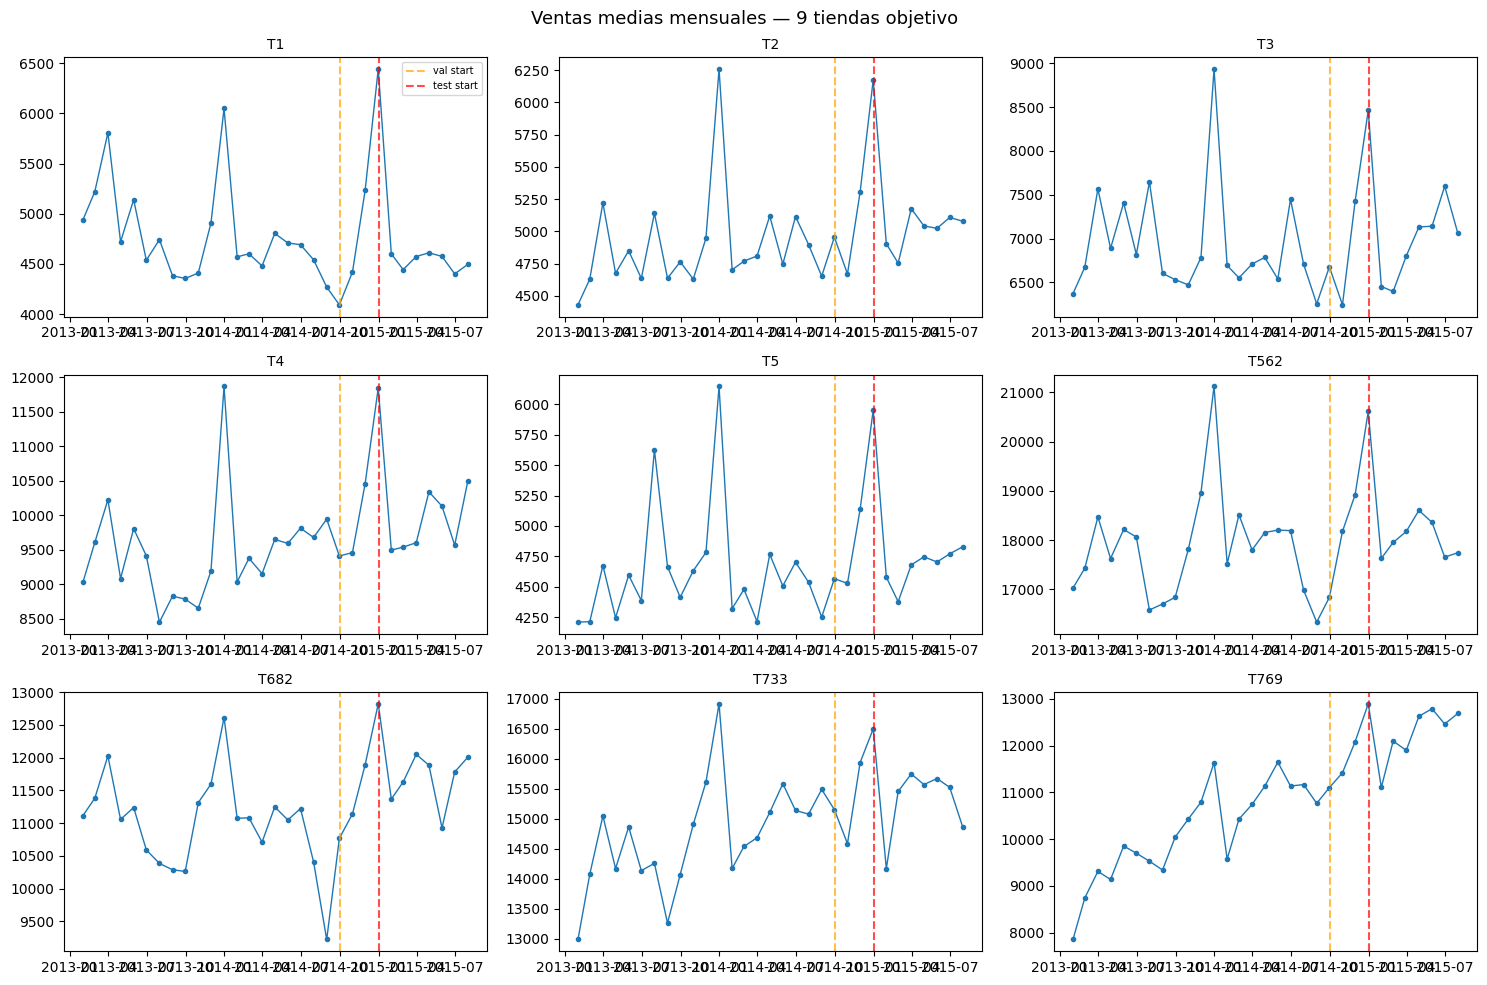

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, sid in enumerate(ev.TARGET_STORES):
    ax = axes[i]
    g = df[df["Store"] == sid].groupby(pd.Grouper(key="Date", freq="ME"))["Sales"].mean()
    ax.plot(g.index, g.values, marker="o", ms=3, linewidth=1)
    ax.axvline(pd.Timestamp("2014-10-01"), color="orange", linestyle="--", alpha=0.7, label="val start")
    ax.axvline(pd.Timestamp("2015-01-01"), color="red",    linestyle="--", alpha=0.7, label="test start")
    ax.set_title(f"T{sid}", fontsize=10)
    ax.set_xlabel("")
    if i == 0: ax.legend(fontsize=7)
plt.suptitle("Ventas medias mensuales — 9 tiendas objetivo", fontsize=13)
plt.tight_layout()
plt.show()

### Apendice B — Arquitectura del modelo (model.summary)

In [6]:
import os, sys
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path: sys.path.insert(0, PROJECT_ROOT)
import src.preprocessing as prep
import src.preprocessing_dani as dani

# Numero de tiendas y SEQ_LEN fijos
N_STORES, SEQ_LEN = 1115, 30

# -- Variante base (Baseline / E1 / E2 / E3) --
m_base = keras.models.model_from_json("""{}""") if False else None  # dummy

def _build(n_seq, n_num, seq_len=SEQ_LEN, drop=0.2, rnn='lstm', lstm2=None):
    n_cat = len(prep.STATIC_CAT_COLS)
    inp_seq    = keras.Input((seq_len, n_seq),       name='seq')
    inp_static = keras.Input((n_cat + n_num,),       name='static')
    inp_dow    = keras.Input((1,), dtype='int32',    name='dow')
    inp_month  = keras.Input((1,), dtype='int32',    name='month')
    if rnn == 'gru':
        x = L.GRU(64, name='gru')(inp_seq)
    elif rnn == 'gru_stacked':
        x = L.GRU(64, return_sequences=True, name='gru1')(inp_seq)
        x = L.Dropout(drop)(x)
        x = L.GRU(lstm2 or 32, name='gru2')(x)
    elif lstm2:
        x = L.LSTM(64, return_sequences=True, name='lstm1')(inp_seq)
        x = L.Dropout(drop)(x)
        x = L.LSTM(lstm2, name='lstm2')(x)
    else:
        x = L.LSTM(64, name='lstm')(inp_seq)
    x = L.Dropout(drop)(x)
    x = L.Dense(64, activation='relu')(x)
    cat_specs = [(0,N_STORES,16,'emb_Store'),(1,4,2,'emb_StoreType'),
                 (2,3,2,'emb_Assortment'),(3,4,2,'emb_PromoInterval')]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs]
    s = L.Concatenate()(emb_outs + [
        L.Flatten()(L.Embedding(7,  4, name='emb_dow')(inp_dow)),
        L.Flatten()(L.Embedding(12, 4, name='emb_month')(inp_month)),
        L.Lambda(lambda t: t[:, n_cat:])(inp_static),
    ])
    s = L.Dense(64, activation='relu')(s)
    s = L.Dropout(drop)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(128, activation='relu')(merged)
    merged = L.Dropout(drop)(merged)
    out = L.Dense(1, activation='linear', name='output')(merged)
    return keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)

configs = [
    ('Baseline/E1/E2/E3  — LSTM(64), 11 seq, 4 num',        11, 4, 'lstm', None, 0.2),
    ('E4/E8 base         — LSTM(64), 14 seq (lags), 4 num',  14, 4, 'lstm', None, 0.2),
    ('E5                 — LSTM(64), 15 seq (lags+slope)',    15, 4, 'lstm', None, 0.2),
    ('E6                 — LSTM(64), SEQ_LEN=60, 14 seq',    14, 4, 'lstm', None, 0.2),
    ('E7                 — LSTM(64), 13 seq, 5 num (dss)',    13, 5, 'lstm', None, 0.2),
    ('E8 dropout=0.35    — LSTM(64), 14 seq, drop=0.35',     14, 4, 'lstm', None, 0.35),
    ('E9                 — GRU(64),  14 seq, 4 num',         14, 4, 'gru',  None, 0.2),
    ('E10                — LSTM(64)+LSTM(32), 14 seq',       14, 4, 'lstm', 32,   0.2),
    ('E11                — LSTM(64), 14 seq, Huber loss',    14, 4, 'lstm', None, 0.2),
    # Tanda 4
    ('E12                — LSTM(64), 13 seq, 5 num, Huber', 13, 5, 'lstm', None, 0.2),
    ('E13                — LSTM(64), 14 seq (+promo2), 5 num', 14, 5, 'lstm', None, 0.2),
    ('E14                — LSTM(64), 13 seq, Huber, 10 ep',   13, 5, 'lstm', None, 0.2),
    ('E15                — LSTM(64), 14 seq (+promo2), Huber', 14, 5, 'lstm', None, 0.2),
    ('E16                — LSTM(64), 13 seq, Huber(d=1.5)',   13, 5, 'lstm', None, 0.2),
    # Tanda 5
    ('E17                — LSTM(64), 13 seq, Huber(d=1.0) — igual E12',  13, 5, 'lstm', None, 0.2),
    ('E18                — LSTM(64), 13 seq, Huber(d=1.5) — igual E16',  13, 5, 'lstm', None, 0.2),
    ('E19                — LSTM(64), 15 seq (+lag_3,+roll_7), 5 num',    15, 5, 'lstm', None, 0.2),
    ('E20                — LSTM(64), 13 seq, 6 num (+week_of_year)',      13, 6, 'lstm', None, 0.2),
    ('E21                — LSTM(64), 13 seq, Huber(d=1.0) — seed=42',    13, 5, 'lstm', None, 0.2),
    # Tanda 6
    ('E22/E23            — LSTM(64), 13 seq, 5 num, Huber — T769/T733 ponderadas',  13, 5, 'lstm', None, 0.2),
    ('E24                — GRU(64),  13 seq, 5 num, Huber — 20ep',                  13, 5, 'gru',  None, 0.2),
    ('E25                — LSTM(64), SEQ_LEN=60, 13 seq, 5 num, Huber',             13, 5, 'lstm', None, 0.2),
    # Tanda 7
    ('E26                — GRU(64→32), 13 seq, 5 num, Huber — 20ep',               13, 5, 'gru_stacked', 32, 0.2),
    ('E27                — LSTM(64), 13 seq, 5 num, Huber — 1115 tiendas (igual E17)', 13, 5, 'lstm', None, 0.2),
]

for label, n_seq, n_num, rnn, lstm2, drop in configs:
    seq_len = 60 if 'SEQ_LEN=60' in label else SEQ_LEN
    m = _build(n_seq, n_num, seq_len=seq_len, drop=drop, rnn=rnn, lstm2=lstm2)
    m.compile('adam', 'mse')
    print(f'\n{'='*65}')
    print(f'  {label}')
    print(f'{'='*65}')
    print(f'  Total params: {m.count_params():,}')
    del m


# ─── Tanda 8 — Modelos per-store (E28-E36, sin embedding de Store, ~22k params) ───
def _build_ps(n_seq=13, n_static_num=5, seq_len=SEQ_LEN,
              drop=0.2, dense_branch=32, merge_units=64):
    """Replica build_model_ps: sin Store embedding, rama estatica mas pequena."""
    inp_seq    = keras.Input((seq_len, n_seq), name='seq')
    inp_static = keras.Input((3 + n_static_num,), name='static')  # 3 cat + 5 num = 8
    inp_dow    = keras.Input((1,), dtype='int32', name='dow')
    inp_month  = keras.Input((1,), dtype='int32', name='month')
    x = L.LSTM(64, name='lstm')(inp_seq)
    x = L.Dropout(drop)(x)
    x = L.Dense(64, activation='relu')(x)
    # 3 embeddings sin Store: StoreType(4→2), Assortment(3→2), PromoInterval(4→2)
    cat_specs_ps = [(0,4,2,'emb_StoreType'),(1,3,2,'emb_Assortment'),(2,4,2,'emb_PromoInterval')]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs_ps]
    s = L.Concatenate()(emb_outs + [
        L.Flatten()(L.Embedding(7,  4, name='emb_dow')(inp_dow)),
        L.Flatten()(L.Embedding(12, 4, name='emb_month')(inp_month)),
        L.Lambda(lambda t: t[:, 3:])(inp_static),
    ])
    s = L.Dense(dense_branch, activation='relu')(s)
    s = L.Dropout(drop)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation='relu')(merged)
    merged = L.Dropout(drop)(merged)
    out = L.Dense(1, activation='linear', name='output')(merged)
    return keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)

print('\n' + '='*65)
print('  Tanda 8 — Modelo per-store (E28-E36, un modelo por tienda)')
print('='*65)
m_ps = _build_ps()
m_ps.compile('adam', 'mse')
print(f'  Total params: {m_ps.count_params():,}')
print(f'  (Shared model E17: ~60k params | Per-store E28-E36: ~22k params)')
del m_ps

print('' + '='*65)
print('  Tanda 9 - Vecindario (KNN) y correlacion inter-tienda (E37-E41)')
print('='*65)
print('  E37/E39: misma arquitectura per-store (_build_ps, sin Store emb).')
print('           E37 con 13 seq features; E39 con 15 (+peer_mean, +peer_roll7).')
print('  E38: arquitectura E17 (build_model_v2, Store emb) + 2 features peer (15 seq).')
print('  E40: arquitectura E17 + dss_norm^2 como 6a feature estatica.')
print('  E41: arquitectura E17 + roll_bias como 14a feature secuencial.')
m_v2 = build_model_v2(n_stores=df['Store'].nunique(), seq_len=SEQ_LEN,
                      n_seq_features=15, n_static_num_features=5)
print(f'  E38 (15 seq, Store emb) total params: {m_v2.count_params():,}')
del m_v2



  Baseline/E1/E2/E3  — LSTM(64), 11 seq, 4 num
  Total params: 60,435

  E4/E8 base         — LSTM(64), 14 seq (lags), 4 num
  Total params: 61,203

  E5                 — LSTM(64), 15 seq (lags+slope)
  Total params: 61,459

  E6                 — LSTM(64), SEQ_LEN=60, 14 seq
  Total params: 61,203

  E7                 — LSTM(64), 13 seq, 5 num (dss)
  Total params: 61,011

  E8 dropout=0.35    — LSTM(64), 14 seq, drop=0.35
  Total params: 61,203

  E9                 — GRU(64),  14 seq, 4 num
  Total params: 56,339

  E10                — LSTM(64)+LSTM(32), 14 seq
  Total params: 71,571

  E11                — LSTM(64), 14 seq, Huber loss
  Total params: 61,203

  E12                — LSTM(64), 13 seq, 5 num, Huber
  Total params: 61,011

  E13                — LSTM(64), 14 seq (+promo2), 5 num
  Total params: 61,267

  E14                — LSTM(64), 13 seq, Huber, 10 ep
  Total params: 61,011

  E15                — LSTM(64), 14 seq (+promo2), Huber
  Total params: 61,267

  E16  

### Apendice C — Curvas de entrenamiento (todos los modelos)

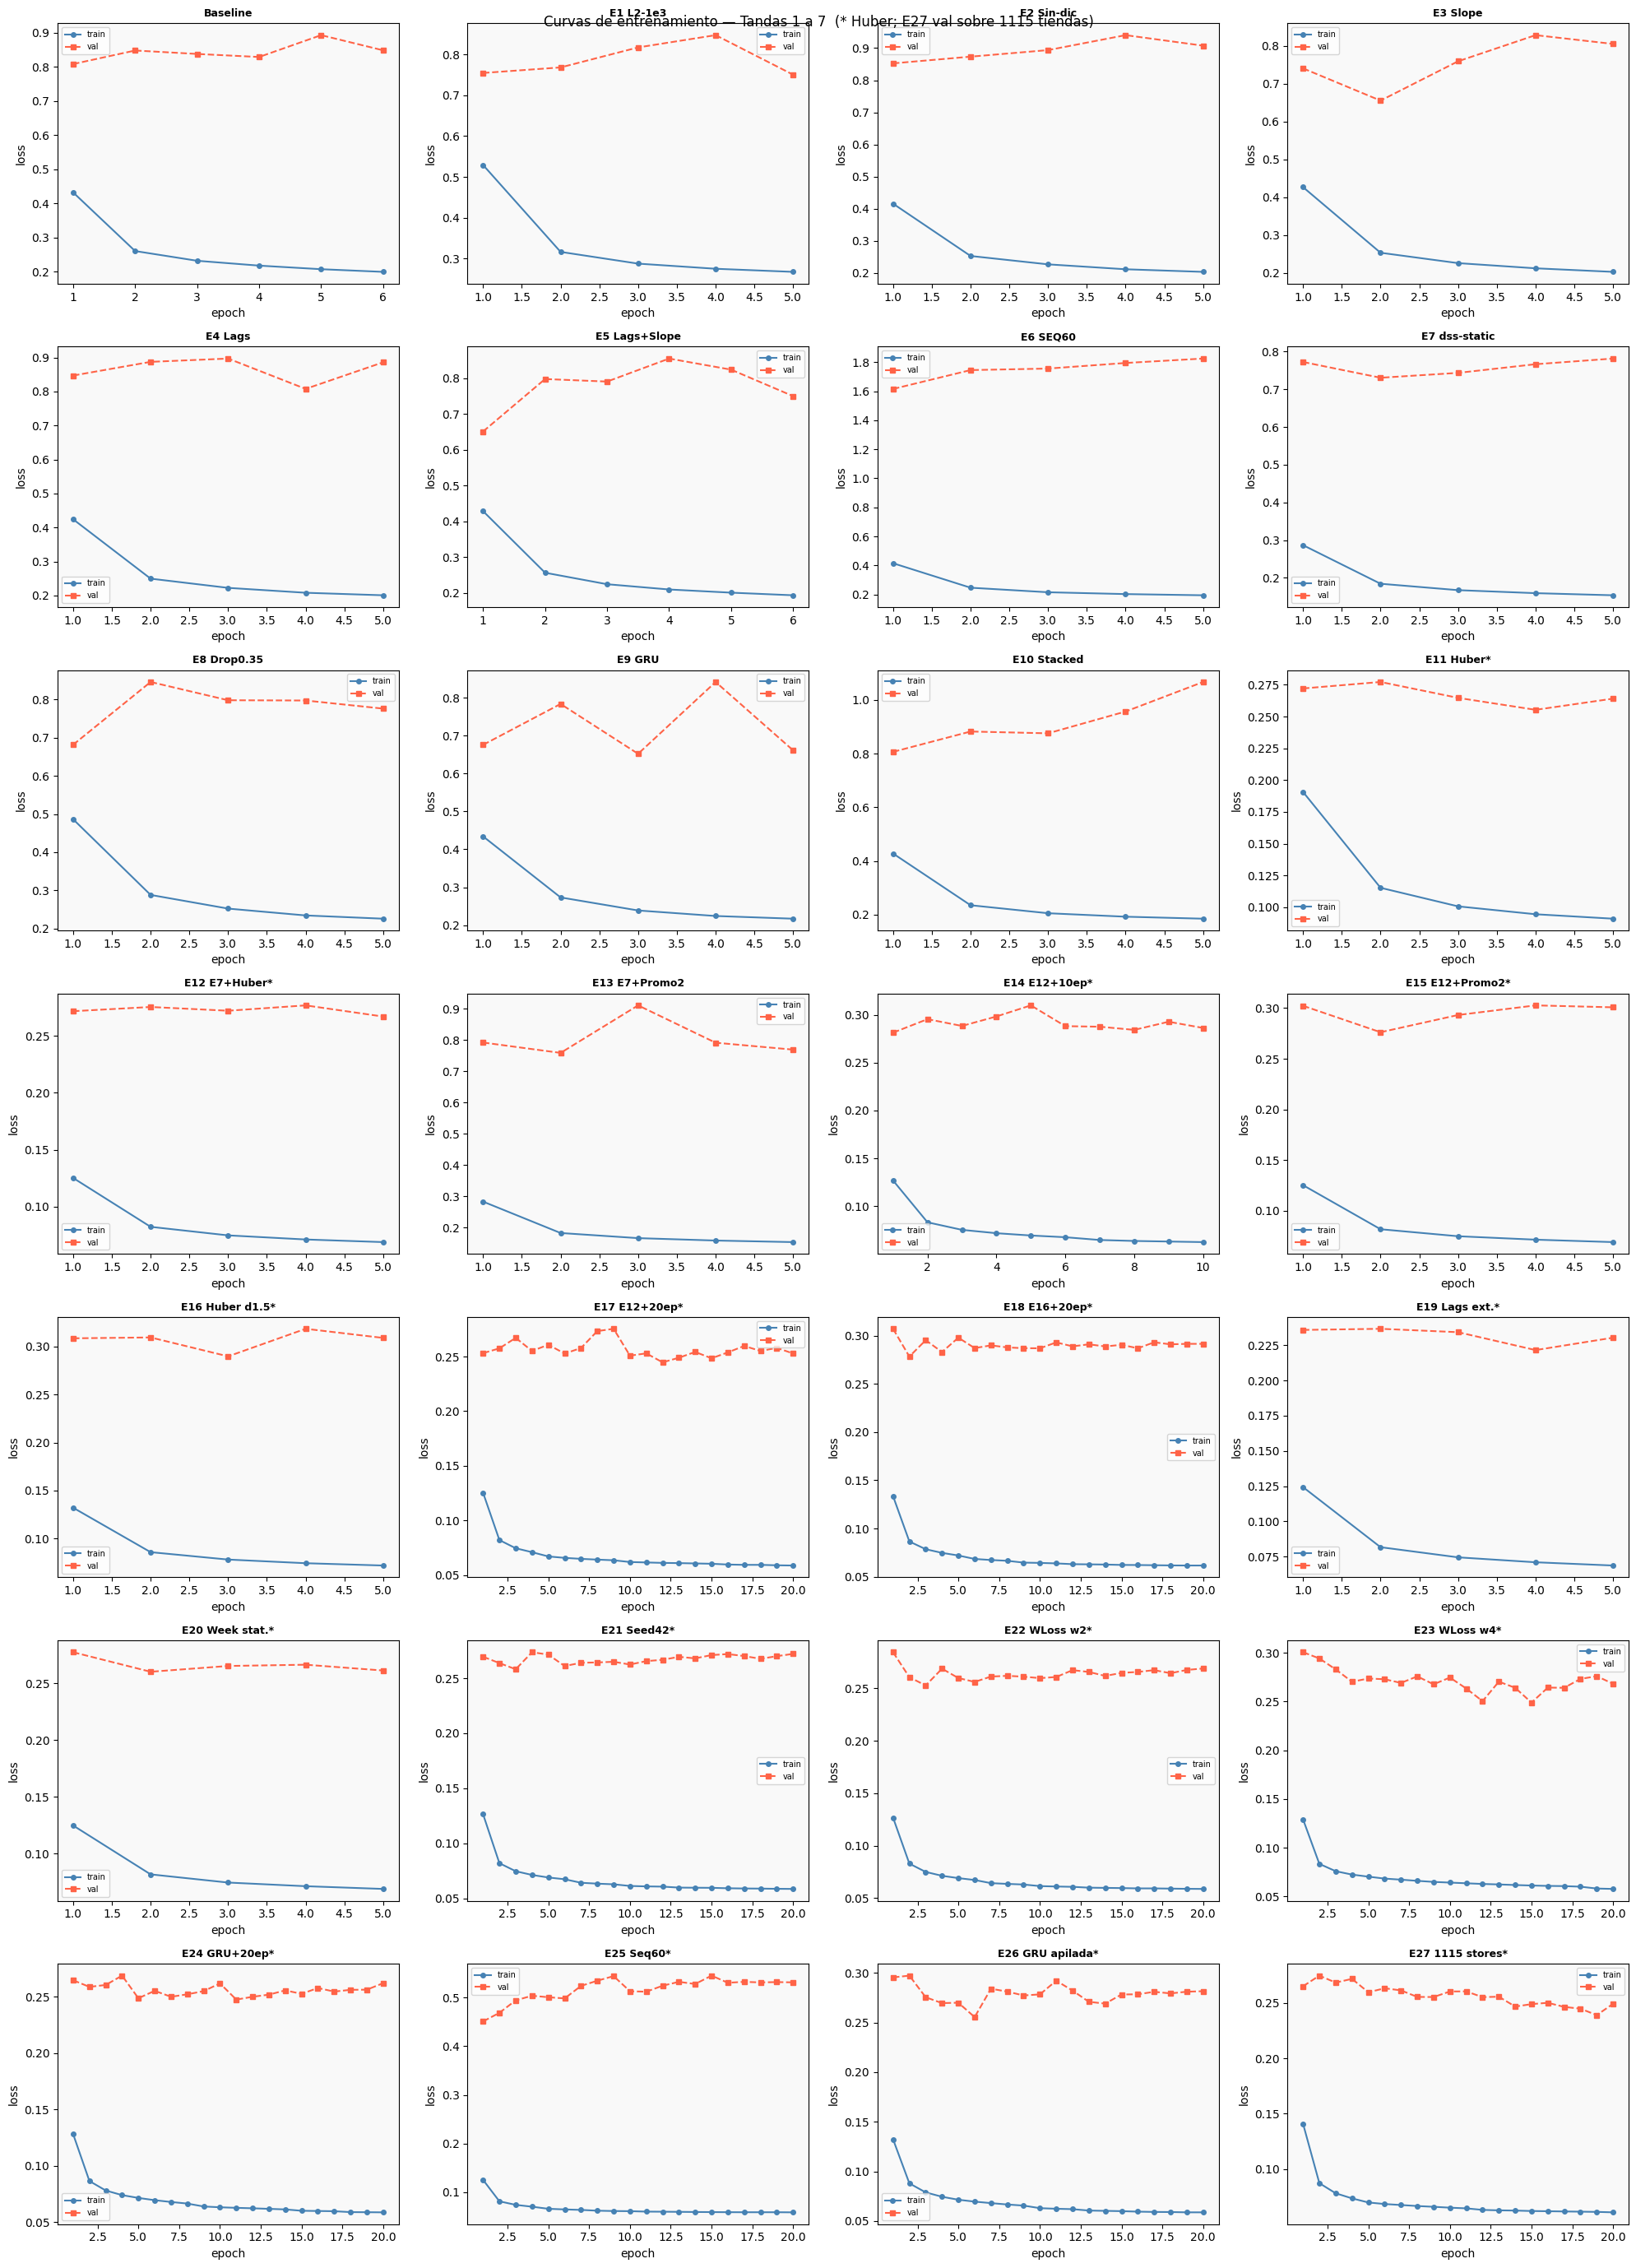

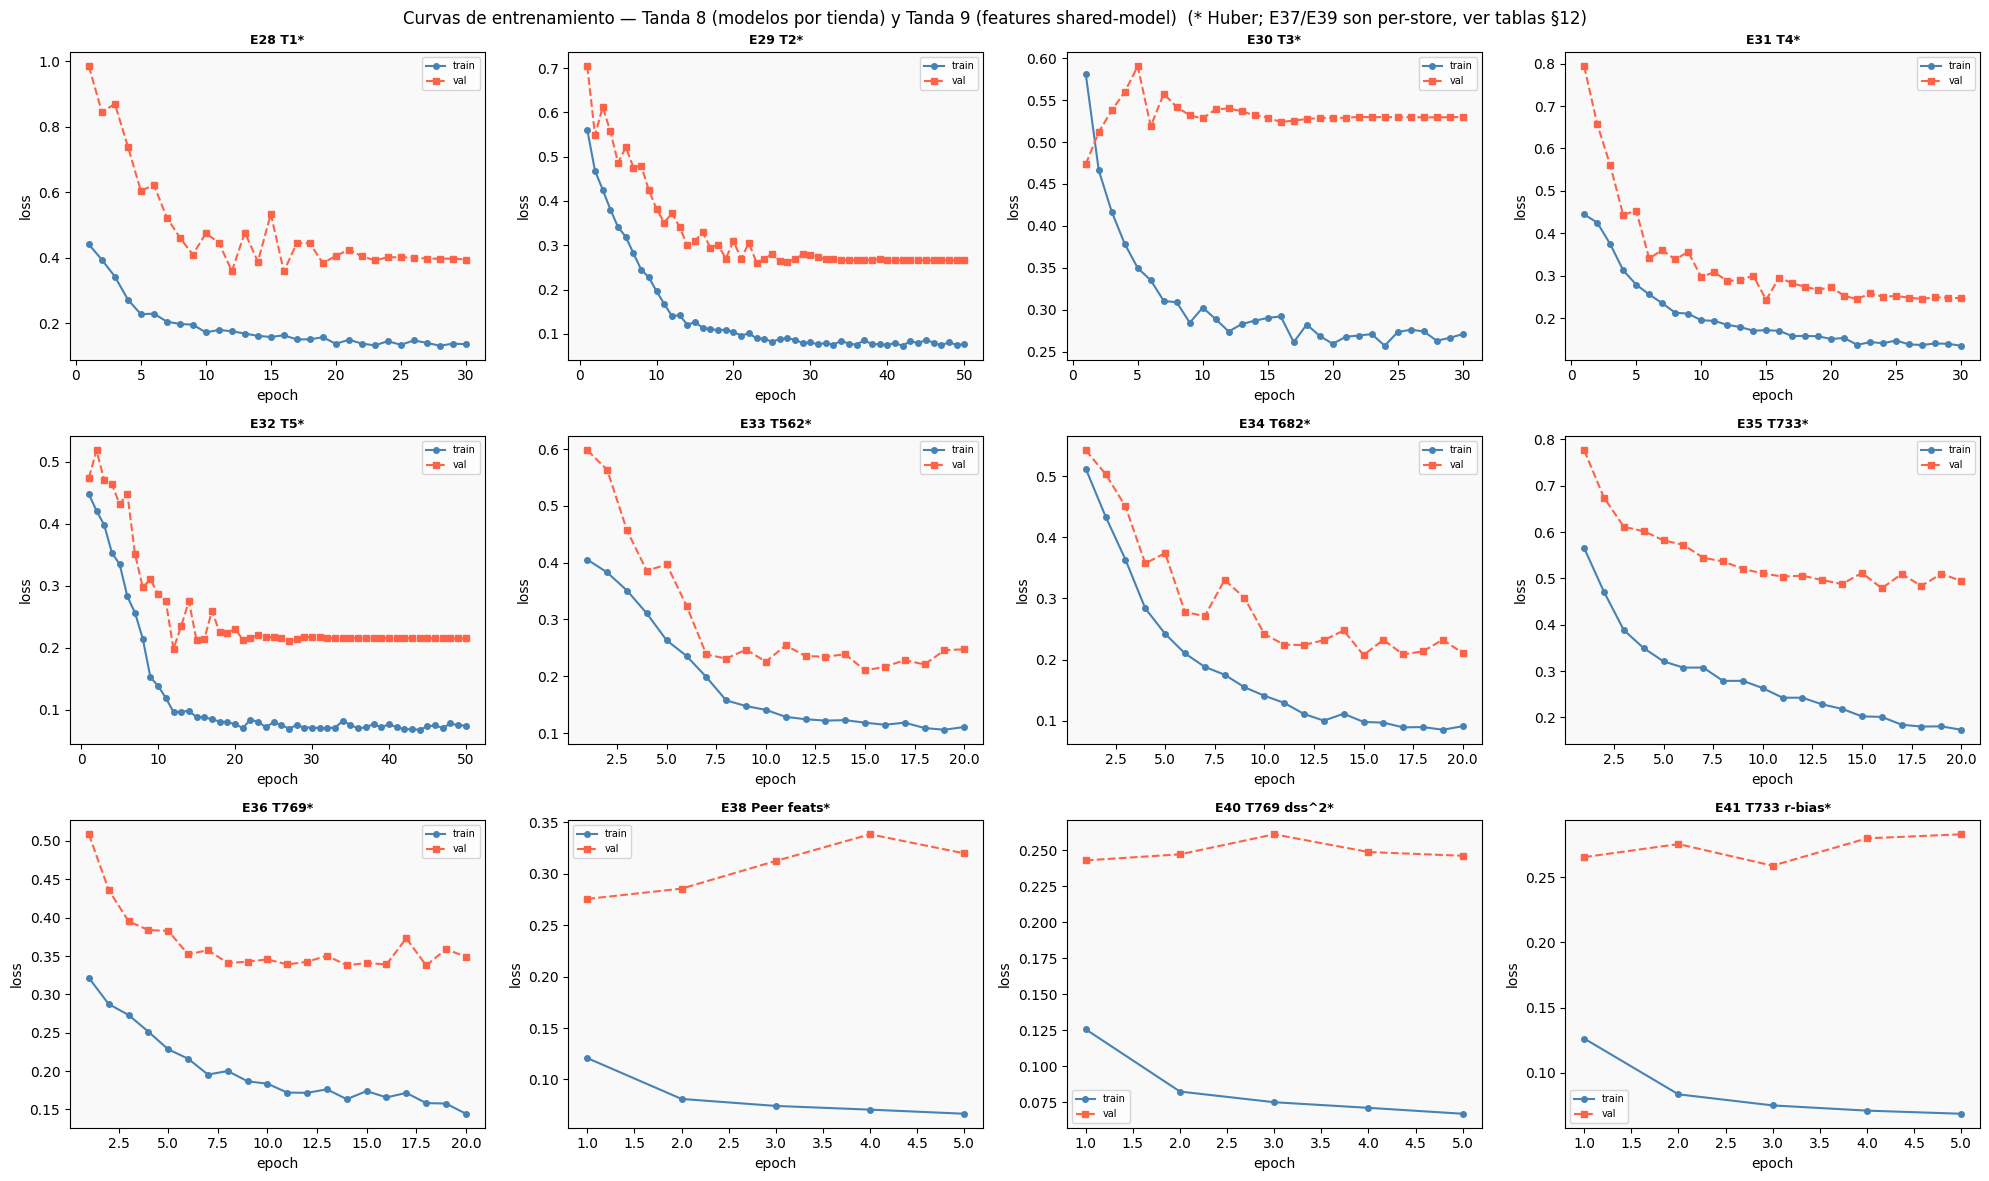

In [7]:
# Curvas de entrenamiento — valores extraidos de los outputs del notebook.
# Celda autocontenida: no depende de variables de sesion.
import matplotlib.pyplot as plt

T1 = {  # Tanda 1 + baseline
    'Baseline': {'loss':[0.4323,0.2604,0.2319,0.2177,0.2072,0.1994],
                 'val': [0.8083,0.8480,0.8379,0.8290,0.8930,0.8485]},
    'E1 L2-1e3':{'loss':[0.5292,0.3160,0.2872,0.2746,0.2670],
                 'val': [0.7550,0.7686,0.8177,0.8478,0.7507]},
    'E2 Sin-dic':{'loss':[0.4155,0.2526,0.2265,0.2112,0.2031],
                  'val': [0.8525,0.8734,0.8938,0.9404,0.9076]},
    'E3 Slope': {'loss':[0.4268,0.2533,0.2259,0.2122,0.2028],
                 'val': [0.7407,0.6555,0.7594,0.8285,0.8053]},
    'E4 Lags':  {'loss':[0.4243,0.2496,0.2225,0.2081,0.2007],
                 'val': [0.8469,0.8872,0.8969,0.8077,0.8859]},
}
T2 = {  # Tanda 2
    'E5 Lags+Slope':{'loss':[0.4290,0.2569,0.2248,0.2101,0.2012,0.1939],
                     'val': [0.6516,0.7982,0.7911,0.8554,0.8244,0.7504]},
    'E6 SEQ60':     {'loss':[0.4156,0.2471,0.2158,0.2032,0.1950],
                     'val': [1.6154,1.7453,1.7558,1.7943,1.8247]},
}
T3 = {  # Tanda 3
    'E7 dss-static':{'loss':[0.2865,0.1841,0.1671,0.1591,0.1535],
                     'val': [0.7725,0.7307,0.7436,0.7666,0.7816]},
    'E8 Drop0.35':  {'loss':[0.4864,0.2883,0.2525,0.2346,0.2261],
                     'val': [0.6812,0.8455,0.7977,0.7970,0.7758]},
    'E9 GRU':       {'loss':[0.4341,0.2731,0.2387,0.2241,0.2170],
                     'val': [0.6756,0.7835,0.6520,0.8415,0.6611]},
    'E10 Stacked':  {'loss':[0.4281,0.2355,0.2057,0.1928,0.1854],
                     'val': [0.8066,0.8824,0.8757,0.9569,1.0669]},
    'E11 Huber*':   {'loss':[0.1907,0.1153,0.1007,0.0945,0.0910],
                     'val': [0.2721,0.2772,0.2647,0.2553,0.2641]},
}

T4 = {  # Tanda 4
    'E12 E7+Huber*': {'loss': [0.1253, 0.0824, 0.0749, 0.0713, 0.0690],
                      'val':  [0.2716, 0.2753, 0.2720, 0.2767, 0.2669]},
    'E13 E7+Promo2': {'loss': [0.2831, 0.1826, 0.1662, 0.1585, 0.1535],  # re-ejecucion
                      'val':  [0.7923, 0.7591, 0.9112, 0.7917, 0.7696]},
    'E14 E12+10ep*': {'loss': [0.1269,0.0832,0.0753,0.0718,0.0694,0.0676,0.0647,0.0637,0.0631,0.0625],
                      'val':  [0.2814,0.2955,0.2884,0.2983,0.3099,0.2882,0.2876,0.2843,0.2928,0.2863]},
    'E15 E12+Promo2*':{'loss': [0.1252, 0.0817, 0.0748, 0.0714, 0.0690],
                       'val':  [0.3023, 0.2762, 0.2932, 0.3027, 0.3008]},
    'E16 Huber d1.5*':{'loss': [0.1322, 0.0859, 0.0782, 0.0744, 0.0720],
                       'val':  [0.3086, 0.3095, 0.2898, 0.3185, 0.3090]},
}

T5 = {  # Tanda 5 — resultados Tanda 5
    'E17 E12+20ep*': {'loss': [0.1253,0.0820,0.0745,0.0709,0.0670,0.0657,0.0648,0.0641,0.0635,0.0619,0.0615,0.0611,0.0609,0.0606,0.0603,0.0596,0.0593,0.0593,0.0589,0.0587],
                      'val':  [0.2531,0.2575,0.2671,0.2551,0.2608,0.2527,0.2578,0.2733,0.2754,0.2508,0.2529,0.2447,0.2489,0.2542,0.2484,0.2538,0.2597,0.2551,0.2579,0.2528]},
    'E18 E16+20ep*': {'loss': [0.1335,0.0865,0.0785,0.0747,0.0720,0.0684,0.0673,0.0665,0.0646,0.0643,0.0638,0.0630,0.0628,0.0626,0.0622,0.0621,0.0619,0.0617,0.0616,0.0616],
                      'val':  [0.3070,0.2782,0.2952,0.2829,0.2978,0.2870,0.2898,0.2877,0.2869,0.2868,0.2929,0.2888,0.2909,0.2887,0.2904,0.2868,0.2930,0.2909,0.2914,0.2914]},
    'E19 Lags ext.*': {'loss': [0.1243,0.0817,0.0745,0.0710,0.0687],
                       'val':  [0.2358,0.2366,0.2342,0.2215,0.2303]},
    'E20 Week stat.*':{'loss': [0.1248,0.0818,0.0746,0.0714,0.0690],
                       'val':  [0.2772,0.2600,0.2651,0.2662,0.2611]},
    'E21 Seed42*':    {'loss': [0.1264,0.0819,0.0746,0.0712,0.0689,0.0673,0.0641,0.0633,0.0627,0.0612,0.0608,0.0606,0.0597,0.0596,0.0595,0.0591,0.0589,0.0588,0.0586,0.0585],
                      'val':  [0.2696,0.2638,0.2582,0.2737,0.2715,0.2611,0.2641,0.2644,0.2650,0.2625,0.2656,0.2668,0.2695,0.2681,0.2711,0.2720,0.2702,0.2677,0.2701,0.2722]},
}

T6 = {  # Tanda 6
    'E22 WLoss w2*': {
        'loss': [0.1267,0.0829,0.0750,0.0713,0.0691,0.0673,0.0643,0.0636,0.0630,0.0615,0.0611,0.0608,0.0600,0.0598,0.0596,0.0593,0.0593,0.0591,0.0589,0.0588],
        'val':  [0.2843,0.2605,0.2526,0.2686,0.2597,0.2560,0.2611,0.2618,0.2610,0.2596,0.2607,0.2672,0.2655,0.2617,0.2646,0.2655,0.2672,0.2643,0.2674,0.2688]},
    'E23 WLoss w4*': {
        'loss': [0.1291,0.0834,0.0759,0.0724,0.0703,0.0683,0.0672,0.0660,0.0649,0.0642,0.0635,0.0628,0.0623,0.0617,0.0612,0.0608,0.0606,0.0600,0.0581,0.0577],
        'val':  [0.3005,0.2941,0.2829,0.2702,0.2735,0.2728,0.2690,0.2757,0.2676,0.2745,0.2633,0.2503,0.2703,0.2640,0.2488,0.2642,0.2640,0.2731,0.2759,0.2681]},
    'E24 GRU+20ep*': {
        'loss': [0.1282,0.0864,0.0780,0.0739,0.0714,0.0694,0.0678,0.0664,0.0638,0.0631,0.0626,0.0622,0.0617,0.0612,0.0600,0.0598,0.0596,0.0588,0.0587,0.0586],
        'val':  [0.2648,0.2589,0.2606,0.2689,0.2488,0.2554,0.2501,0.2523,0.2551,0.2620,0.2476,0.2501,0.2520,0.2558,0.2527,0.2579,0.2547,0.2563,0.2564,0.2622]},
    'E25 Seq60*':    {
        'loss': [0.1249,0.0808,0.0735,0.0697,0.0654,0.0641,0.0631,0.0615,0.0608,0.0605,0.0596,0.0594,0.0591,0.0588,0.0586,0.0584,0.0583,0.0583,0.0583,0.0581],
        'val':  [0.4512,0.4689,0.4946,0.5041,0.5010,0.4986,0.5243,0.5350,0.5445,0.5133,0.5124,0.5247,0.5327,0.5282,0.5455,0.5308,0.5327,0.5315,0.5322,0.5316]},
}

all_h = {**T1, **T2, **T3}
T5_active = {k:v for k,v in T5.items() if not k.startswith('#')}
T7 = {  # Tanda 7
    'E26 GRU apilada*': {
        'loss': [0.1323,0.0879,0.0788,0.0744,0.0714,0.0695,0.0680,0.0666,0.0655,0.0629,0.0623,0.0619,0.0605,0.0602,0.0599,0.0594,0.0591,0.0590,0.0587,0.0587],
        'val':  [0.2954,0.2972,0.2754,0.2695,0.2699,0.2554,0.2840,0.2811,0.2772,0.2783,0.2921,0.2821,0.2708,0.2690,0.2782,0.2784,0.2809,0.2793,0.2810,0.2815]},
    'E27 1115 stores*': {  # val sobre 1115 tiendas — no comparable con E17
        'loss': [0.1410,0.0874,0.0783,0.0737,0.0700,0.0686,0.0677,0.0668,0.0661,0.0653,0.0647,0.0633,0.0629,0.0627,0.0623,0.0621,0.0619,0.0617,0.0615,0.0611],
        'val':  [0.2649,0.2745,0.2682,0.2716,0.2595,0.2631,0.2612,0.2553,0.2552,0.2602,0.2603,0.2551,0.2555,0.2466,0.2488,0.2500,0.2463,0.2447,0.2389,0.2491]},
}
T6_active = {k:v for k,v in T6.items() if not k.startswith('#')}
T7_active = {k:v for k,v in T7.items() if not k.startswith('#')}
ncols = 4
n_plots = len(T1) + len(T2) + len(T3) + len(T4) + len(T5_active) + len(T6_active) + len(T7_active)
nrows = (n_plots + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()
colors = {'Tanda 1':'tab:blue','Tanda 2':'tab:orange','Tanda 3':'tab:green','Tanda 4':'tab:purple'}
groups = (
    [('Tanda 1', T1), ('Tanda 2', T2), ('Tanda 3', T3), ('Tanda 4', T4)]
    + ([('Tanda 5', T5_active)] if T5_active else [])
    + ([('Tanda 6', T6_active)] if T6_active else [])
    + ([('Tanda 7', T7_active)] if T7_active else [])
)


i = 0
for tanda_name, group in groups:
    for name, h in group.items():
        ax = axes[i]
        eps = range(1, len(h['loss'])+1)
        ax.plot(eps, h['loss'], 'o-', label='train', ms=4, color='steelblue')
        ax.plot(eps, h['val'],  's--',label='val',   ms=4, color='tomato')
        ax.set_title(f'{name}', fontsize=9, fontweight='bold')
        ax.set_facecolor('#f9f9f9')
        ax.legend(fontsize=7)
        ax.set_xlabel('epoch'); ax.set_ylabel('loss')
        i += 1

for j in range(i, len(axes)): axes[j].set_visible(False)
plt.suptitle('Curvas de entrenamiento — Tandas 1 a 7  (* Huber; E27 val sobre 1115 tiendas)', fontsize=12)
plt.tight_layout()
plt.show()
T8 = {  # Tanda 8 — Modelos por tienda (Fase 1) — val_loss Huber(d=1.0)
    'E28 T1*':   {'loss':[0.4400,0.3934,0.3419,0.2718,0.2268,0.2287,0.2042,0.1971,0.1950,0.1712,
                          0.1789,0.1747,0.1678,0.1606,0.1574,0.1625,0.1497,0.1502,0.1565,0.1364,
                          0.1489,0.1371,0.1315,0.1446,0.1333,0.1467,0.1393,0.1305,0.1369,0.1353],
                  'val': [0.9844,0.8446,0.8695,0.7393,0.6040,0.6214,0.5222,0.4607,0.4089,0.4742,
                          0.4454,0.3585,0.4764,0.3877,0.5328,0.3576,0.4444,0.4436,0.3828,0.4051,
                          0.4241,0.4040,0.3914,0.4009,0.4009,0.3999,0.3970,0.3965,0.3970,0.3938]},
    'E29 T2*':   {'loss':[0.5603,0.4680,0.4256,0.3807,0.3408,0.3190,0.2817,0.2451,0.2274,0.1961,
                          0.1675,0.1403,0.1419,0.1206,0.1265,0.1133,0.1112,0.1078,0.1096,0.1041,
                          0.0961,0.1011,0.0899,0.0890,0.0821,0.0881,0.0897,0.0872,0.0785,0.0809,
                          0.0760,0.0797,0.0752,0.0848,0.0774,0.0758,0.0854,0.0767,0.0767,0.0753,
                          0.0789,0.0731,0.0840,0.0787,0.0864,0.0801,0.0742,0.0809,0.0750,0.0761],
                  'val': [0.7040,0.5487,0.6120,0.5570,0.4860,0.5216,0.4754,0.4794,0.4245,0.3816,
                          0.3512,0.3727,0.3408,0.2999,0.3105,0.3290,0.2944,0.3007,0.2699,0.3090,
                          0.2698,0.3050,0.2608,0.2683,0.2803,0.2647,0.2628,0.2682,0.2795,0.2770,
                          0.2727,0.2684,0.2684,0.2670,0.2663,0.2666,0.2657,0.2675,0.2682,0.2664,
                          0.2665,0.2665,0.2667,0.2663,0.2661,0.2661,0.2662,0.2661,0.2660,0.2660]},
    'E30 T3*':   {'loss':[0.5814,0.4664,0.4168,0.3785,0.3496,0.3351,0.3104,0.3088,0.2844,0.3025,
                          0.2886,0.2739,0.2828,0.2868,0.2901,0.2919,0.2612,0.2822,0.2686,0.2592,
                          0.2676,0.2691,0.2708,0.2569,0.2733,0.2760,0.2741,0.2629,0.2663,0.2708],
                  'val': [0.4736,0.5120,0.5378,0.5600,0.5905,0.5189,0.5577,0.5418,0.5320,0.5282,
                          0.5392,0.5402,0.5369,0.5319,0.5293,0.5239,0.5257,0.5276,0.5288,0.5289,
                          0.5290,0.5301,0.5298,0.5299,0.5297,0.5297,0.5296,0.5296,0.5298,0.5300]},
    'E31 T4*':   {'loss':[0.4443,0.4252,0.3745,0.3126,0.2789,0.2556,0.2350,0.2126,0.2104,0.1948,
                          0.1934,0.1841,0.1788,0.1704,0.1712,0.1700,0.1575,0.1579,0.1570,0.1506,
                          0.1531,0.1368,0.1433,0.1407,0.1470,0.1378,0.1365,0.1401,0.1393,0.1347],
                  'val': [0.7936,0.6576,0.5607,0.4429,0.4536,0.3405,0.3603,0.3381,0.3559,0.2969,
                          0.3080,0.2877,0.2890,0.3002,0.2428,0.2956,0.2821,0.2736,0.2667,0.2732,
                          0.2523,0.2446,0.2583,0.2502,0.2522,0.2480,0.2450,0.2492,0.2477,0.2469]},
    'E32 T5*':   {'loss':[0.4479,0.4208,0.3978,0.3527,0.3347,0.2828,0.2560,0.2147,0.1522,0.1381,
                          0.1189,0.0961,0.0966,0.0977,0.0878,0.0877,0.0843,0.0807,0.0795,0.0766,
                          0.0701,0.0836,0.0802,0.0715,0.0794,0.0753,0.0693,0.0748,0.0710,0.0708,
                          0.0702,0.0701,0.0709,0.0815,0.0752,0.0697,0.0712,0.0766,0.0714,0.0761,
                          0.0717,0.0683,0.0683,0.0674,0.0729,0.0744,0.0703,0.0775,0.0746,0.0740],
                  'val': [0.4741,0.5186,0.4700,0.4635,0.4317,0.4486,0.3508,0.2976,0.3102,0.2860,
                          0.2749,0.1980,0.2350,0.2748,0.2118,0.2135,0.2596,0.2246,0.2240,0.2304,
                          0.2131,0.2154,0.2200,0.2173,0.2167,0.2150,0.2106,0.2138,0.2168,0.2175,
                          0.2165,0.2156,0.2155,0.2155,0.2158,0.2155,0.2156,0.2154,0.2154,0.2155,
                          0.2153,0.2152,0.2152,0.2151,0.2150,0.2149,0.2149,0.2149,0.2149,0.2149]},
    'E33 T562*': {'loss':[0.4054,0.3828,0.3510,0.3106,0.2633,0.2359,0.1986,0.1576,0.1476,0.1409,
                          0.1286,0.1244,0.1220,0.1228,0.1183,0.1147,0.1184,0.1089,0.1059,0.1108],
                  'val': [0.5978,0.5635,0.4567,0.3855,0.3971,0.3241,0.2385,0.2311,0.2469,0.2258,
                          0.2543,0.2357,0.2344,0.2388,0.2103,0.2168,0.2284,0.2208,0.2459,0.2475]},
    'E34 T682*': {'loss':[0.5121,0.4338,0.3635,0.2836,0.2421,0.2100,0.1880,0.1752,0.1547,0.1409,
                          0.1291,0.1110,0.1001,0.1114,0.0980,0.0968,0.0891,0.0896,0.0852,0.0910],
                  'val': [0.5421,0.5034,0.4504,0.3571,0.3740,0.2776,0.2710,0.3303,0.3008,0.2418,
                          0.2242,0.2238,0.2316,0.2475,0.2073,0.2322,0.2083,0.2135,0.2325,0.2104]},
    'E35 T733*': {'loss':[0.5652,0.4707,0.3882,0.3494,0.3208,0.3074,0.3075,0.2787,0.2789,0.2631,
                          0.2425,0.2424,0.2280,0.2184,0.2022,0.2010,0.1842,0.1802,0.1806,0.1733],
                  'val': [0.7763,0.6739,0.6111,0.6018,0.5820,0.5722,0.5445,0.5365,0.5205,0.5105,
                          0.5039,0.5058,0.4963,0.4877,0.5118,0.4786,0.5092,0.4837,0.5098,0.4946]},
    'E36 T769*': {'loss':[0.3214,0.2873,0.2731,0.2513,0.2283,0.2161,0.1954,0.2000,0.1866,0.1835,
                          0.1719,0.1716,0.1761,0.1633,0.1739,0.1656,0.1715,0.1582,0.1576,0.1443],
                  'val': [0.5087,0.4361,0.3953,0.3838,0.3828,0.3521,0.3576,0.3408,0.3426,0.3456,
                          0.3390,0.3425,0.3503,0.3379,0.3408,0.3390,0.3731,0.3377,0.3588,0.3491]},
}
# [*] val_loss Huber(d=1.0) por tienda individual — escalas diferentes entre si y vs tandas 1-7


T9 = {  # Tanda 9 — features shared-model (5 ep). E37/E39 son per-store (ver tablas §12)
    'E38 Peer feats*':  {'loss':[0.1208,0.0811,0.0743,0.0707,0.0667],
                         'val': [0.2755,0.2855,0.3124,0.3383,0.3198]},
    'E40 T769 dss^2*':  {'loss':[0.1257,0.0825,0.0751,0.0712,0.0671],
                         'val': [0.2430,0.2472,0.2611,0.2488,0.2462]},
    'E41 T733 r-bias*': {'loss':[0.1263,0.0835,0.0750,0.0710,0.0686],
                         'val': [0.2655,0.2755,0.2589,0.2799,0.2830]},
}

# Figura Tandas 8-9: modelos por tienda (Huber, escalas distintas) + features shared-model
groups89 = [('Tanda 8', T8), ('Tanda 9', T9)]
n89 = sum(len(g) for _, g in groups89)
nrows89 = (n89 + ncols - 1) // ncols
fig, axes = plt.subplots(nrows89, ncols, figsize=(20, 4 * nrows89))
axes = axes.flatten()
i = 0
for tanda_name, group in groups89:
    for name, h in group.items():
        ax = axes[i]
        eps = range(1, len(h['loss']) + 1)
        ax.plot(eps, h['loss'], 'o-', label='train', ms=4, color='steelblue')
        ax.plot(eps, h['val'],  's--', label='val',  ms=4, color='tomato')
        ax.set_title(f'{name}', fontsize=9, fontweight='bold')
        ax.set_facecolor('#f9f9f9')
        ax.legend(fontsize=7)
        ax.set_xlabel('epoch'); ax.set_ylabel('loss')
        i += 1
for j in range(i, len(axes)): axes[j].set_visible(False)
plt.suptitle('Curvas de entrenamiento — Tanda 8 (modelos por tienda) y Tanda 9 (features shared-model)  '
             '(* Huber; E37/E39 son per-store, ver tablas §12)', fontsize=12)
plt.tight_layout()
plt.show()


### Apendice D — PCA de embeddings de tienda

Pesos E17 (mejor modelo: E12+20ep+patience=3) cargados desde disco.


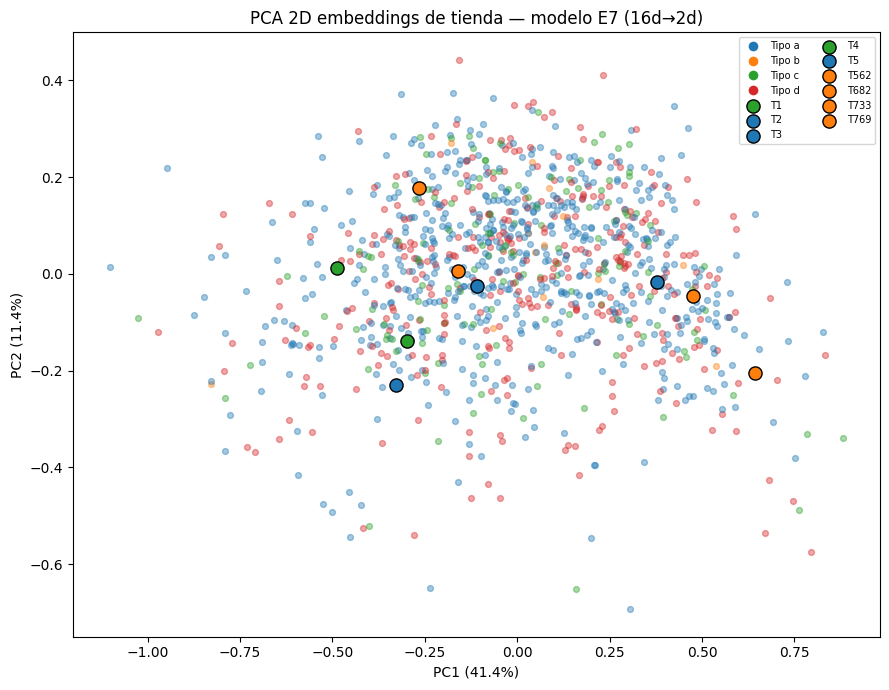

In [23]:
# Apendice D — PCA de embeddings de tienda (mejor modelo: E17 — E12+20ep+patience=3)
# Celda autocontenida: reconstruye arquitectura y carga pesos desde disco.
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from sklearn.decomposition import PCA

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path: sys.path.insert(0, PROJECT_ROOT)
import src.preprocessing as prep
import src.evaluate as ev

DATA_DIR    = os.path.join(PROJECT_ROOT, 'data')
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, 'outputs')
SEQ_LEN, N_STORES = 30, 1115

# Cargar store_types para colorear
_, store_raw = prep.load_raw_data(DATA_DIR)
store_types = store_raw.set_index('Store')['StoreType'].to_dict()

# Reconstruir arquitectura E17 (13 seq, 5 num — identica a E12) y cargar pesos
n_cat = len(prep.STATIC_CAT_COLS)
inp_seq    = keras.Input((SEQ_LEN, 13),      name='seq')
inp_static = keras.Input((n_cat + 5,),       name='static')
inp_dow    = keras.Input((1,), dtype='int32', name='dow')
inp_month  = keras.Input((1,), dtype='int32', name='month')
x = L.LSTM(64, name='lstm')(inp_seq)
x = L.Dropout(0.2)(x)
x = L.Dense(64, activation='relu')(x)
cat_specs = [(0,N_STORES,16,'emb_Store'),(1,4,2,'emb_StoreType'),
             (2,3,2,'emb_Assortment'),(3,4,2,'emb_PromoInterval')]
emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
            for i,v,d,nm in cat_specs]
s = L.Concatenate()(emb_outs + [
    L.Flatten()(L.Embedding(7,  4, name='emb_dow')(inp_dow)),
    L.Flatten()(L.Embedding(12, 4, name='emb_month')(inp_month)),
    L.Lambda(lambda t: t[:, n_cat:])(inp_static),
])
s = L.Dense(64, activation='relu')(s)
s = L.Dropout(0.2)(s)
merged = L.Concatenate()([x, s])
merged = L.Dense(128, activation='relu')(merged)
merged = L.Dropout(0.2)(merged)
out = L.Dense(1, activation='linear', name='output')(merged)
best_model = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
best_model.compile('adam', 'mse')
best_model.load_weights(os.path.join(OUTPUTS_DIR, 'exp17_e12_20ep.weights.h5'))
print('Pesos E17 (mejor modelo: E12+20ep+patience=3) cargados desde disco.')

# PCA 2D sobre embeddings de tienda
store_weights = best_model.get_layer('emb_Store').get_weights()[0]
coords = PCA(n_components=2).fit_transform(store_weights)
exp_var = PCA(n_components=2).fit(store_weights).explained_variance_ratio_

colors = {'a':'tab:blue','b':'tab:orange','c':'tab:green','d':'tab:red'}
plt.figure(figsize=(9, 7))
for sid in range(store_weights.shape[0]):
    st = store_types.get(sid + 1, 'a')
    plt.scatter(coords[sid, 0], coords[sid, 1], c=colors.get(st,'gray'), alpha=0.4, s=18)
for sid in ev.TARGET_STORES:
    idx = sid - 1
    st = store_types.get(sid, 'a')
    plt.scatter(coords[idx, 0], coords[idx, 1], c=colors.get(st,'gray'),
                edgecolors='black', s=90, zorder=5, label=f'T{sid}')
from matplotlib.lines import Line2D
legend_types = [Line2D([0],[0],marker='o',color='w',markerfacecolor=c,markersize=8,label=f'Tipo {k}')
                for k,c in colors.items()]
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=legend_types + handles, ncol=2, fontsize=7)
plt.title(f'PCA 2D embeddings de tienda — modelo E7 (16d→2d)')
plt.xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
plt.tight_layout()
plt.show()